# RBMD -- Health Insurance Churn (Multi-Attribute)

Adapted to your actual pipeline:
- Data: `Health_Insurance_final.pkl`, period-based split (train=2017, val=2018, test=2019)
- Preprocessing: `ColumnTransformer(StandardScaler + OneHotEncoder(drop='first'))` -- matches your GLM's own preprocessor
- Black-box f: your pretrained `glm.pkl` (a full sklearn Pipeline including its own preprocessor), loaded and used via `.predict_proba()`
- 3 bugs from the previous notebook are fixed: a print-statement typo, missing `y_true` argument in `disparate_mistreatment_general` calls (3 places), and a `KeyError` in the summary plot from a renamed dict key.

In [ ]:
!pip install scikit-learn==1.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 107.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


## 1. Imports

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.autograd import Variable

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score
)
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

## 2. Load data + define features/target

**Target confirmed:** `is_churn` and the mapped `lapse` are the same variable -- using `lapse` (mapped to binary: 1/3 -> 1, 2 -> 0) as `target` directly.

In [ ]:
data = pd.read_pickle('./sample_data/Health_Insurance_final.pkl')
data['lapse'] = data['lapse'].map({1: 1, 3: 1, 2: 0})

target = 'lapse'

x_cols = [
    # 기본
    'premium', 'seniority_policy', 'type_policy_dg', 'type_product', 'new_business',
    'log_cost_claims_year', 'distribution_channel',
    # 나이 관련
    'age',
    # 성별 관련
    'gender',
    # 지역 관련
    'IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T',
]
# 파생 변수
der_cols = [
    'missing_geo_cxt', 'high_loss', 'relative_poverty', 'kr_premium_shock',
    'kr_economic_stress', 'kr_early_laps', 'kr_medical_desert'
]
# 최종 피처
x_cols += der_cols

# 범주형 변수
cat_cols = ['type_policy_dg', 'type_product', 'new_business', 'distribution_channel', 'gender', 'C_C', 'kr_early_laps']
# 범주형 인코딩을 위해 데이터 타입 str로 변경
data[cat_cols] = data[cat_cols].astype(str)
# 수치형 변수
num_cols = [col for col in x_cols if col not in cat_cols]

print(f"기본 변수: {len(x_cols) - len(der_cols)}개 / 파생 변수: {len(der_cols)}개 / 총 {len(x_cols)}개")
print(f"범주형: {len(cat_cols)}개, 수치형: {len(num_cols)}개")

기본 변수: 15개 / 파생 변수: 7개 / 총 22개
범주형: 7개, 수치형: 15개


## 3. Period-based train/val/test split

Your setup splits by year, not randomly -- kept as-is (this matters for a churn model: random splitting would leak future information into training).

In [ ]:
# 데이터셋 분리 (총 데이터셋 3개년, 약 22만개)
train_df = data[data['period'] == 2017]
val_df   = data[data['period'] == 2018]
test_df  = data[data['period'] == 2019]

X_train0, y_train = train_df[x_cols], train_df[target].values
X_val0,   y_val   = val_df[x_cols],   val_df[target].values
X_test0,  y_test  = test_df[x_cols],  test_df[target].values

print("Train:", X_train0.shape, " Val:", X_val0.shape, " Test:", X_test0.shape)

Train: (77525, 22)  Val: (73474, 22)  Test: (75667, 22)


## 4. Preprocessing for RBMD's own r(X) network

RBMD's `r(X)` needs a numeric array as input, same as your GLM does. We fit a `StandardScaler + OneHotEncoder` `ColumnTransformer` **on the training set** -- structurally identical to your GLM's own preprocessor, but a separate fit (r(X) doesn't need to share the exact same encoder instance as the black-box model; it only needs *a* consistent numeric encoding of X).

In [ ]:
rbmd_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

X_train = rbmd_preprocessor.fit_transform(X_train0)
X_test = rbmd_preprocessor.transform(X_test0)

# OneHotEncoder / ColumnTransformer can return sparse matrices -- densify for the MLP
if hasattr(X_train, 'toarray'):
    X_train = X_train.toarray()
if hasattr(X_test, 'toarray'):
    X_test = X_test.toarray()

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

print("RBMD input dim after encoding:", X_train.shape[1])

RBMD input dim after encoding: 34


## 5. Sensitive attribute configuration + extraction

`age_gender` is not a raw column -- it's derived by binning `age` (per `sens_config['age_gender']`) and concatenating with `gender` as a string, exactly as you specified. `build_group_series` implements your per-attribute branching (gender/C_H used as-is; age/age_gender/C_GI/C_IE_T binned via `pd.cut`, `right=False`). `idx_train`/`idx_test` track original row indices so each attribute's group series can be aligned to the same train/test split.

In [ ]:
sens_config = {
    'age': {
        'bins': [0, 20, 30, 40, 50, 60, 70, 120],
        'labels': ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    },
    'age_gender': {
        'bins': [0, 26, 41, 61, 120],
        'labels': ['청년', '중년', '장년', '고령']
    },
    'C_GI': {
        'bins': [-2, 0, 25, 50, 75, 101],
        'labels': ['Unknown', 'GI_1', 'GI_2', 'GI_3', 'GI_4']
    },
    'C_IE_T': {
        'bins': [-2, 0, 25, 50, 75, 101],
        'labels': ['Unknown', 'C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4']
    }
    # 'gender' and 'C_H' are not here -> already categorical, used as-is
}

protected_attrs = ['age', 'gender', 'age_gender', 'C_H', 'C_IE_T', 'C_GI']

idx_train = train_df.index
idx_test = test_df.index


def build_group_series(data, attr, sens_config):
    """Builds the full-length (train+test) sensitive-attribute Series for one attribute."""
    if attr == 'gender':
        group_series = data['gender'].astype(str)

    elif attr == 'C_H':
        group_series = data['C_H'].astype(str)

    elif attr == 'age':
        group_series = pd.cut(
            data['age'],
            bins=sens_config['age']['bins'],
            labels=sens_config['age']['labels'],
            right=False
        ).astype(str)

    elif attr == 'age_gender':
        age_group = pd.cut(
            data['age'],
            bins=sens_config['age_gender']['bins'],
            labels=sens_config['age_gender']['labels'],
            right=False
        ).astype(str)
        group_series = age_group + ' ' + data['gender'].astype(str)

    elif attr in ['C_GI', 'C_IE_T']:
        group_series = pd.cut(
            data[attr],
            bins=sens_config[attr]['bins'],
            labels=sens_config[attr]['labels'],
            right=False
        ).astype(str)

    else:
        raise ValueError(f"Unknown protected attribute: {attr}")

    return group_series


def get_sensitive_attribute(data, attr_name, sens_config, idx_train, idx_test):
    """Builds the group series once, then splits it into train/test using the shared indices."""
    S_full = build_group_series(data, attr_name, sens_config)
    S_train = S_full.loc[idx_train]
    S_test = S_full.loc[idx_test]
    n_classes = S_full.nunique()
    return S_train, S_test, n_classes

## 6. RBMD core -- ratio network, binary/multi-class adversary, DP + EO metrics

In [ ]:
def make_NN_r(input_dim, hidden=(64, 32)):
    class NN_r(nn.Module):
        def __init__(self):
            super(NN_r, self).__init__()
            self.fc1 = nn.Linear(input_dim, hidden[0])
            self.fc2 = nn.Linear(hidden[0], hidden[1])
            self.fc3 = nn.Linear(hidden[1], 1)

        def forward(self, x):
            x = x.float()
            x = torch.relu(self.fc1(x))  # 은닉층 1 (비선형))
            x = torch.relu(self.fc2(x))  # 은닉층 2
            x = self.fc3(x)  # no activation -- r(X) can be any real number
            return x

    return NN_r

# 보호속성 이진인 경우
class NN_s_binary(nn.Module):
    def __init__(self):
        super(NN_s_binary, self).__init__()
        self.fc1_s = nn.Linear(1, 64)
        self.fc2_s = nn.Linear(64, 32)
        self.fc3_s = nn.Linear(32, 16)
        self.fc4_s = nn.Linear(16, 1)  # single logit -> sigmoid + BCE (Binary Cross Entropy)

    # x 들어왔을 때 실제로 실행되는 부분
    def forward(self, x):
        x = x.float()
        x = torch.relu(self.fc1_s(x))
        x = torch.relu(self.fc2_s(x))
        x = torch.relu(self.fc3_s(x))
        x = self.fc4_s(x)
        return x

# 보호속성 다범주인 경우
def make_NN_s_multiclass(n_classes):
    class NN_s_multiclass(nn.Module):
        def __init__(self):
            super(NN_s_multiclass, self).__init__()
            self.fc1_s = nn.Linear(1, 64)
            self.fc2_s = nn.Linear(64, 32)
            self.fc3_s = nn.Linear(32, 16)
            self.fc4_s = nn.Linear(16, n_classes)  # n_classes logits -> softmax + CE (Cross Entropy)

        def forward(self, x):
            x = x.float()
            x = torch.relu(self.fc1_s(x))
            x = torch.relu(self.fc2_s(x))
            x = torch.relu(self.fc3_s(x))
            x = self.fc4_s(x)  # raw logits; CrossEntropyLoss applies softmax internally
            return x

    return NN_s_multiclass

# DP (그룹별 양성예측비율의 max-min)
def group_fairness_gap(y_pred, S):
    """
    Max-min gap of the positive prediction rate across all categories of S.
    Works for binary AND multi-category S. Lower is more fair (0 = parity).
    """
    S = np.asarray(S)
    y_pred = np.asarray(y_pred)
    rates = [y_pred[S == g].mean() for g in np.unique(S)]
    return max(rates) - min(rates)

# EO (그룹별 TPR gap(max-min) + 그룹별 FPR gap(max-min))
"""
EO (disparate_mistreatment) metric, generalized to multi-category sensitive
attributes.

ORIGINAL (binary-only): sums |TPR_Z1 - TPR_Z0| + |FPR_Z1 - FPR_Z0|.

GENERALIZED (any number of categories): computes TPR and FPR PER GROUP,
then sums (max(TPR) - min(TPR)) + (max(FPR) - min(FPR)) across all groups.
For exactly 2 groups this is identical to the original function.
"""
def disparate_mistreatment_general(y_pred, y_true, z_values):
    """
    EO metric for ANY number of categories in z_values.

    Computes, for each group g:
        TPR_g = mean(y_pred | z_values == g, y_true == 1)
        FPR_g = mean(y_pred | z_values == g, y_true == 0)

    Returns (max(TPR_g) - min(TPR_g)) + (max(FPR_g) - min(FPR_g)).
    For 2 groups, this is numerically identical to disparate_mistreatment().
    """
    y_pred = np.asarray(y_pred)
    y_true = np.asarray(y_true)
    z_values = np.asarray(z_values)

    groups = np.unique(z_values)

    TPRs, FPRs = [], []
    for g in groups:
        mask_pos = (z_values == g) & (y_true == 1)
        mask_neg = (z_values == g) & (y_true == 0)

        # skip a group cleanly if it has no positive/negative samples
        # (avoids NaN from an empty mean) rather than silently propagating NaN
        if mask_pos.sum() > 0:
            TPRs.append(np.mean(y_pred[mask_pos]))
        if mask_neg.sum() > 0:
            FPRs.append(np.mean(y_pred[mask_neg]))

    tpr_gap = (max(TPRs) - min(TPRs)) if len(TPRs) > 1 else 0.0
    fpr_gap = (max(FPRs) - min(FPRs)) if len(FPRs) > 1 else 0.0

    return tpr_gap + fpr_gap

In [ ]:
# 보호속성 n_classes에 따라 이진/다범주 adversary 자동 선택 (공정성 관련))
class rbmd_debiasing(object):
    """
    n_classes : number of categories in S. If 2 -> binary adversary. If > 2 ->
                multi-class adversary, and S must be given as integer class
                codes (0..n_classes-1).
    """

    def __init__(self, learning_rate, batch_size, lamb_fair, lamb_ratio,
                 num_epochs, NN_r, n_classes, GPU, threshold):

        self.lambda_fair = lamb_fair
        self.lambda_ratio = lamb_ratio
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.num_epochs = num_epochs
        self.n_classes = n_classes
        self.threshold = threshold
        self.device = torch.device(GPU if torch.cuda.is_available() else "cpu")

        self.m_NN_r = NN_r().to(self.device)

        # 이진 범주 -> binary, BCE
        if n_classes == 2:
            self.m_NN_s = NN_s_binary().to(self.device)
            self.criterion_S = torch.nn.BCEWithLogitsLoss(reduction='mean')
        # 다범주 -> mc, CE
        else:
            NN_s_mc = make_NN_s_multiclass(n_classes)
            self.m_NN_s = NN_s_mc().to(self.device)
            self.criterion_S = torch.nn.CrossEntropyLoss(reduction='mean')
    # if 대신 사용한 헬퍼 메서드 (이진/다범주 구분 if 대신 이 헬퍼 메서드로 구분)
    def _adversary_loss(self, Spred_var, s_var):
        if self.n_classes == 2:
            return self.criterion_S(Spred_var, s_var)
        else:
            return self.criterion_S(Spred_var, s_var.long().squeeze(-1))

    def train(self, X_train, y_train, S_train, y_hat, X_test=None, y_test=None,
              S_test=None, y_hat_test=None, plot_losses=False):
        """
        S_train / S_test : integer-coded sensitive attribute
        y_hat / y_hat_test : black-box model f's predicted PROBABILITIES
        """

        batch_no = int(len(X_train) // self.batch_size) + 1
        # 학습되는 파라미터 2세트 (w_g, w_h) 생성
        self.optimizer_r = torch.optim.Adam(self.m_NN_r.parameters(), lr=self.learning_rate)
        self.optimizer_s = torch.optim.Adam(self.m_NN_s.parameters(), lr=self.learning_rate)

        # loss 첫 번째와 두 번째 항 계산
        criterion_BCE = torch.nn.BCEWithLogitsLoss(reduction='mean')
        # loss 세 번째 항 (회귀. 숫자가 목표값 1에서 얼마나 떨어져 있나)
        criterion_MSE = torch.nn.MSELoss(reduction='mean')

        loss_acc_all, loss_fair_all, loss_ratio_all, loss_all = [], [], [], []

        for epoch in range(self.num_epochs):   # 바깥 루프: 전체 데이터셋 몇 번 반복 학습할지

            x_train, ytrain, strain, yhat = shuffle(
                X_train, np.expand_dims(y_train, axis=1),
                np.expand_dims(S_train, axis=1), np.expand_dims(y_hat, axis=1)
            )

            for i in range(batch_no):   #안쪽 루프: 한 epoch 안에서 전체 데이터 batch_size만큼 쪼개 학습
                start = i * self.batch_size
                end = start + self.batch_size

                x_var = Variable(torch.from_numpy(x_train[start:end])).float().to(self.device)
                y_var = Variable(torch.from_numpy(ytrain[start:end])).float().to(self.device)
                s_var = Variable(torch.from_numpy(strain[start:end])).float().to(self.device)
                y_var_hat = Variable(torch.from_numpy(yhat[start:end])).float().to(self.device)

                logit_y_var_hat = torch.log(y_var_hat + 1e-6) - torch.log(1 - y_var_hat + 1e-6)
                logit_y_var_hat = logit_y_var_hat.to(self.device)

                ratios = self.m_NN_r(x_var)
                Ypred_var0 = torch.sigmoid(ratios * logit_y_var_hat).detach()
                # predictor 1번 업데이트당 adversary 10번 내부 학습 (원래 50번 학습 -> 데이터 크기에 맞춰 조정)
                for _ in range(10):
                    self.optimizer_s.zero_grad()
                    Spred_var = self.m_NN_s(Ypred_var0)
                    lossS = self._adversary_loss(Spred_var, s_var)
                    lossS.backward()
                    self.optimizer_s.step()

                self.optimizer_r.zero_grad()
                ratios = self.m_NN_r(x_var)
                Ypred_var = torch.sigmoid(ratios * logit_y_var_hat)

                Spred_var = self.m_NN_s(Ypred_var)

                lossY = criterion_BCE(Ypred_var, y_var)   # loss 첫 번째 항 (accuracy)
                lossS = self._adversary_loss(Spred_var, s_var)   # loss 두 번째 항 (adversarial loss)
                ratios = self.m_NN_r(x_var) # loss 세 번째 항 (예측값 수정 얼마나 됐나)
                loss_ratio = criterion_MSE(ratios, torch.ones(ratios.shape).to(self.device))

                # epoch 크기에 맞춰 loss항 추가 조정
                warmup_frac = 0.05  # 원래 50/1000
                ratio_frac = 0.08   # 원래 80 /1000
                loss = lossY
                # (원본 코드 그대로 구현. 학습 안정화를 위해 목표 단계적으로 늘려가도록 Loss 항 epoch에 따라 추가)
                # epoch이 50미만 인 경우: r(X) 랜덤 초기화 상태이므로 초반에는 정확하게 예측하는 기본부터 학습
                # 정확도 어느정도 만족 후 그 예측 공정하게 조정
                if epoch >= int(self.num_epochs * warmup_frac):
                    loss = -self.lambda_fair * lossS + lossY
                # 공정성도 어느정도 만족되면 공정성 만족하되, 예측값 너무 많이 바뀌지 않도록 제약
                if epoch >= int(self.num_epochs * ratio_frac):
                    loss = -self.lambda_fair * lossS + lossY + self.lambda_ratio * loss_ratio

                loss.backward()
                self.optimizer_r.step()

                loss_fair_all.append(lossS.item())
                loss_acc_all.append(lossY.item())
                loss_ratio_all.append(loss_ratio.item())
                loss_all.append(loss.item())

            if epoch % 30 == 0 and X_test is not None:   # 원래 epoch % 200 (epoch=1,000이었을 때)
                preds_test = self.predict(X_test, y_hat_test)
                print('epoch', epoch,
                      'loss_acc', round(lossY.item(), 4),
                      'loss_fair', round(lossS.item(), 4),
                      'loss_ratio', round(loss_ratio.item(), 4),
                      'DP_gap_test', round(group_fairness_gap(preds_test, S_test), 4),
                      'EO_gap_test', round(disparate_mistreatment_general(preds_test, y_test, S_test), 4),
                      'ACC_test', round(accuracy_score(y_test, preds_test), 4),
                      'proportion_changed', round(np.mean(preds_test != (y_hat_test > 0.14)), 4))

        if X_test is not None:
            preds_test = self.predict(X_test, y_hat_test)
            print('\nFinal DP gap:', group_fairness_gap(preds_test, S_test))
            print('Final EO gap:', disparate_mistreatment_general(preds_test, y_test, S_test))
            print('Final Accuracy:', accuracy_score(y_test, preds_test) * 100)
            print('Final proportion changed:', np.mean(preds_test != (y_hat_test > 0.14)))

        if plot_losses:
            plt.figure()
            df_losses = pd.DataFrame({'loss': loss_all, 'loss_acc': loss_acc_all,
                                       'loss_fair': loss_fair_all, 'loss_ratio': loss_ratio_all})
            sns.lineplot(data=df_losses)
            plt.show()

    def predict(self, X, prob_BB, threshold=0.14):   #GLM PR-AUC 기준 최적 threshold=0.14 사용
        ratios = self.m_NN_r(torch.FloatTensor(X).to(self.device)).flatten()
        logit = torch.log(torch.FloatTensor(prob_BB)) - torch.log(1 - torch.FloatTensor(prob_BB))
        logit = logit.to(self.device)
        return ((torch.sigmoid(ratios * logit).detach().cpu().data.numpy()) > threshold).astype(int)

    def predict_proba(self, X, prob_BB):
        ratios = self.m_NN_r(torch.FloatTensor(X).to(self.device)).flatten()
        logit = torch.log(torch.FloatTensor(prob_BB)) - torch.log(1 - torch.FloatTensor(prob_BB))
        logit = logit.to(self.device)
        return torch.sigmoid(ratios * logit).detach().cpu().data.numpy()

    def predict_ratios(self, X):
        return self.m_NN_r(torch.FloatTensor(X).to(self.device)).flatten().cpu().data.numpy()

## 7. Load your pretrained GLM (`glm.pkl`)

`model_pack['model']` is your `final_pipeline` -- it already includes the `ColumnTransformer` preprocessing, so we feed it the **raw** (unscaled, unencoded) `X_train0`/`X_test0` DataFrames directly.

**Threshold fixed at 0.14** (not the tuned `model_pack['threshold']`) -- both `f` and `g` need to share the same threshold for the `r(X)=1 => g(X)=f(X)` anchor property to hold, and RBMD's own `predict()` is hardcoded to 0.14, so `f`'s reported accuracy/predictions here use 0.14 as well for a fair comparison.

In [ ]:
with open('./sample_data/churn_model_glm_final.pkl', 'rb') as f:
    model_pack = pickle.load(f)

final_pipeline = model_pack['model']
THRESHOLD = 0.14

# sanity check: features the pipeline was trained on should match x_cols here
assert model_pack['features']['x_cols'] == x_cols, \
    "x_cols here don't match what glm.pkl was trained on -- check column order/definitions"

proba_train = final_pipeline.predict_proba(X_train0)[:, 1]
proba_test = final_pipeline.predict_proba(X_test0)[:, 1]

eps = 1e-6
proba_train = np.clip(proba_train, eps, 1 - eps)
proba_test = np.clip(proba_test, eps, 1 - eps)

print("Black-box GLM Accuracy (threshold=0.14):",
      accuracy_score(y_test, (proba_test > THRESHOLD).astype(int)) * 100, "%")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code o

Black-box GLM Accuracy (threshold=0.14): 54.45174250333699 %


## 8. Train one RBMD model per protected attribute

In [ ]:
# val set으로 r(X) 최적화, test set으로 공정성 결과 확인
# RBMD용 인코딩 (train에서 fit한 rbmd_preprocessor로 transform만)
X_val0_enc = X_val0.copy()
X_val0_enc[cat_cols] = X_val0_enc[cat_cols].astype(str)
X_val = rbmd_preprocessor.transform(X_val0_enc)
if hasattr(X_val, 'toarray'):
    X_val = X_val.toarray()
X_val = X_val.astype(np.float32)

# GLM 확률값 (val도 필요)
proba_val = final_pipeline.predict_proba(X_val0)[:, 1]
proba_val = np.clip(proba_val, eps, 1 - eps)

idx_val = val_df.index
y_val = np.array(y_val)

print("X_val shape:", X_val.shape)

X_val shape: (73474, 34)


- age_gender


Attribute: age_gender
  -> 8 categories: ['고령 F', '고령 M', '장년 F', '장년 M', '중년 F', '중년 M', '청년 F', '청년 M']
    -- lambda_fair=3, lambda_ratio=0.005, run=0
epoch 0 loss_acc 0.6986 loss_fair 2.0433 loss_ratio 563.4232 DP_gap_test 0.0723 EO_gap_test 0.2084 ACC_test 0.8206 proportion_changed 0.5378
epoch 30 loss_acc 0.7065 loss_fair 2.0576 loss_ratio 1.6055 DP_gap_test 0.2442 EO_gap_test 0.5806 ACC_test 0.8089 proportion_changed 0.4255
epoch 60 loss_acc 0.7058 loss_fair 2.0621 loss_ratio 1.4956 DP_gap_test 0.2829 EO_gap_test 0.6571 ACC_test 0.8023 proportion_changed 0.4135
epoch 90 loss_acc 0.7037 loss_fair 2.0624 loss_ratio 1.628 DP_gap_test 0.2615 EO_gap_test 0.6031 ACC_test 0.8031 proportion_changed 0.4206
epoch 120 loss_acc 0.6996 loss_fair 2.0636 loss_ratio 1.8135 DP_gap_test 0.2472 EO_gap_test 0.5647 ACC_test 0.8112 proportion_changed 0.4323

Final DP gap: 0.23529707387425594
Final EO gap: 0.5416627347841545
Final Accuracy: 81.39614013120287
Final proportion changed: 0.43462993712061

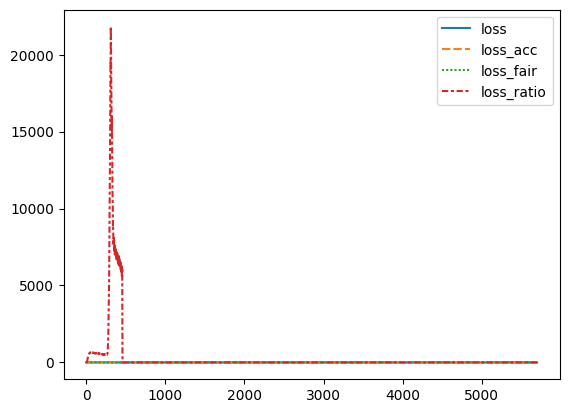

    -- lambda_fair=3, lambda_ratio=0.005, run=1
epoch 0 loss_acc 0.6918 loss_fair 2.0362 loss_ratio 458.2405 DP_gap_test 0.0762 EO_gap_test 0.2228 ACC_test 0.822 proportion_changed 0.5361
epoch 30 loss_acc 0.7118 loss_fair 2.0654 loss_ratio 2.1476 DP_gap_test 0.0725 EO_gap_test 0.1885 ACC_test 0.7618 proportion_changed 0.3627
epoch 60 loss_acc 0.7048 loss_fair 2.0559 loss_ratio 1.7004 DP_gap_test 0.2653 EO_gap_test 0.6184 ACC_test 0.8054 proportion_changed 0.4221
epoch 90 loss_acc 0.703 loss_fair 2.0592 loss_ratio 1.5873 DP_gap_test 0.2701 EO_gap_test 0.6182 ACC_test 0.8051 proportion_changed 0.4207
epoch 120 loss_acc 0.7043 loss_fair 2.0635 loss_ratio 1.6602 DP_gap_test 0.2588 EO_gap_test 0.5965 ACC_test 0.8068 proportion_changed 0.4245

Final DP gap: 0.2531101457173513
Final EO gap: 0.5870545062472732
Final Accuracy: 80.94564063478236
Final proportion changed: 0.43072379345074446
    -- lambda_fair=3, lambda_ratio=0.005, run=2
epoch 0 loss_acc 0.6936 loss_fair 2.05 loss_ratio 532.571

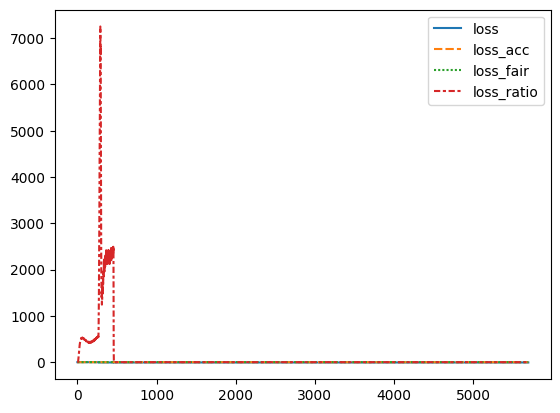

    -- lambda_fair=3, lambda_ratio=0.008, run=1
epoch 0 loss_acc 0.6954 loss_fair 2.0455 loss_ratio 561.7883 DP_gap_test 0.0715 EO_gap_test 0.2073 ACC_test 0.8208 proportion_changed 0.5381
epoch 30 loss_acc 0.7097 loss_fair 2.0603 loss_ratio 1.1207 DP_gap_test 0.3311 EO_gap_test 0.7265 ACC_test 0.7914 proportion_changed 0.3862
epoch 60 loss_acc 0.7108 loss_fair 2.0653 loss_ratio 1.0518 DP_gap_test 0.3304 EO_gap_test 0.7121 ACC_test 0.7913 proportion_changed 0.3848
epoch 90 loss_acc 0.7077 loss_fair 2.0483 loss_ratio 1.1226 DP_gap_test 0.3283 EO_gap_test 0.7208 ACC_test 0.7921 proportion_changed 0.388
epoch 120 loss_acc 0.7053 loss_fair 2.0539 loss_ratio 1.1503 DP_gap_test 0.3235 EO_gap_test 0.7064 ACC_test 0.794 proportion_changed 0.3911

Final DP gap: 0.3081354786970215
Final EO gap: 0.6783331432638076
Final Accuracy: 79.68260881400224
Final proportion changed: 0.39846748509676894
    -- lambda_fair=3, lambda_ratio=0.008, run=2
epoch 0 loss_acc 0.6946 loss_fair 2.0448 loss_ratio 564.6

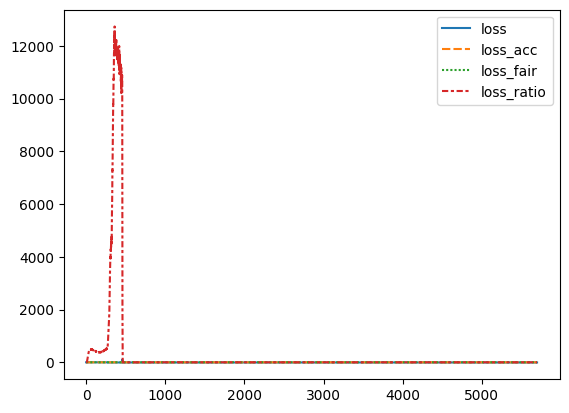

    -- lambda_fair=3, lambda_ratio=0.01, run=1
epoch 0 loss_acc 0.6924 loss_fair 2.0481 loss_ratio 545.9264 DP_gap_test 0.0723 EO_gap_test 0.2095 ACC_test 0.821 proportion_changed 0.5377
epoch 30 loss_acc 0.7069 loss_fair 2.0633 loss_ratio 1.0072 DP_gap_test 0.331 EO_gap_test 0.7213 ACC_test 0.786 proportion_changed 0.374
epoch 60 loss_acc 0.709 loss_fair 2.0574 loss_ratio 1.0239 DP_gap_test 0.2988 EO_gap_test 0.6704 ACC_test 0.7951 proportion_changed 0.3917
epoch 90 loss_acc 0.7085 loss_fair 2.0563 loss_ratio 0.902 DP_gap_test 0.3167 EO_gap_test 0.6992 ACC_test 0.7938 proportion_changed 0.388
epoch 120 loss_acc 0.7093 loss_fair 2.0547 loss_ratio 0.9512 DP_gap_test 0.3149 EO_gap_test 0.6938 ACC_test 0.7919 proportion_changed 0.3843

Final DP gap: 0.33000663862052565
Final EO gap: 0.7292588658594772
Final Accuracy: 79.11233905871464
Final proportion changed: 0.38141383346489915
    -- lambda_fair=3, lambda_ratio=0.01, run=2
epoch 0 loss_acc 0.6943 loss_fair 2.0533 loss_ratio 489.9382 DP

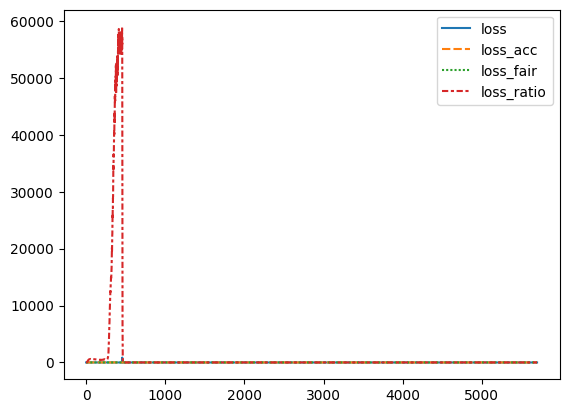

    -- lambda_fair=3, lambda_ratio=0.015, run=1
epoch 0 loss_acc 0.6921 loss_fair 2.0533 loss_ratio 468.8103 DP_gap_test 0.0738 EO_gap_test 0.2125 ACC_test 0.8208 proportion_changed 0.5371
epoch 30 loss_acc 0.7123 loss_fair 2.057 loss_ratio 0.6133 DP_gap_test 0.3968 EO_gap_test 0.8314 ACC_test 0.7686 proportion_changed 0.3319
epoch 60 loss_acc 0.7134 loss_fair 2.0568 loss_ratio 0.6024 DP_gap_test 0.3931 EO_gap_test 0.8195 ACC_test 0.7688 proportion_changed 0.3359
epoch 90 loss_acc 0.7091 loss_fair 2.0634 loss_ratio 0.671 DP_gap_test 0.3875 EO_gap_test 0.8146 ACC_test 0.7701 proportion_changed 0.3408
epoch 120 loss_acc 0.7075 loss_fair 2.0647 loss_ratio 0.6648 DP_gap_test 0.3814 EO_gap_test 0.8102 ACC_test 0.7748 proportion_changed 0.3499

Final DP gap: 0.37746335760518834
Final EO gap: 0.7999021539030056
Final Accuracy: 77.57982415548356
Final proportion changed: 0.3511718431009609
    -- lambda_fair=3, lambda_ratio=0.015, run=2
epoch 0 loss_acc 0.6928 loss_fair 2.0358 loss_ratio 562.9

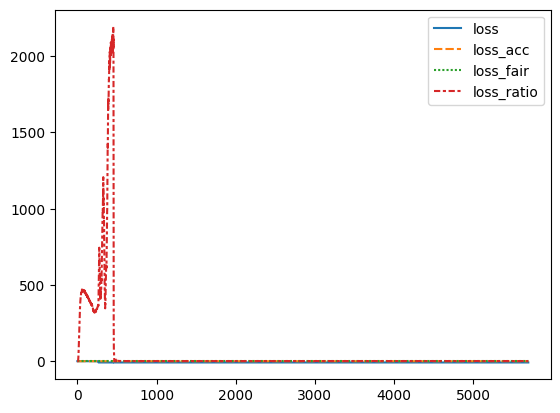

    -- lambda_fair=4, lambda_ratio=0.005, run=1
epoch 0 loss_acc 0.6931 loss_fair 2.0475 loss_ratio 648.4144 DP_gap_test 0.0715 EO_gap_test 0.2073 ACC_test 0.8209 proportion_changed 0.5381
epoch 30 loss_acc 0.7073 loss_fair 2.058 loss_ratio 1.6075 DP_gap_test 0.2377 EO_gap_test 0.4414 ACC_test 0.7886 proportion_changed 0.3842
epoch 60 loss_acc 0.7043 loss_fair 2.0589 loss_ratio 1.681 DP_gap_test 0.2855 EO_gap_test 0.6342 ACC_test 0.8019 proportion_changed 0.4121
epoch 90 loss_acc 0.7007 loss_fair 2.0633 loss_ratio 1.684 DP_gap_test 0.2747 EO_gap_test 0.626 ACC_test 0.8057 proportion_changed 0.4202
epoch 120 loss_acc 0.6992 loss_fair 2.0567 loss_ratio 1.7528 DP_gap_test 0.2566 EO_gap_test 0.5939 ACC_test 0.8096 proportion_changed 0.4309

Final DP gap: 0.25502483998962977
Final EO gap: 0.5977685229320305
Final Accuracy: 81.16204371614448
Final proportion changed: 0.43484770122764516
    -- lambda_fair=4, lambda_ratio=0.005, run=2
epoch 0 loss_acc 0.6955 loss_fair 2.0418 loss_ratio 583.20

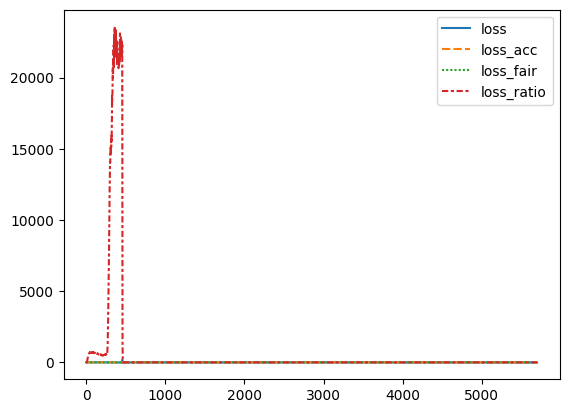

    -- lambda_fair=4, lambda_ratio=0.008, run=1
epoch 0 loss_acc 0.6987 loss_fair 2.0482 loss_ratio 562.2349 DP_gap_test 0.0713 EO_gap_test 0.2064 ACC_test 0.8207 proportion_changed 0.5382
epoch 30 loss_acc 0.7166 loss_fair 2.068 loss_ratio 2.0079 DP_gap_test 0.1012 EO_gap_test 0.3828 ACC_test 0.7427 proportion_changed 0.3813
epoch 60 loss_acc 0.7073 loss_fair 2.0694 loss_ratio 1.1279 DP_gap_test 0.3082 EO_gap_test 0.6618 ACC_test 0.7924 proportion_changed 0.3862
epoch 90 loss_acc 0.7067 loss_fair 2.0657 loss_ratio 1.1032 DP_gap_test 0.298 EO_gap_test 0.6431 ACC_test 0.7951 proportion_changed 0.3931
epoch 120 loss_acc 0.708 loss_fair 2.0585 loss_ratio 1.1296 DP_gap_test 0.3064 EO_gap_test 0.6744 ACC_test 0.7974 proportion_changed 0.3986

Final DP gap: 0.30976125376395036
Final EO gap: 0.6899486722452384
Final Accuracy: 79.74929907178048
Final proportion changed: 0.40093094155755776
    -- lambda_fair=4, lambda_ratio=0.008, run=2
epoch 0 loss_acc 0.6957 loss_fair 2.049 loss_ratio 310.98

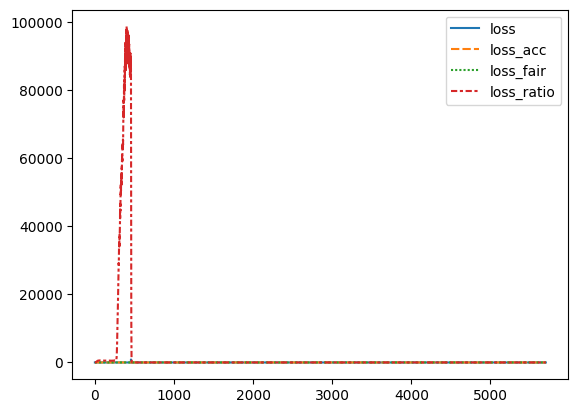

    -- lambda_fair=4, lambda_ratio=0.01, run=1
epoch 0 loss_acc 0.6927 loss_fair 2.042 loss_ratio 469.4005 DP_gap_test 0.0738 EO_gap_test 0.2137 ACC_test 0.8211 proportion_changed 0.5373
epoch 30 loss_acc 0.7135 loss_fair 2.0533 loss_ratio 0.9877 DP_gap_test 0.2812 EO_gap_test 0.5754 ACC_test 0.7694 proportion_changed 0.3461
epoch 60 loss_acc 0.7104 loss_fair 2.055 loss_ratio 0.9098 DP_gap_test 0.3329 EO_gap_test 0.7237 ACC_test 0.7824 proportion_changed 0.3637
epoch 90 loss_acc 0.7095 loss_fair 2.0547 loss_ratio 0.8694 DP_gap_test 0.3375 EO_gap_test 0.7372 ACC_test 0.7818 proportion_changed 0.365
epoch 120 loss_acc 0.7087 loss_fair 2.0632 loss_ratio 0.9037 DP_gap_test 0.3309 EO_gap_test 0.7264 ACC_test 0.7839 proportion_changed 0.371

Final DP gap: 0.3307955994960144
Final EO gap: 0.728948879514419
Final Accuracy: 78.54206930342707
Final proportion changed: 0.3735879358684705
    -- lambda_fair=4, lambda_ratio=0.01, run=2
epoch 0 loss_acc 0.6948 loss_fair 2.0408 loss_ratio 627.4588 DP

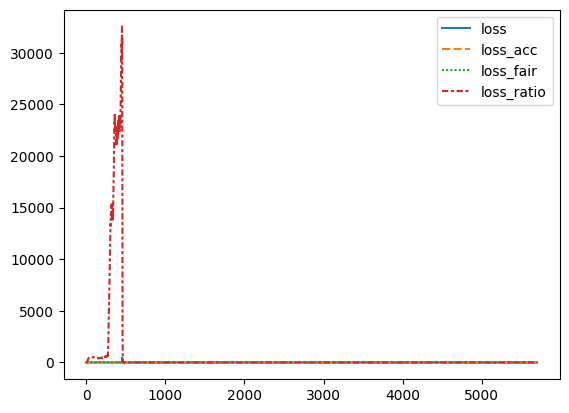

    -- lambda_fair=4, lambda_ratio=0.015, run=1
epoch 0 loss_acc 0.6954 loss_fair 2.0456 loss_ratio 538.8448 DP_gap_test 0.0712 EO_gap_test 0.2056 ACC_test 0.8204 proportion_changed 0.5382
epoch 30 loss_acc 0.7397 loss_fair 2.0645 loss_ratio 0.7157 DP_gap_test 0.072 EO_gap_test 0.1863 ACC_test 0.6277 proportion_changed 0.3411
epoch 60 loss_acc 0.7121 loss_fair 2.0551 loss_ratio 0.6132 DP_gap_test 0.3788 EO_gap_test 0.7795 ACC_test 0.7655 proportion_changed 0.3251
epoch 90 loss_acc 0.7153 loss_fair 2.0689 loss_ratio 0.5895 DP_gap_test 0.3842 EO_gap_test 0.8044 ACC_test 0.767 proportion_changed 0.3289
epoch 120 loss_acc 0.7159 loss_fair 2.0499 loss_ratio 0.6171 DP_gap_test 0.3794 EO_gap_test 0.806 ACC_test 0.7708 proportion_changed 0.3391

Final DP gap: 0.38261467710187214
Final EO gap: 0.8071890852177315
Final Accuracy: 77.12796363339413
Final proportion changed: 0.3403925198029235
    -- lambda_fair=4, lambda_ratio=0.015, run=2
epoch 0 loss_acc 0.6973 loss_fair 2.0502 loss_ratio 561.39

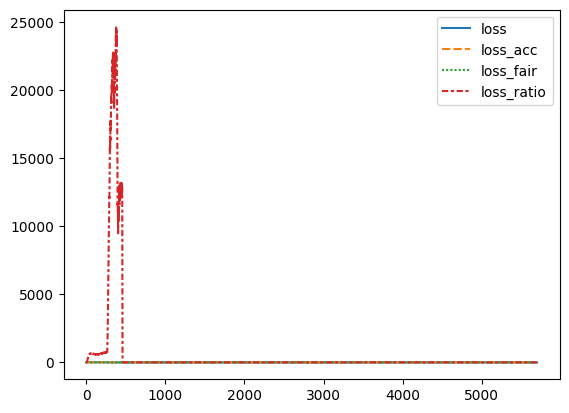

    -- lambda_fair=5, lambda_ratio=0.005, run=1
epoch 0 loss_acc 0.6964 loss_fair 2.0481 loss_ratio 444.1273 DP_gap_test 0.0739 EO_gap_test 0.2144 ACC_test 0.8213 proportion_changed 0.5371
epoch 30 loss_acc 0.755 loss_fair 1.8558 loss_ratio 0.0389 DP_gap_test 0.6074 EO_gap_test 0.9659 ACC_test 0.4128 proportion_changed 0.1879
epoch 60 loss_acc 0.7273 loss_fair 1.854 loss_ratio 0.1045 DP_gap_test 0.5243 EO_gap_test 0.9786 ACC_test 0.6906 proportion_changed 0.1917
epoch 90 loss_acc 0.7178 loss_fair 1.8252 loss_ratio 0.6518 DP_gap_test 0.399 EO_gap_test 0.8324 ACC_test 0.77 proportion_changed 0.3303
epoch 120 loss_acc 0.7043 loss_fair 1.8384 loss_ratio 1.4326 DP_gap_test 0.3102 EO_gap_test 0.6867 ACC_test 0.7976 proportion_changed 0.3981

Final DP gap: 0.2414646808986235
Final EO gap: 0.5616433448264597
Final Accuracy: 81.31720064240412
Final proportion changed: 0.44097231673789367
    -- lambda_fair=5, lambda_ratio=0.005, run=2
epoch 0 loss_acc 0.6959 loss_fair 2.0517 loss_ratio 393.5638

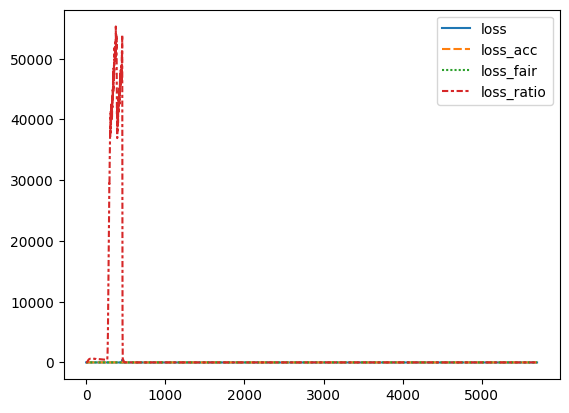

    -- lambda_fair=5, lambda_ratio=0.008, run=1
epoch 0 loss_acc 0.6927 loss_fair 2.043 loss_ratio 517.2591 DP_gap_test 0.0733 EO_gap_test 0.2121 ACC_test 0.8211 proportion_changed 0.5372
epoch 30 loss_acc 0.7094 loss_fair 2.0523 loss_ratio 1.0966 DP_gap_test 0.3386 EO_gap_test 0.7463 ACC_test 0.7776 proportion_changed 0.3568
epoch 60 loss_acc 0.7051 loss_fair 2.0603 loss_ratio 1.0907 DP_gap_test 0.3246 EO_gap_test 0.7096 ACC_test 0.7872 proportion_changed 0.3736
epoch 90 loss_acc 0.7044 loss_fair 2.0654 loss_ratio 1.0703 DP_gap_test 0.3283 EO_gap_test 0.7164 ACC_test 0.7868 proportion_changed 0.3748
epoch 120 loss_acc 0.7056 loss_fair 2.0578 loss_ratio 1.0876 DP_gap_test 0.3194 EO_gap_test 0.6905 ACC_test 0.791 proportion_changed 0.3846

Final DP gap: 0.29739481701265363
Final EO gap: 0.656695180207295
Final Accuracy: 79.58733701717614
Final proportion changed: 0.39471105425048314
    -- lambda_fair=5, lambda_ratio=0.008, run=2
epoch 0 loss_acc 0.6928 loss_fair 2.0494 loss_ratio 583.0

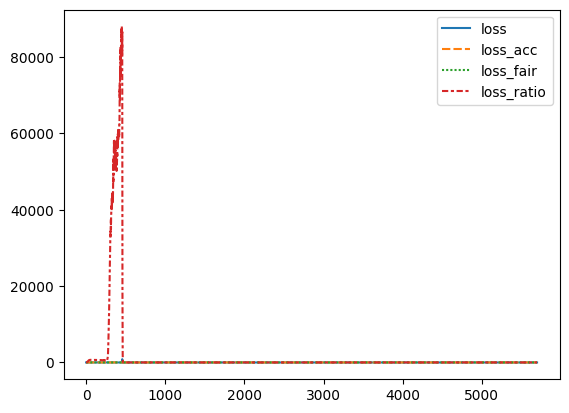

    -- lambda_fair=5, lambda_ratio=0.01, run=1
epoch 0 loss_acc 0.6949 loss_fair 2.0445 loss_ratio 444.5638 DP_gap_test 0.0739 EO_gap_test 0.2129 ACC_test 0.821 proportion_changed 0.5369
epoch 30 loss_acc 0.7118 loss_fair 2.0615 loss_ratio 0.8302 DP_gap_test 0.3614 EO_gap_test 0.7655 ACC_test 0.782 proportion_changed 0.364
epoch 60 loss_acc 0.7075 loss_fair 2.0568 loss_ratio 0.8667 DP_gap_test 0.3565 EO_gap_test 0.7637 ACC_test 0.7843 proportion_changed 0.3696
epoch 90 loss_acc 0.7053 loss_fair 2.0614 loss_ratio 0.9515 DP_gap_test 0.3488 EO_gap_test 0.7481 ACC_test 0.7854 proportion_changed 0.3736
epoch 120 loss_acc 0.7065 loss_fair 2.0618 loss_ratio 0.9507 DP_gap_test 0.3519 EO_gap_test 0.7587 ACC_test 0.7861 proportion_changed 0.3753

Final DP gap: 0.35209744952850647
Final EO gap: 0.7624266165312708
Final Accuracy: 78.54206930342707
Final proportion changed: 0.37549337180499226
    -- lambda_fair=5, lambda_ratio=0.01, run=2
epoch 0 loss_acc 0.6912 loss_fair 2.0449 loss_ratio 520.265

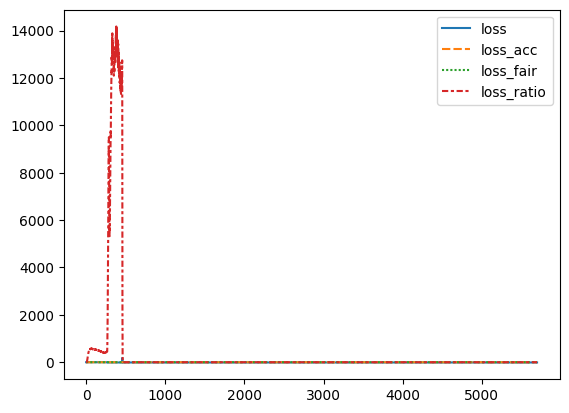

    -- lambda_fair=5, lambda_ratio=0.015, run=1
epoch 0 loss_acc 0.6958 loss_fair 2.0457 loss_ratio 616.7142 DP_gap_test 0.071 EO_gap_test 0.2052 ACC_test 0.8204 proportion_changed 0.5384
epoch 30 loss_acc 0.7694 loss_fair 2.055 loss_ratio 0.8732 DP_gap_test 0.0908 EO_gap_test 0.2071 ACC_test 0.41 proportion_changed 0.3534
epoch 60 loss_acc 0.7206 loss_fair 2.0652 loss_ratio 0.9818 DP_gap_test 0.1147 EO_gap_test 0.1641 ACC_test 0.725 proportion_changed 0.3243
epoch 90 loss_acc 0.7127 loss_fair 2.0593 loss_ratio 0.5996 DP_gap_test 0.3813 EO_gap_test 0.8017 ACC_test 0.7624 proportion_changed 0.3226
epoch 120 loss_acc 0.7153 loss_fair 2.065 loss_ratio 0.6103 DP_gap_test 0.3997 EO_gap_test 0.8351 ACC_test 0.7634 proportion_changed 0.3253

Final DP gap: 0.39895969948908033
Final EO gap: 0.8374508313391935
Final Accuracy: 76.3834825924817
Final proportion changed: 0.32671421183003513
    -- lambda_fair=5, lambda_ratio=0.015, run=2
epoch 0 loss_acc 0.6938 loss_fair 2.0435 loss_ratio 597.7209 

In [ ]:
import itertools
import pandas as pd

lamb_fair_grid = [3, 4, 5]
lamb_ratio_grid = [0.005, 0.008, 0.01, 0.015]
n_runs = 3   # 각 grid_search 조합 3번씩 반복 (같은 조합이라도 배치 순서에 따라 결과 변화할 수 있음)

attr = 'age_gender'
print(f"\n{'='*60}\nAttribute: {attr}\n{'='*60}")

S_train_cat, S_val_cat, n_classes = get_sensitive_attribute(
    data, attr, sens_config, idx_train, idx_val
)

all_cats = pd.concat([S_train_cat, S_val_cat]).astype('category')
S_train_codes = all_cats.cat.codes[:len(S_train_cat)].values
S_val_codes = all_cats.cat.codes[len(S_train_cat):].values

print(f"  -> {n_classes} categories: {list(all_cats.cat.categories)}")

input_dim = X_train.shape[1]
attr_grid_results = []

for lamb_fair, lamb_ratio in itertools.product(lamb_fair_grid, lamb_ratio_grid):

    for run in range(n_runs):
        print(f"    -- lambda_fair={lamb_fair}, lambda_ratio={lamb_ratio}, run={run}")

        NN_r = make_NN_r(input_dim, hidden=(64, 32))

        rbmd_model = rbmd_debiasing(
            learning_rate=0.01,
            batch_size=2048,   #512->2048 (데이터 크기 커서 512로 하면 시간 너무 오래 걸림)
            lamb_fair=lamb_fair,
            lamb_ratio=lamb_ratio,
            num_epochs=150,   #1000 -> 150 (데이터 크기에 맞춰 조절)
            NN_r=NN_r,
            n_classes=n_classes,
            GPU='cuda:0',
            threshold=THRESHOLD
        )

        rbmd_model.train(
            X_train, y_train, S_train_codes,
            y_hat=proba_train,
            X_test=X_val, y_test=y_val, S_test=S_val_codes,
            y_hat_test=proba_val,
            plot_losses=(run == 0)   # grid_search 조합당 첫 run만 그래프 출력
        )

        val_probs = rbmd_model.predict_proba(X_val, proba_val)
        val_preds = rbmd_model.predict(X_val, proba_val)

        attr_grid_results.append({
            'lambda_fair': lamb_fair,
            'lambda_ratio': lamb_ratio,
            'run': run,   # 몇 번째 run인지 기록
            'n_classes': n_classes,
            'DP_gap_val': group_fairness_gap(val_preds, S_val_codes),
            'EO_gap_val': disparate_mistreatment_general(val_preds, y_val, S_val_codes),
            'accuracy_val': float(np.mean(val_preds == y_val)),
            'f1_val': f1_score(y_val, val_preds),
            'precision_val': precision_score(y_val, val_preds, zero_division=0),
            'recall_val': recall_score(y_val, val_preds, zero_division=0),
            'pr_auc_val': average_precision_score(y_val, val_probs),
            'roc_auc_val': roc_auc_score(y_val, val_probs),
            'proportion_changed_val': float(np.mean(val_preds != (proba_val > THRESHOLD))),
        })

grid_results = {}
grid_results[attr] = pd.DataFrame(attr_grid_results)

grid_summary = (
    grid_results[attr]
    .groupby(['lambda_fair', 'lambda_ratio'])
    .agg(
        DP_gap_mean=('DP_gap_val', 'mean'), DP_gap_std=('DP_gap_val', 'std'),
        EO_gap_mean=('EO_gap_val', 'mean'), EO_gap_std=('EO_gap_val', 'std'),
        accuracy_mean=('accuracy_val', 'mean'), accuracy_std=('accuracy_val', 'std'),
        f1_mean=('f1_val', 'mean'), f1_std=('f1_val', 'std'),
        precision_mean=('precision_val', 'mean'), precision_std=('precision_val', 'std'),
        recall_mean=('recall_val', 'mean'), recall_std=('recall_val', 'std'),
        pr_auc_mean=('pr_auc_val', 'mean'), pr_auc_std=('pr_auc_val', 'std'),
        roc_auc_mean=('roc_auc_val', 'mean'), roc_auc_std=('roc_auc_val', 'std'),
        proportion_changed_mean=('proportion_changed_val', 'mean'),
        proportion_changed_std=('proportion_changed_val', 'std'),
    )
    .reset_index()
)

# baseline
baseline_preds = (proba_val > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) ===")
print("F1:", f1_score(y_val, baseline_preds))
print("Precision:", precision_score(y_val, baseline_preds, zero_division=0))
print("Recall:", recall_score(y_val, baseline_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_val, proba_val))
print("ROC-AUC:", roc_auc_score(y_val, proba_val))

# 튜닝 후
print(f"\n  [{attr}] Grid search 결과 (val, accuracy 높은 순 상위 5개):")
print(grid_summary.sort_values('accuracy_mean', ascending=False).head())

print(f"\n  [{attr}] Grid search 결과 (val, 변화 최소화 우선 상위 5개):")
print(grid_summary.sort_values('proportion_changed_mean').head())

print(f"\n  [{attr}] Grid search 결과 (val, DP gap 낮은 순 상위 5개):")
print(grid_summary.sort_values('DP_gap_mean').head())

- std 매우 낮음. 각 grid_search 조합별로 3번씩 돌리기 대신 1번만 돌리는 걸로 변경

In [ ]:
import itertools
import pandas as pd

lamb_fair_grid = [0.5, 1, 2, 4, 6]   # COMMOD: lambda_fair_grid <= 10
lamb_ratio_grid = [0.01, 0.05, 0.1, 0.25, 0.5]     # COMMOD: lambda_ratio_grid <= 0.5

attr = 'age_gender'
print(f"\n{'='*60}\nAttribute: {attr}\n{'='*60}")

# train/val 각각의 sensitive attribute 추출 (idx_val 필요)
S_train_cat, S_val_cat, n_classes = get_sensitive_attribute(
    data, attr, sens_config, idx_train, idx_val
)

all_cats = pd.concat([S_train_cat, S_val_cat]).astype('category')
S_train_codes = all_cats.cat.codes[:len(S_train_cat)].values
S_val_codes = all_cats.cat.codes[len(S_train_cat):].values

print(f"  -> {n_classes} categories: {list(all_cats.cat.categories)}")

input_dim = X_train.shape[1]
attr_grid_results = []

for lamb_fair, lamb_ratio in itertools.product(lamb_fair_grid, lamb_ratio_grid):
    print(f"    -- lambda_fair={lamb_fair}, lambda_ratio={lamb_ratio}")

    NN_r = make_NN_r(input_dim, hidden=(64, 32))

    rbmd_model = rbmd_debiasing(
        learning_rate=0.01,   # 학습 데이터셋 크기 고려해 조정 (원래 0.001)
        batch_size=2048,
        lamb_fair=lamb_fair,
        lamb_ratio=lamb_ratio,
        num_epochs=150,    # 학습 데이터셋 크기 고려해 조정 (원래 1000)
        NN_r=NN_r,
        n_classes=n_classes,
        GPU='cuda:0',
        threshold=THRESHOLD
    )

    rbmd_model.train(
        X_train, y_train, S_train_codes,
        y_hat=proba_train,
        X_test=X_val, y_test=y_val, S_test=S_val_codes,   # 2018 데이터 사용해서 r(X) 최적화
        y_hat_test=proba_val,
        plot_losses=True
    )

    val_probs = rbmd_model.predict_proba(X_val, proba_val)
    val_preds = rbmd_model.predict(X_val, proba_val)

    attr_grid_results.append({
        'lambda_fair': lamb_fair,
        'lambda_ratio': lamb_ratio,
        'n_classes': n_classes,
        'DP_gap_val': group_fairness_gap(val_preds, S_val_codes),
        'EO_gap_val': disparate_mistreatment_general(val_preds, y_val, S_val_codes),
        'accuracy_val': float(np.mean(val_preds == y_val)),
        'f1_val': f1_score(y_val, val_preds),
        'precision_val': precision_score(y_val, val_preds, zero_division=0),
        'recall_val': recall_score(y_val, val_preds, zero_division=0),
        'pr_auc_val': average_precision_score(y_val, val_probs),
        'roc_auc_val': roc_auc_score(y_val, val_probs),
        'proportion_changed_val': float(np.mean(val_preds != (proba_val > THRESHOLD))),
    })

grid_results = {}
grid_results[attr] = pd.DataFrame(attr_grid_results)
# baseline
baseline_preds = (proba_val > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) ===")
print("F1:", f1_score(y_val, baseline_preds))
print("Precision:", precision_score(y_val, baseline_preds, zero_division=0))
print("Recall:", recall_score(y_val, baseline_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_val, proba_val))
print("ROC-AUC:", roc_auc_score(y_val, proba_val))

# 튜닝 후
print(f"\n  [{attr}] Grid search 결과 (val, accuracy 높은 순 상위 5개):")
print(grid_results[attr].sort_values('accuracy_val', ascending=False).head())

print(f"\n  [{attr}] Grid search 결과 (val, 변화 최소화 우선 상위 5개):")
print(grid_results[attr].sort_values('proportion_changed_val').head())

print(f"\n  [{attr}] Grid search 결과 (val, DP gap 낮은 순 상위 5개):")
print(grid_results[attr].sort_values('DP_gap_val').head())


Attribute: age_gender
  -> 8 categories: ['고령 F', '고령 M', '장년 F', '장년 M', '중년 F', '중년 M', '청년 F', '청년 M']
    -- lambda_fair=0.5, lambda_ratio=0.01
epoch 0 loss_acc 0.7003 loss_fair 2.0217 loss_ratio 492.2958 DP_gap_test 0.0891 EO_gap_test 0.2661 ACC_test 0.8268 proportion_changed 0.5301
epoch 30 loss_acc 0.7057 loss_fair 2.061 loss_ratio 0.9485 DP_gap_test 0.3806 EO_gap_test 0.7963 ACC_test 0.7678 proportion_changed 0.3311
epoch 60 loss_acc 0.711 loss_fair 2.0468 loss_ratio 0.6712 DP_gap_test 0.3384 EO_gap_test 0.7267 ACC_test 0.7867 proportion_changed 0.3744
epoch 90 loss_acc 0.7047 loss_fair 2.0505 loss_ratio 0.9029 DP_gap_test 0.307 EO_gap_test 0.6743 ACC_test 0.7944 proportion_changed 0.3946
epoch 120 loss_acc 0.7031 loss_fair 2.0546 loss_ratio 1.1372 DP_gap_test 0.3172 EO_gap_test 0.6764 ACC_test 0.7917 proportion_changed 0.3841

Final DP gap: 0.31569599059832626
Final EO gap: 0.6908331993668373
Final Accuracy: 79.39815444919292
Final proportion changed: 0.3869123771674334
    -

In [ ]:
best_row = grid_results['age_gender'].sort_values('DP_gap_val').iloc[0]   # DP gap 최소 기준
best_lamb_fair = best_row['lambda_fair']
best_lamb_ratio = best_row['lambda_ratio']
print("선택된 조합:", best_lamb_fair, best_lamb_ratio)

선택된 조합: 4.0 0.01


- 최적 조합 lambda_fair=4.0, lambda_ratio=0.01 (accuracy 최대 & DP Gap 최소) -> 범위 조절 후 다시 grid search + gradient descent


Attribute: age_gender
  -> 8 categories: ['고령 F', '고령 M', '장년 F', '장년 M', '중년 F', '중년 M', '청년 F', '청년 M']
    -- lambda_fair=3, lambda_ratio=0.005
epoch 0 loss_acc 0.6949 loss_fair 2.0403 loss_ratio 480.36 DP_gap_test 0.0737 EO_gap_test 0.2153 ACC_test 0.8215 proportion_changed 0.537
epoch 30 loss_acc 0.7045 loss_fair 2.0594 loss_ratio 1.6723 DP_gap_test 0.2676 EO_gap_test 0.6154 ACC_test 0.8076 proportion_changed 0.4233
epoch 60 loss_acc 0.7022 loss_fair 2.0599 loss_ratio 1.5372 DP_gap_test 0.2958 EO_gap_test 0.6723 ACC_test 0.8002 proportion_changed 0.4101
epoch 90 loss_acc 0.7005 loss_fair 2.0596 loss_ratio 1.7163 DP_gap_test 0.2479 EO_gap_test 0.5704 ACC_test 0.8138 proportion_changed 0.4397
epoch 120 loss_acc 0.6956 loss_fair 2.0598 loss_ratio 1.7019 DP_gap_test 0.2312 EO_gap_test 0.5251 ACC_test 0.8116 proportion_changed 0.4376

Final DP gap: 0.23663009190197606
Final EO gap: 0.5442319532406266
Final Accuracy: 81.01505294389852
Final proportion changed: 0.43364999863897435


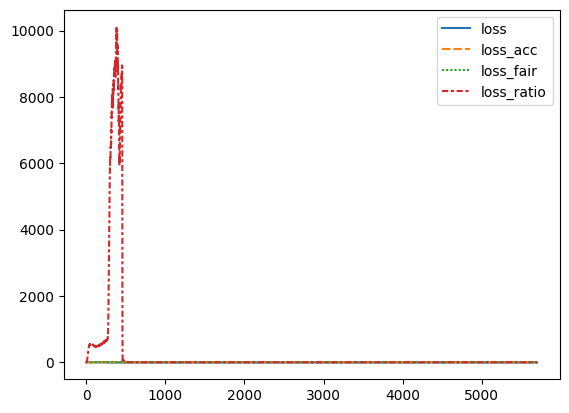

    -- lambda_fair=3, lambda_ratio=0.008
epoch 0 loss_acc 0.6992 loss_fair 2.0427 loss_ratio 657.9805 DP_gap_test 0.0708 EO_gap_test 0.2045 ACC_test 0.8205 proportion_changed 0.5386
epoch 30 loss_acc 0.7052 loss_fair 2.0518 loss_ratio 1.0321 DP_gap_test 0.3261 EO_gap_test 0.7131 ACC_test 0.7922 proportion_changed 0.3877
epoch 60 loss_acc 0.7083 loss_fair 2.0635 loss_ratio 1.0868 DP_gap_test 0.3259 EO_gap_test 0.7168 ACC_test 0.7925 proportion_changed 0.3876
epoch 90 loss_acc 0.7075 loss_fair 2.0579 loss_ratio 1.1117 DP_gap_test 0.3296 EO_gap_test 0.7315 ACC_test 0.7916 proportion_changed 0.3863
epoch 120 loss_acc 0.7079 loss_fair 2.0587 loss_ratio 1.1641 DP_gap_test 0.3261 EO_gap_test 0.7175 ACC_test 0.7931 proportion_changed 0.3905

Final DP gap: 0.2956040670929492
Final EO gap: 0.6435798042843371
Final Accuracy: 79.85545907395813
Final proportion changed: 0.40112148515120993


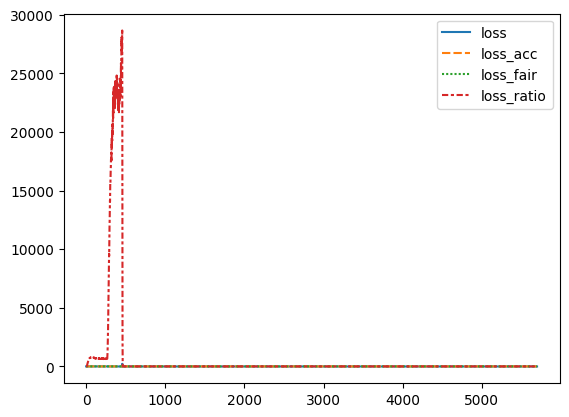

    -- lambda_fair=3, lambda_ratio=0.01
epoch 0 loss_acc 0.6967 loss_fair 2.0509 loss_ratio 598.2961 DP_gap_test 0.0717 EO_gap_test 0.2078 ACC_test 0.8211 proportion_changed 0.5378
epoch 30 loss_acc 0.7076 loss_fair 2.057 loss_ratio 0.8963 DP_gap_test 0.3495 EO_gap_test 0.7653 ACC_test 0.7811 proportion_changed 0.3638
epoch 60 loss_acc 0.7105 loss_fair 2.0652 loss_ratio 0.831 DP_gap_test 0.3536 EO_gap_test 0.768 ACC_test 0.7817 proportion_changed 0.3652
epoch 90 loss_acc 0.711 loss_fair 2.0545 loss_ratio 0.8985 DP_gap_test 0.3513 EO_gap_test 0.7598 ACC_test 0.7812 proportion_changed 0.3668
epoch 120 loss_acc 0.7108 loss_fair 2.0606 loss_ratio 0.9212 DP_gap_test 0.3433 EO_gap_test 0.7494 ACC_test 0.7834 proportion_changed 0.37

Final DP gap: 0.3402387301150673
Final EO gap: 0.7414488893197535
Final Accuracy: 78.41685494188421
Final proportion changed: 0.36950485886163814


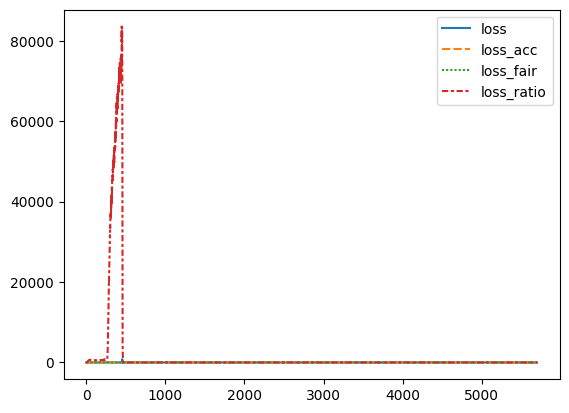

    -- lambda_fair=3, lambda_ratio=0.015
epoch 0 loss_acc 0.6937 loss_fair 2.0512 loss_ratio 441.8884 DP_gap_test 0.074 EO_gap_test 0.2137 ACC_test 0.821 proportion_changed 0.5371
epoch 30 loss_acc 0.7154 loss_fair 2.0597 loss_ratio 0.5737 DP_gap_test 0.389 EO_gap_test 0.7955 ACC_test 0.7687 proportion_changed 0.3304
epoch 60 loss_acc 0.7148 loss_fair 2.0598 loss_ratio 0.5751 DP_gap_test 0.3891 EO_gap_test 0.7962 ACC_test 0.7684 proportion_changed 0.3306
epoch 90 loss_acc 0.7136 loss_fair 2.0537 loss_ratio 0.5897 DP_gap_test 0.3949 EO_gap_test 0.8182 ACC_test 0.7684 proportion_changed 0.3315
epoch 120 loss_acc 0.7117 loss_fair 2.0527 loss_ratio 0.5056 DP_gap_test 0.3991 EO_gap_test 0.8157 ACC_test 0.7648 proportion_changed 0.3259

Final DP gap: 0.4006158444066021
Final EO gap: 0.8212971739968195
Final Accuracy: 76.68563029098728
Final proportion changed: 0.3274491656912649


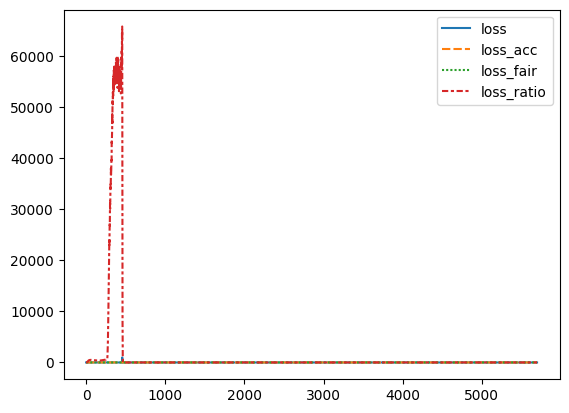

    -- lambda_fair=4, lambda_ratio=0.005
epoch 0 loss_acc 0.6939 loss_fair 2.0401 loss_ratio 620.364 DP_gap_test 0.0708 EO_gap_test 0.2045 ACC_test 0.8205 proportion_changed 0.5385
epoch 30 loss_acc 0.7024 loss_fair 2.0573 loss_ratio 1.6903 DP_gap_test 0.2789 EO_gap_test 0.6383 ACC_test 0.8047 proportion_changed 0.4168
epoch 60 loss_acc 0.6989 loss_fair 2.0506 loss_ratio 1.7191 DP_gap_test 0.2601 EO_gap_test 0.6136 ACC_test 0.809 proportion_changed 0.4253
epoch 90 loss_acc 0.7002 loss_fair 2.0603 loss_ratio 1.6897 DP_gap_test 0.2466 EO_gap_test 0.5993 ACC_test 0.8127 proportion_changed 0.4346
epoch 120 loss_acc 0.6983 loss_fair 2.0544 loss_ratio 1.6096 DP_gap_test 0.2428 EO_gap_test 0.5848 ACC_test 0.8138 proportion_changed 0.4324

Final DP gap: 0.2328925721554628
Final EO gap: 0.5718622004623637
Final Accuracy: 81.59348885319977
Final proportion changed: 0.4383727577102104


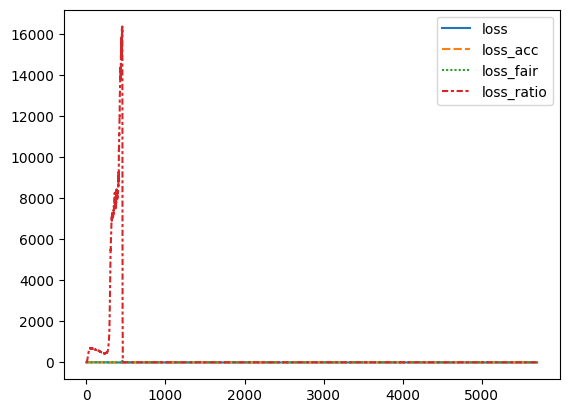

    -- lambda_fair=4, lambda_ratio=0.008
epoch 0 loss_acc 0.6936 loss_fair 2.0406 loss_ratio 548.9424 DP_gap_test 0.0717 EO_gap_test 0.2066 ACC_test 0.8205 proportion_changed 0.5381
epoch 30 loss_acc 0.7077 loss_fair 2.0569 loss_ratio 1.1114 DP_gap_test 0.3088 EO_gap_test 0.6679 ACC_test 0.7861 proportion_changed 0.3745
epoch 60 loss_acc 0.7101 loss_fair 2.0605 loss_ratio 1.0829 DP_gap_test 0.3095 EO_gap_test 0.6666 ACC_test 0.7902 proportion_changed 0.3819
epoch 90 loss_acc 0.7069 loss_fair 2.0579 loss_ratio 1.0847 DP_gap_test 0.2983 EO_gap_test 0.646 ACC_test 0.7942 proportion_changed 0.3917
epoch 120 loss_acc 0.7094 loss_fair 2.0596 loss_ratio 1.021 DP_gap_test 0.3054 EO_gap_test 0.6659 ACC_test 0.795 proportion_changed 0.3918

Final DP gap: 0.28958215214635746
Final EO gap: 0.6196419102924029
Final Accuracy: 79.75338214878732
Final proportion changed: 0.4066880801371914


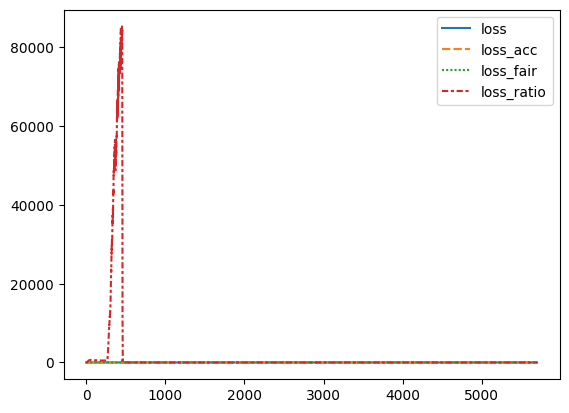

    -- lambda_fair=4, lambda_ratio=0.01
epoch 0 loss_acc 0.6905 loss_fair 2.0468 loss_ratio 538.0257 DP_gap_test 0.0728 EO_gap_test 0.2114 ACC_test 0.8212 proportion_changed 0.5374
epoch 30 loss_acc 0.711 loss_fair 2.057 loss_ratio 0.9374 DP_gap_test 0.3533 EO_gap_test 0.7552 ACC_test 0.7856 proportion_changed 0.3692
epoch 60 loss_acc 0.7113 loss_fair 2.0596 loss_ratio 0.8872 DP_gap_test 0.3574 EO_gap_test 0.7781 ACC_test 0.7843 proportion_changed 0.3682
epoch 90 loss_acc 0.709 loss_fair 2.0629 loss_ratio 0.9094 DP_gap_test 0.3539 EO_gap_test 0.7709 ACC_test 0.7836 proportion_changed 0.3685
epoch 120 loss_acc 0.7071 loss_fair 2.0558 loss_ratio 0.8979 DP_gap_test 0.3404 EO_gap_test 0.7392 ACC_test 0.787 proportion_changed 0.3749

Final DP gap: 0.33096611788658664
Final EO gap: 0.7218193202418519
Final Accuracy: 79.07014726297737
Final proportion changed: 0.3830606745243215


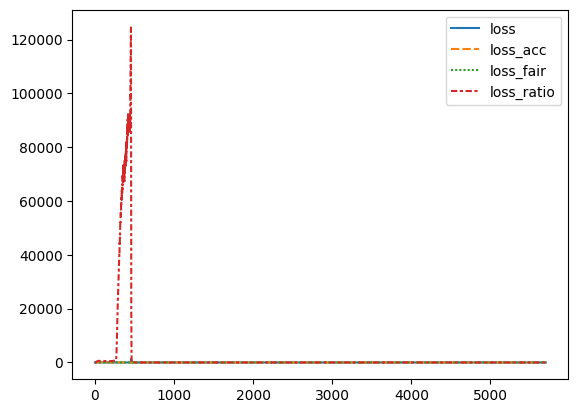

    -- lambda_fair=4, lambda_ratio=0.015
epoch 0 loss_acc 0.6928 loss_fair 2.0526 loss_ratio 571.7052 DP_gap_test 0.0728 EO_gap_test 0.2108 ACC_test 0.821 proportion_changed 0.5375
epoch 30 loss_acc 0.7128 loss_fair 2.062 loss_ratio 0.6598 DP_gap_test 0.3996 EO_gap_test 0.8375 ACC_test 0.76 proportion_changed 0.3168
epoch 60 loss_acc 0.7148 loss_fair 2.0594 loss_ratio 0.6932 DP_gap_test 0.3647 EO_gap_test 0.781 ACC_test 0.7794 proportion_changed 0.3554
epoch 90 loss_acc 0.7121 loss_fair 2.0582 loss_ratio 0.654 DP_gap_test 0.3605 EO_gap_test 0.7687 ACC_test 0.7802 proportion_changed 0.3604
epoch 120 loss_acc 0.7129 loss_fair 2.0593 loss_ratio 0.7083 DP_gap_test 0.3483 EO_gap_test 0.7583 ACC_test 0.7838 proportion_changed 0.366

Final DP gap: 0.3614499906274689
Final EO gap: 0.7800662910619507
Final Accuracy: 78.02760160056619
Final proportion changed: 0.3586166535100852


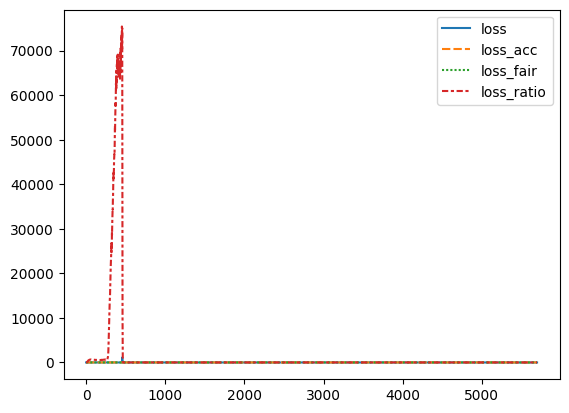

    -- lambda_fair=5, lambda_ratio=0.005
epoch 0 loss_acc 0.6951 loss_fair 2.0391 loss_ratio 585.5 DP_gap_test 0.073 EO_gap_test 0.2117 ACC_test 0.8211 proportion_changed 0.5373
epoch 30 loss_acc 0.7058 loss_fair 2.058 loss_ratio 1.5918 DP_gap_test 0.2769 EO_gap_test 0.6226 ACC_test 0.8045 proportion_changed 0.4164
epoch 60 loss_acc 0.7054 loss_fair 2.0633 loss_ratio 1.6184 DP_gap_test 0.2705 EO_gap_test 0.6118 ACC_test 0.8059 proportion_changed 0.4196
epoch 90 loss_acc 0.7007 loss_fair 2.0661 loss_ratio 1.7053 DP_gap_test 0.27 EO_gap_test 0.6092 ACC_test 0.8055 proportion_changed 0.4212
epoch 120 loss_acc 0.7024 loss_fair 2.0663 loss_ratio 1.8761 DP_gap_test 0.2586 EO_gap_test 0.6048 ACC_test 0.8084 proportion_changed 0.4267

Final DP gap: 0.2532721355882365
Final EO gap: 0.5848890586181612
Final Accuracy: 80.85853499196995
Final proportion changed: 0.42938998829517927


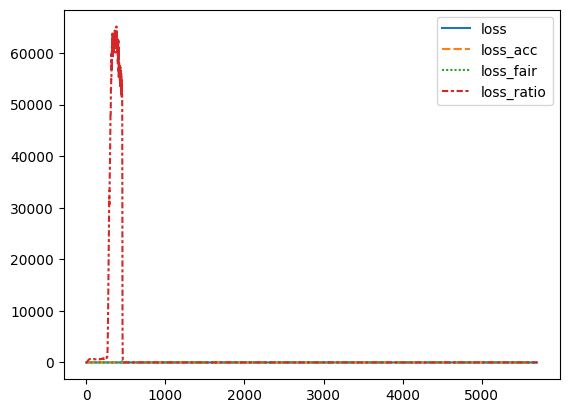

    -- lambda_fair=5, lambda_ratio=0.008
epoch 0 loss_acc 0.6963 loss_fair 2.0338 loss_ratio 475.8372 DP_gap_test 0.0735 EO_gap_test 0.2118 ACC_test 0.8207 proportion_changed 0.5373
epoch 30 loss_acc 0.7108 loss_fair 2.0563 loss_ratio 1.6286 DP_gap_test 0.2303 EO_gap_test 0.4763 ACC_test 0.7593 proportion_changed 0.3764
epoch 60 loss_acc 0.708 loss_fair 2.0601 loss_ratio 1.1042 DP_gap_test 0.3353 EO_gap_test 0.7253 ACC_test 0.7916 proportion_changed 0.3864
epoch 90 loss_acc 0.7119 loss_fair 2.0609 loss_ratio 1.1143 DP_gap_test 0.3377 EO_gap_test 0.7309 ACC_test 0.7901 proportion_changed 0.3839
epoch 120 loss_acc 0.7084 loss_fair 2.0571 loss_ratio 1.1095 DP_gap_test 0.3343 EO_gap_test 0.7253 ACC_test 0.7896 proportion_changed 0.3836

Final DP gap: 0.32880481418711344
Final EO gap: 0.717008308792128
Final Accuracy: 79.11370008438358
Final proportion changed: 0.3860004899692408


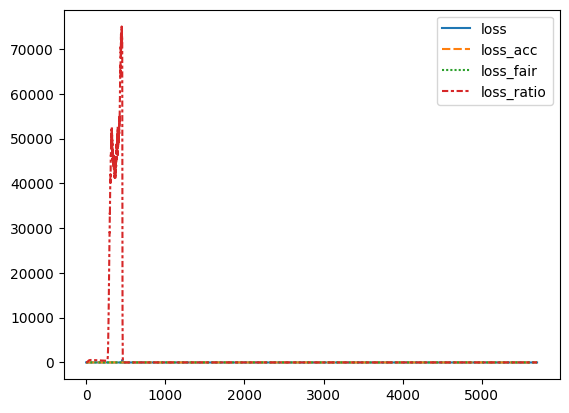

    -- lambda_fair=5, lambda_ratio=0.01
epoch 0 loss_acc 0.6957 loss_fair 2.0426 loss_ratio 596.0017 DP_gap_test 0.0713 EO_gap_test 0.2064 ACC_test 0.8206 proportion_changed 0.5383
epoch 30 loss_acc 0.715 loss_fair 2.0541 loss_ratio 0.9726 DP_gap_test 0.3478 EO_gap_test 0.7493 ACC_test 0.7861 proportion_changed 0.3693
epoch 60 loss_acc 0.7101 loss_fair 2.0577 loss_ratio 0.937 DP_gap_test 0.3335 EO_gap_test 0.7256 ACC_test 0.788 proportion_changed 0.375
epoch 90 loss_acc 0.7092 loss_fair 2.056 loss_ratio 0.9709 DP_gap_test 0.3325 EO_gap_test 0.7228 ACC_test 0.7884 proportion_changed 0.3797
epoch 120 loss_acc 0.7075 loss_fair 2.0556 loss_ratio 1.0052 DP_gap_test 0.3341 EO_gap_test 0.7288 ACC_test 0.788 proportion_changed 0.3784

Final DP gap: 0.35013746049618283
Final EO gap: 0.7604512555202223
Final Accuracy: 78.28075237498979
Final proportion changed: 0.3677355254920108


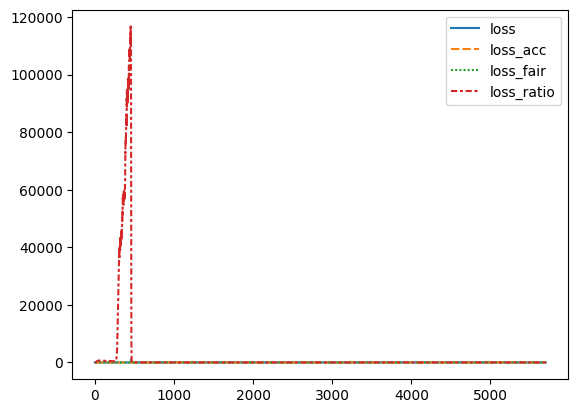

    -- lambda_fair=5, lambda_ratio=0.015
epoch 0 loss_acc 0.6926 loss_fair 2.0429 loss_ratio 514.8976 DP_gap_test 0.0717 EO_gap_test 0.2075 ACC_test 0.8207 proportion_changed 0.538
epoch 30 loss_acc 0.7138 loss_fair 2.0653 loss_ratio 0.5909 DP_gap_test 0.3973 EO_gap_test 0.8163 ACC_test 0.7629 proportion_changed 0.325
epoch 60 loss_acc 0.7122 loss_fair 2.0578 loss_ratio 0.6349 DP_gap_test 0.3878 EO_gap_test 0.8169 ACC_test 0.7699 proportion_changed 0.3377
epoch 90 loss_acc 0.7119 loss_fair 2.0701 loss_ratio 0.5823 DP_gap_test 0.3775 EO_gap_test 0.797 ACC_test 0.7755 proportion_changed 0.3484
epoch 120 loss_acc 0.7128 loss_fair 2.0606 loss_ratio 0.6411 DP_gap_test 0.3767 EO_gap_test 0.7922 ACC_test 0.7775 proportion_changed 0.3512

Final DP gap: 0.37271935812863144
Final EO gap: 0.7819221611490763
Final Accuracy: 77.886054930996
Final proportion changed: 0.3552140893377249


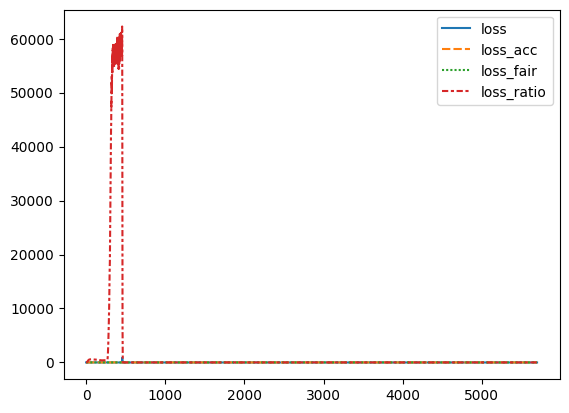


=== Baseline (원본 GLM, f) ===
F1: 0.4137619812631997
Precision: 0.27678894872847587
Recall: 0.8191109205260149
PR-AUC: 0.45895828856980675
ROC-AUC: 0.749096551524137
DP_gap: 0.6723713206808999
EO_gap: 1.1368984156876834

  [age_gender] Grid search 결과 (val, accuracy 높은 순 상위 5개):
   lambda_fair  lambda_ratio  n_classes  DP_gap_val  EO_gap_val  accuracy_val  \
4            4         0.005          8    0.232893    0.571862      0.815935   
0            3         0.005          8    0.236630    0.544232      0.810151   
8            5         0.005          8    0.253272    0.584889      0.808585   
1            3         0.008          8    0.295604    0.643580      0.798555   
5            4         0.008          8    0.289582    0.619642      0.797534   

     f1_val  precision_val  recall_val  pr_auc_val  roc_auc_val  \
4  0.417220       0.525396    0.345983    0.448873     0.752439   
0  0.409966       0.502228    0.346341    0.429463     0.750041   
8  0.412040       0.496374    0.3

In [ ]:
import itertools
import pandas as pd

lamb_fair_grid = [3, 4, 5]
lamb_ratio_grid = [0.005, 0.008, 0.01, 0.015]

attr = 'age_gender'
print(f"\n{'='*60}\nAttribute: {attr}\n{'='*60}")

S_train_cat, S_val_cat, n_classes = get_sensitive_attribute(
    data, attr, sens_config, idx_train, idx_val
)

all_cats = pd.concat([S_train_cat, S_val_cat]).astype('category')
S_train_codes = all_cats.cat.codes[:len(S_train_cat)].values
S_val_codes = all_cats.cat.codes[len(S_train_cat):].values

print(f"  -> {n_classes} categories: {list(all_cats.cat.categories)}")

input_dim = X_train.shape[1]
attr_grid_results = []

for lamb_fair, lamb_ratio in itertools.product(lamb_fair_grid, lamb_ratio_grid):
    print(f"    -- lambda_fair={lamb_fair}, lambda_ratio={lamb_ratio}")

    NN_r = make_NN_r(input_dim, hidden=(64, 32))

    rbmd_model = rbmd_debiasing(
        learning_rate=0.01,
        batch_size=2048,
        lamb_fair=lamb_fair,
        lamb_ratio=lamb_ratio,
        num_epochs=150,
        NN_r=NN_r,
        n_classes=n_classes,
        GPU='cuda:0',
        threshold=THRESHOLD
    )

    rbmd_model.train(
        X_train, y_train, S_train_codes,
        y_hat=proba_train,
        X_test=X_val, y_test=y_val, S_test=S_val_codes,
        y_hat_test=proba_val,
        plot_losses=True
    )

    val_probs = rbmd_model.predict_proba(X_val, proba_val)
    val_preds = rbmd_model.predict(X_val, proba_val)

    attr_grid_results.append({
        'lambda_fair': lamb_fair,
        'lambda_ratio': lamb_ratio,
        'n_classes': n_classes,
        'DP_gap_val': group_fairness_gap(val_preds, S_val_codes),
        'EO_gap_val': disparate_mistreatment_general(val_preds, y_val, S_val_codes),
        'accuracy_val': float(np.mean(val_preds == y_val)),
        'f1_val': f1_score(y_val, val_preds),
        'precision_val': precision_score(y_val, val_preds, zero_division=0),
        'recall_val': recall_score(y_val, val_preds, zero_division=0),
        'pr_auc_val': average_precision_score(y_val, val_probs),
        'roc_auc_val': roc_auc_score(y_val, val_probs),
        'proportion_changed_val': float(np.mean(val_preds != (proba_val > THRESHOLD))),
    })

grid_results = {}
grid_results[attr] = pd.DataFrame(attr_grid_results)

# baseline
baseline_preds = (proba_val > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) ===")
print("F1:", f1_score(y_val, baseline_preds))
print("Precision:", precision_score(y_val, baseline_preds, zero_division=0))
print("Recall:", recall_score(y_val, baseline_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_val, proba_val))
print("ROC-AUC:", roc_auc_score(y_val, proba_val))
print("DP_gap:", group_fairness_gap(baseline_preds, S_val_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds, y_val, S_val_codes))

# 튜닝 후 -- grid_results 직접 사용 (조합당 1행이므로 groupby 불필요)
print(f"\n  [{attr}] Grid search 결과 (val, accuracy 높은 순 상위 5개):")
print(grid_results[attr].sort_values('accuracy_val', ascending=False).head())

print(f"\n  [{attr}] Grid search 결과 (val, 변화 최소화 우선 상위 5개):")
print(grid_results[attr].sort_values('proportion_changed_val').head())

print(f"\n  [{attr}] Grid search 결과 (val, DP gap 낮은 순 상위 5개):")
print(grid_results[attr].sort_values('DP_gap_val').head())

In [ ]:
best_row = grid_results['age_gender'].sort_values('DP_gap_val').iloc[0]   # DP gap 최소 기준
best_lamb_fair = best_row['lambda_fair']
best_lamb_ratio = best_row['lambda_ratio']
print("선택된 조합:", best_lamb_fair, best_lamb_ratio)

선택된 조합: 5.0 0.005


- lamb_fair의 영향력 확인 위한 코드


Attribute: age_gender
  -> 8 categories: ['고령 F', '고령 M', '장년 F', '장년 M', '중년 F', '중년 M', '청년 F', '청년 M']
    -- lambda_fair=1, lambda_ratio=0.001
epoch 0 loss_acc 0.6952 loss_fair 2.0452 loss_ratio 615.4192 DP_gap_test 0.0717 EO_gap_test 0.2075 ACC_test 0.8207 proportion_changed 0.5381
epoch 30 loss_acc 0.698 loss_fair 2.0614 loss_ratio 4.6306 DP_gap_test 0.1564 EO_gap_test 0.4138 ACC_test 0.8253 proportion_changed 0.4863
epoch 60 loss_acc 0.6968 loss_fair 2.0612 loss_ratio 5.1058 DP_gap_test 0.1442 EO_gap_test 0.3869 ACC_test 0.8268 proportion_changed 0.4907
epoch 90 loss_acc 0.6916 loss_fair 2.0605 loss_ratio 5.0711 DP_gap_test 0.1372 EO_gap_test 0.3572 ACC_test 0.8232 proportion_changed 0.488
epoch 120 loss_acc 0.6906 loss_fair 2.0601 loss_ratio 5.6144 DP_gap_test 0.1438 EO_gap_test 0.3634 ACC_test 0.8224 proportion_changed 0.4878

Final DP gap: 0.14691241533741106
Final EO gap: 0.3705902797283556
Final Accuracy: 82.24269809728611
Final proportion changed: 0.48259248169420477


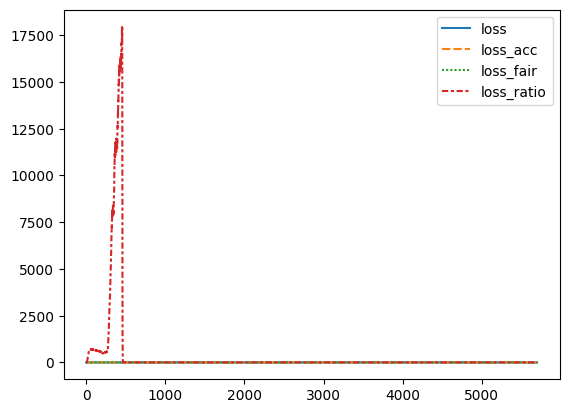

    -- lambda_fair=1, lambda_ratio=0.003
epoch 0 loss_acc 0.693 loss_fair 2.0462 loss_ratio 556.1547 DP_gap_test 0.071 EO_gap_test 0.2052 ACC_test 0.8205 proportion_changed 0.5382
epoch 30 loss_acc 0.7013 loss_fair 2.0644 loss_ratio 2.3107 DP_gap_test 0.224 EO_gap_test 0.5331 ACC_test 0.8166 proportion_changed 0.4503
epoch 60 loss_acc 0.7031 loss_fair 2.0672 loss_ratio 2.301 DP_gap_test 0.2142 EO_gap_test 0.5274 ACC_test 0.8183 proportion_changed 0.452
epoch 90 loss_acc 0.6998 loss_fair 2.0626 loss_ratio 2.3405 DP_gap_test 0.2148 EO_gap_test 0.51 ACC_test 0.817 proportion_changed 0.4502
epoch 120 loss_acc 0.6984 loss_fair 2.0603 loss_ratio 2.3985 DP_gap_test 0.2213 EO_gap_test 0.5252 ACC_test 0.8167 proportion_changed 0.4462

Final DP gap: 0.23567914115560215
Final EO gap: 0.5618550956056634
Final Accuracy: 81.02185807224325
Final proportion changed: 0.44297302447124154


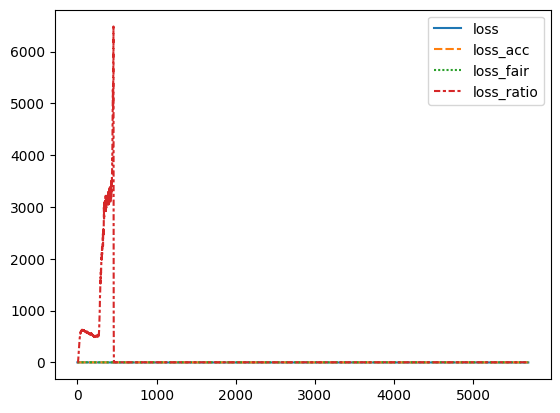

    -- lambda_fair=1, lambda_ratio=0.005
epoch 0 loss_acc 0.6934 loss_fair 2.0348 loss_ratio 639.1099 DP_gap_test 0.0728 EO_gap_test 0.2105 ACC_test 0.8209 proportion_changed 0.5376
epoch 30 loss_acc 0.7035 loss_fair 2.0592 loss_ratio 1.5698 DP_gap_test 0.2595 EO_gap_test 0.5844 ACC_test 0.8054 proportion_changed 0.4163
epoch 60 loss_acc 0.701 loss_fair 2.0636 loss_ratio 1.7951 DP_gap_test 0.2234 EO_gap_test 0.5284 ACC_test 0.8086 proportion_changed 0.4404
epoch 90 loss_acc 0.7019 loss_fair 2.06 loss_ratio 1.6312 DP_gap_test 0.2347 EO_gap_test 0.552 ACC_test 0.8099 proportion_changed 0.4382
epoch 120 loss_acc 0.6985 loss_fair 2.0574 loss_ratio 1.6556 DP_gap_test 0.2341 EO_gap_test 0.5543 ACC_test 0.8093 proportion_changed 0.4401

Final DP gap: 0.23305328274839493
Final EO gap: 0.5425740592593344
Final Accuracy: 80.79592781119852
Final proportion changed: 0.4364945422870675


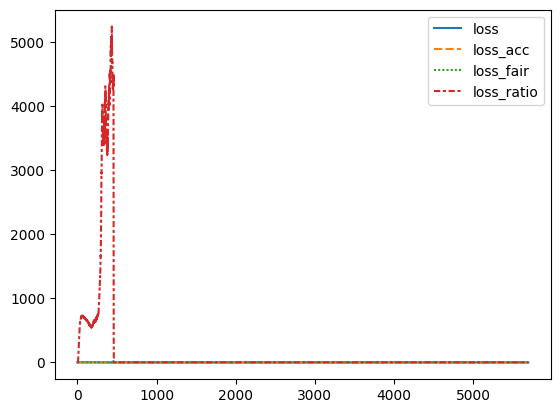

    -- lambda_fair=1, lambda_ratio=0.008
epoch 0 loss_acc 0.6937 loss_fair 2.0368 loss_ratio 582.0184 DP_gap_test 0.0708 EO_gap_test 0.2045 ACC_test 0.8205 proportion_changed 0.5385
epoch 30 loss_acc 0.7105 loss_fair 2.0555 loss_ratio 1.1921 DP_gap_test 0.239 EO_gap_test 0.4793 ACC_test 0.7844 proportion_changed 0.3895
epoch 60 loss_acc 0.7053 loss_fair 2.0636 loss_ratio 1.042 DP_gap_test 0.2999 EO_gap_test 0.655 ACC_test 0.7914 proportion_changed 0.3868
epoch 90 loss_acc 0.7015 loss_fair 2.0655 loss_ratio 1.1482 DP_gap_test 0.2947 EO_gap_test 0.6567 ACC_test 0.7961 proportion_changed 0.3983
epoch 120 loss_acc 0.7073 loss_fair 2.0662 loss_ratio 1.1649 DP_gap_test 0.2777 EO_gap_test 0.6259 ACC_test 0.8024 proportion_changed 0.4085

Final DP gap: 0.26341619611859374
Final EO gap: 0.5967302403276408
Final Accuracy: 80.59857908920162
Final proportion changed: 0.41778043933908593


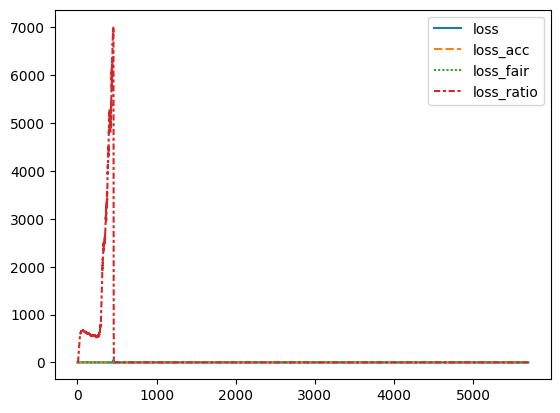

    -- lambda_fair=3, lambda_ratio=0.001
epoch 0 loss_acc 0.6959 loss_fair 2.0457 loss_ratio 545.4951 DP_gap_test 0.0717 EO_gap_test 0.2075 ACC_test 0.8207 proportion_changed 0.5379
epoch 30 loss_acc 0.7073 loss_fair 2.064 loss_ratio 6.162 DP_gap_test 0.0477 EO_gap_test 0.1651 ACC_test 0.7878 proportion_changed 0.4626
epoch 60 loss_acc 0.7006 loss_fair 2.0572 loss_ratio 4.9814 DP_gap_test 0.1419 EO_gap_test 0.3804 ACC_test 0.827 proportion_changed 0.4846
epoch 90 loss_acc 0.6986 loss_fair 2.0615 loss_ratio 4.6982 DP_gap_test 0.1475 EO_gap_test 0.3963 ACC_test 0.8273 proportion_changed 0.4847
epoch 120 loss_acc 0.6976 loss_fair 2.0637 loss_ratio 4.6861 DP_gap_test 0.1534 EO_gap_test 0.3985 ACC_test 0.8261 proportion_changed 0.4849

Final DP gap: 0.16468019242046117
Final EO gap: 0.4214777902668043
Final Accuracy: 82.37743963851159
Final proportion changed: 0.4778425021095898


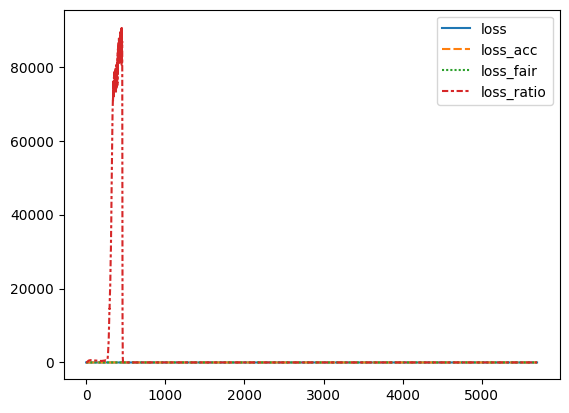

    -- lambda_fair=3, lambda_ratio=0.003
epoch 0 loss_acc 0.697 loss_fair 2.0452 loss_ratio 405.5495 DP_gap_test 0.0738 EO_gap_test 0.2125 ACC_test 0.8207 proportion_changed 0.5371
epoch 30 loss_acc 0.7034 loss_fair 2.0687 loss_ratio 2.3761 DP_gap_test 0.2325 EO_gap_test 0.5638 ACC_test 0.8117 proportion_changed 0.4382
epoch 60 loss_acc 0.7008 loss_fair 2.0594 loss_ratio 2.3184 DP_gap_test 0.2185 EO_gap_test 0.5296 ACC_test 0.815 proportion_changed 0.4488
epoch 90 loss_acc 0.6995 loss_fair 2.0685 loss_ratio 2.5221 DP_gap_test 0.2073 EO_gap_test 0.5026 ACC_test 0.8184 proportion_changed 0.4557
epoch 120 loss_acc 0.6999 loss_fair 2.0605 loss_ratio 2.4777 DP_gap_test 0.2054 EO_gap_test 0.4891 ACC_test 0.819 proportion_changed 0.4552

Final DP gap: 0.21205442397873603
Final EO gap: 0.5039677276318252
Final Accuracy: 81.88610937202276
Final proportion changed: 0.452922122111223


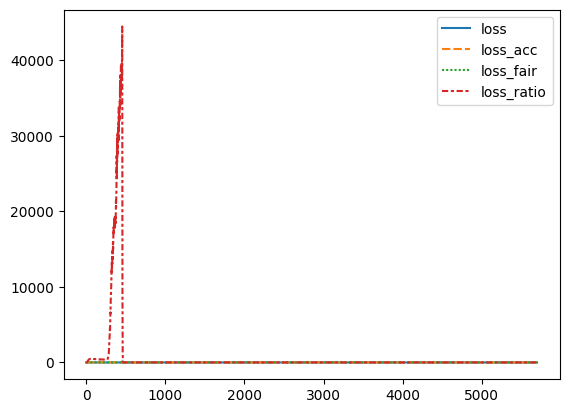

    -- lambda_fair=3, lambda_ratio=0.005
epoch 0 loss_acc 0.6944 loss_fair 2.0492 loss_ratio 565.7344 DP_gap_test 0.0715 EO_gap_test 0.2073 ACC_test 0.8207 proportion_changed 0.5379
epoch 30 loss_acc 0.7046 loss_fair 2.0573 loss_ratio 1.6809 DP_gap_test 0.2434 EO_gap_test 0.5587 ACC_test 0.805 proportion_changed 0.4182
epoch 60 loss_acc 0.7044 loss_fair 2.0538 loss_ratio 1.592 DP_gap_test 0.2663 EO_gap_test 0.6132 ACC_test 0.8048 proportion_changed 0.4192
epoch 90 loss_acc 0.7034 loss_fair 2.0617 loss_ratio 1.6358 DP_gap_test 0.2691 EO_gap_test 0.6216 ACC_test 0.806 proportion_changed 0.4214
epoch 120 loss_acc 0.7049 loss_fair 2.0598 loss_ratio 1.5686 DP_gap_test 0.2848 EO_gap_test 0.6603 ACC_test 0.8036 proportion_changed 0.4174

Final DP gap: 0.2640076801607921
Final EO gap: 0.6097613347057446
Final Accuracy: 80.68160165500721
Final proportion changed: 0.42277540354411086


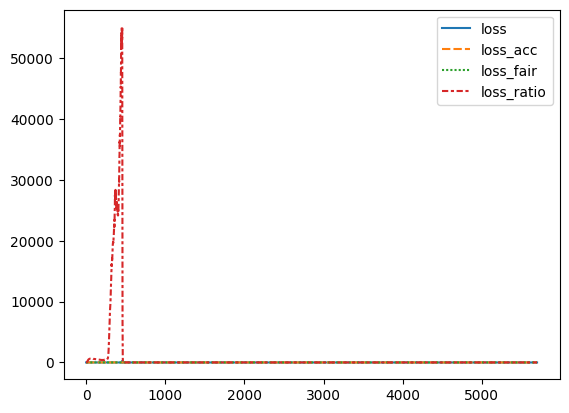

    -- lambda_fair=3, lambda_ratio=0.008
epoch 0 loss_acc 0.6941 loss_fair 2.0449 loss_ratio 600.4621 DP_gap_test 0.0739 EO_gap_test 0.215 ACC_test 0.8213 proportion_changed 0.537
epoch 30 loss_acc 0.7097 loss_fair 2.0588 loss_ratio 1.081 DP_gap_test 0.3221 EO_gap_test 0.6987 ACC_test 0.7893 proportion_changed 0.3795
epoch 60 loss_acc 0.7071 loss_fair 2.0612 loss_ratio 1.1019 DP_gap_test 0.3384 EO_gap_test 0.7428 ACC_test 0.7883 proportion_changed 0.3797
epoch 90 loss_acc 0.7088 loss_fair 2.0617 loss_ratio 1.1529 DP_gap_test 0.2974 EO_gap_test 0.6541 ACC_test 0.7979 proportion_changed 0.4017
epoch 120 loss_acc 0.7085 loss_fair 2.0601 loss_ratio 1.1638 DP_gap_test 0.2974 EO_gap_test 0.647 ACC_test 0.7975 proportion_changed 0.3998

Final DP gap: 0.30005147169643814
Final EO gap: 0.6517845732457738
Final Accuracy: 79.49750932302582
Final proportion changed: 0.3940305414160111


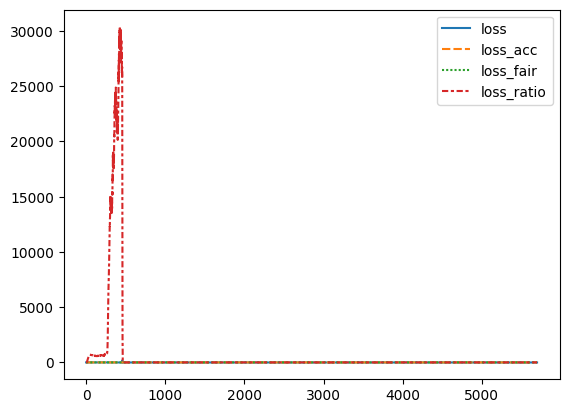

    -- lambda_fair=5, lambda_ratio=0.001
epoch 0 loss_acc 0.6926 loss_fair 2.0522 loss_ratio 503.2051 DP_gap_test 0.0757 EO_gap_test 0.2198 ACC_test 0.8216 proportion_changed 0.5365
epoch 30 loss_acc 0.6994 loss_fair 2.0663 loss_ratio 4.8866 DP_gap_test 0.1732 EO_gap_test 0.4541 ACC_test 0.8231 proportion_changed 0.4837
epoch 60 loss_acc 0.6996 loss_fair 2.0543 loss_ratio 4.5573 DP_gap_test 0.1566 EO_gap_test 0.4162 ACC_test 0.8248 proportion_changed 0.4863
epoch 90 loss_acc 0.6967 loss_fair 2.0616 loss_ratio 4.6167 DP_gap_test 0.1505 EO_gap_test 0.3993 ACC_test 0.826 proportion_changed 0.487
epoch 120 loss_acc 0.6955 loss_fair 2.0629 loss_ratio 4.6341 DP_gap_test 0.1419 EO_gap_test 0.3733 ACC_test 0.8237 proportion_changed 0.4857

Final DP gap: 0.14142133833753587
Final EO gap: 0.36385277421966655
Final Accuracy: 82.50945912839917
Final proportion changed: 0.48477012276451537


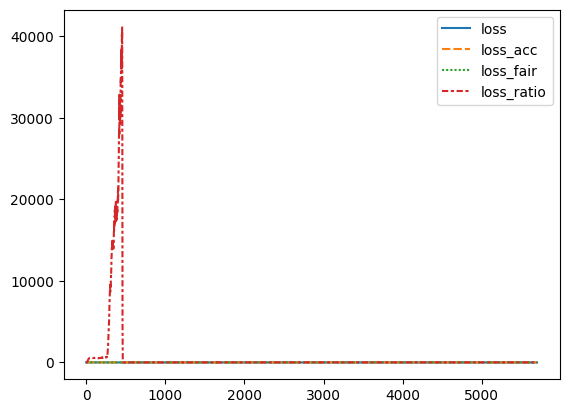

    -- lambda_fair=5, lambda_ratio=0.003
epoch 0 loss_acc 0.6981 loss_fair 2.0456 loss_ratio 611.7754 DP_gap_test 0.0709 EO_gap_test 0.205 ACC_test 0.8204 proportion_changed 0.5386
epoch 30 loss_acc 0.7094 loss_fair 2.0637 loss_ratio 2.1339 DP_gap_test 0.2267 EO_gap_test 0.5188 ACC_test 0.7951 proportion_changed 0.4029
epoch 60 loss_acc 0.7027 loss_fair 2.0605 loss_ratio 2.4297 DP_gap_test 0.2367 EO_gap_test 0.5686 ACC_test 0.8114 proportion_changed 0.4419
epoch 90 loss_acc 0.6999 loss_fair 2.0591 loss_ratio 2.4325 DP_gap_test 0.2557 EO_gap_test 0.5948 ACC_test 0.806 proportion_changed 0.4337
epoch 120 loss_acc 0.6987 loss_fair 2.0627 loss_ratio 2.4897 DP_gap_test 0.2271 EO_gap_test 0.5521 ACC_test 0.8143 proportion_changed 0.4451

Final DP gap: 0.2218351799710586
Final EO gap: 0.5464495563386409
Final Accuracy: 81.71870321474263
Final proportion changed: 0.45092141437787514


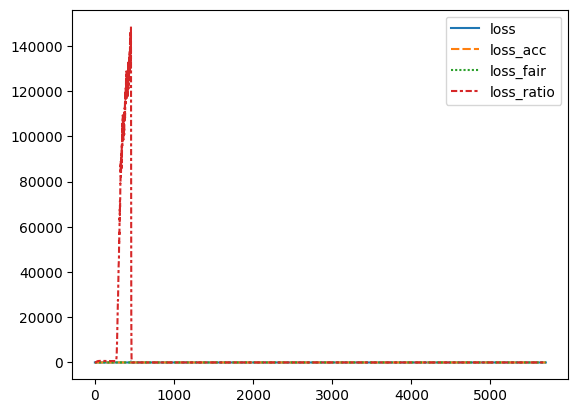

    -- lambda_fair=5, lambda_ratio=0.005
epoch 0 loss_acc 0.6941 loss_fair 2.0411 loss_ratio 538.8714 DP_gap_test 0.072 EO_gap_test 0.2089 ACC_test 0.8208 proportion_changed 0.5378
epoch 30 loss_acc 0.704 loss_fair 2.0626 loss_ratio 1.6039 DP_gap_test 0.2711 EO_gap_test 0.6104 ACC_test 0.8051 proportion_changed 0.4184
epoch 60 loss_acc 0.7064 loss_fair 2.0573 loss_ratio 1.5329 DP_gap_test 0.2679 EO_gap_test 0.6187 ACC_test 0.8075 proportion_changed 0.4229
epoch 90 loss_acc 0.7007 loss_fair 2.0617 loss_ratio 1.8091 DP_gap_test 0.2398 EO_gap_test 0.5684 ACC_test 0.8123 proportion_changed 0.4346
epoch 120 loss_acc 0.7047 loss_fair 2.0569 loss_ratio 1.6267 DP_gap_test 0.2329 EO_gap_test 0.5551 ACC_test 0.8137 proportion_changed 0.437

Final DP gap: 0.22381658390830378
Final EO gap: 0.5294270895069648
Final Accuracy: 81.43288782426437
Final proportion changed: 0.4439257424395024


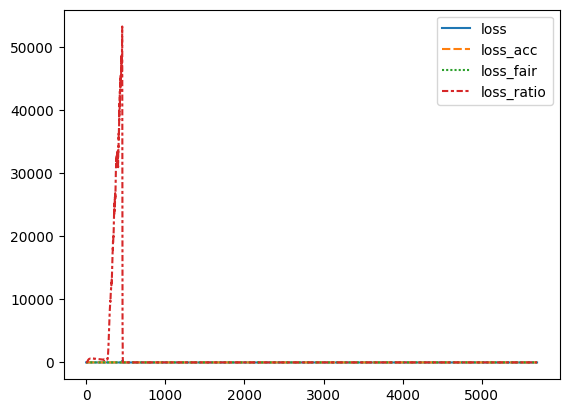

    -- lambda_fair=5, lambda_ratio=0.008
epoch 0 loss_acc 0.6926 loss_fair 2.0389 loss_ratio 506.7868 DP_gap_test 0.0743 EO_gap_test 0.2158 ACC_test 0.8213 proportion_changed 0.537
epoch 30 loss_acc 0.7551 loss_fair 2.0594 loss_ratio 0.1997 DP_gap_test 0.0728 EO_gap_test 0.1608 ACC_test 0.4423 proportion_changed 0.3099
epoch 60 loss_acc 0.71 loss_fair 2.0628 loss_ratio 1.166 DP_gap_test 0.2572 EO_gap_test 0.5248 ACC_test 0.796 proportion_changed 0.395
epoch 90 loss_acc 0.709 loss_fair 2.0623 loss_ratio 1.098 DP_gap_test 0.2955 EO_gap_test 0.6226 ACC_test 0.7949 proportion_changed 0.3926
epoch 120 loss_acc 0.7101 loss_fair 2.0563 loss_ratio 1.0836 DP_gap_test 0.3083 EO_gap_test 0.6646 ACC_test 0.7939 proportion_changed 0.3905

Final DP gap: 0.3005951024226851
Final EO gap: 0.6463575582313041
Final Accuracy: 79.1504477774451
Final proportion changed: 0.3952418542613714


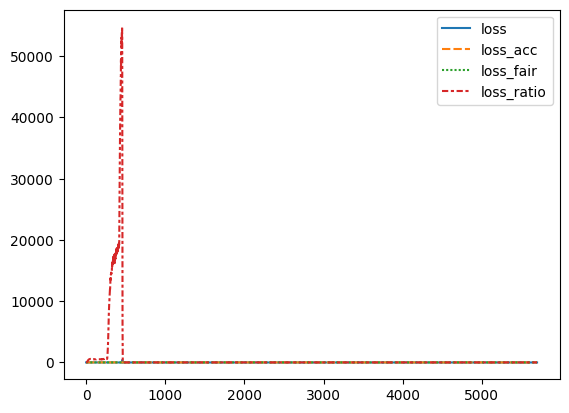

    -- lambda_fair=10, lambda_ratio=0.001
epoch 0 loss_acc 0.6927 loss_fair 2.0376 loss_ratio 564.5954 DP_gap_test 0.071 EO_gap_test 0.2052 ACC_test 0.8206 proportion_changed 0.5381
epoch 30 loss_acc 0.6984 loss_fair 2.0568 loss_ratio 4.813 DP_gap_test 0.148 EO_gap_test 0.3987 ACC_test 0.8271 proportion_changed 0.4858
epoch 60 loss_acc 0.6973 loss_fair 2.0583 loss_ratio 4.8279 DP_gap_test 0.1499 EO_gap_test 0.3907 ACC_test 0.8262 proportion_changed 0.4858
epoch 90 loss_acc 0.6957 loss_fair 2.0631 loss_ratio 4.8025 DP_gap_test 0.1498 EO_gap_test 0.3942 ACC_test 0.8266 proportion_changed 0.4878
epoch 120 loss_acc 0.6953 loss_fair 2.0553 loss_ratio 4.9866 DP_gap_test 0.1435 EO_gap_test 0.3773 ACC_test 0.8265 proportion_changed 0.4886

Final DP gap: 0.14042807781300715
Final EO gap: 0.3716183868029874
Final Accuracy: 82.48223861502028
Final proportion changed: 0.48781882026295015


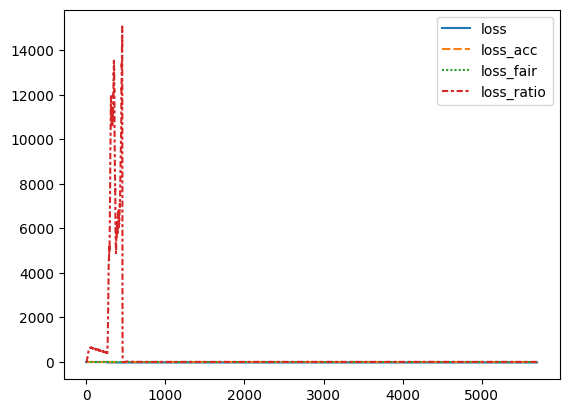

    -- lambda_fair=10, lambda_ratio=0.003
epoch 0 loss_acc 0.6934 loss_fair 2.0422 loss_ratio 459.347 DP_gap_test 0.0745 EO_gap_test 0.2156 ACC_test 0.8212 proportion_changed 0.5367
epoch 30 loss_acc 0.7026 loss_fair 2.0562 loss_ratio 2.3162 DP_gap_test 0.2168 EO_gap_test 0.523 ACC_test 0.8151 proportion_changed 0.4451
epoch 60 loss_acc 0.7021 loss_fair 2.0634 loss_ratio 2.4602 DP_gap_test 0.2222 EO_gap_test 0.5342 ACC_test 0.8163 proportion_changed 0.4504
epoch 90 loss_acc 0.696 loss_fair 2.0591 loss_ratio 2.3963 DP_gap_test 0.2076 EO_gap_test 0.4997 ACC_test 0.8146 proportion_changed 0.4524
epoch 120 loss_acc 0.6997 loss_fair 2.0564 loss_ratio 2.6454 DP_gap_test 0.1971 EO_gap_test 0.4929 ACC_test 0.8172 proportion_changed 0.4572

Final DP gap: 0.1878055953698621
Final EO gap: 0.4651665370606435
Final Accuracy: 81.52679859542151
Final proportion changed: 0.4600538966164902


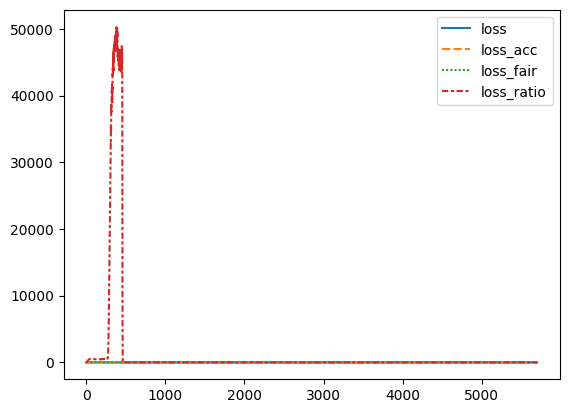

    -- lambda_fair=10, lambda_ratio=0.005
epoch 0 loss_acc 0.6956 loss_fair 2.0451 loss_ratio 467.8405 DP_gap_test 0.0738 EO_gap_test 0.214 ACC_test 0.8211 proportion_changed 0.537
epoch 30 loss_acc 0.7051 loss_fair 2.0588 loss_ratio 1.5127 DP_gap_test 0.2885 EO_gap_test 0.6546 ACC_test 0.8007 proportion_changed 0.4075
epoch 60 loss_acc 0.7076 loss_fair 2.0567 loss_ratio 1.5563 DP_gap_test 0.2822 EO_gap_test 0.6454 ACC_test 0.8027 proportion_changed 0.4129
epoch 90 loss_acc 0.703 loss_fair 2.0604 loss_ratio 1.5306 DP_gap_test 0.2873 EO_gap_test 0.6585 ACC_test 0.8028 proportion_changed 0.412
epoch 120 loss_acc 0.703 loss_fair 2.0599 loss_ratio 1.5605 DP_gap_test 0.2835 EO_gap_test 0.6464 ACC_test 0.8031 proportion_changed 0.4133

Final DP gap: 0.2799761788044507
Final EO gap: 0.6316599193609667
Final Accuracy: 80.33454010942647
Final proportion changed: 0.4147317418406511


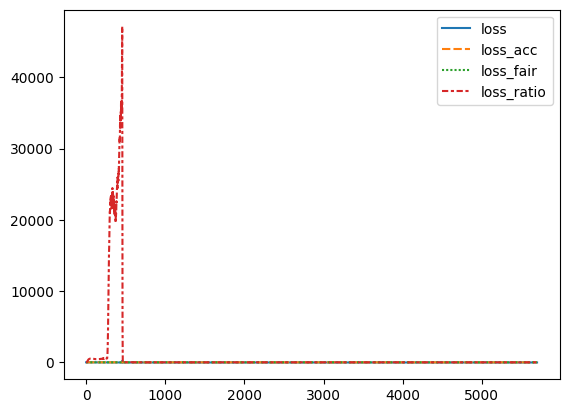

    -- lambda_fair=10, lambda_ratio=0.008
epoch 0 loss_acc 0.6917 loss_fair 2.0426 loss_ratio 560.368 DP_gap_test 0.0717 EO_gap_test 0.2075 ACC_test 0.8206 proportion_changed 0.5381
epoch 30 loss_acc 0.7071 loss_fair 2.0615 loss_ratio 1.0267 DP_gap_test 0.3297 EO_gap_test 0.7173 ACC_test 0.7921 proportion_changed 0.3862
epoch 60 loss_acc 0.7058 loss_fair 2.0584 loss_ratio 1.2151 DP_gap_test 0.3225 EO_gap_test 0.7138 ACC_test 0.7924 proportion_changed 0.392
epoch 90 loss_acc 0.7046 loss_fair 2.0591 loss_ratio 1.1317 DP_gap_test 0.3196 EO_gap_test 0.7032 ACC_test 0.7929 proportion_changed 0.3918
epoch 120 loss_acc 0.7041 loss_fair 2.0603 loss_ratio 1.1683 DP_gap_test 0.3178 EO_gap_test 0.6899 ACC_test 0.7927 proportion_changed 0.3901

Final DP gap: 0.3132491791013784
Final EO gap: 0.6863656128150643
Final Accuracy: 79.46212265563328
Final proportion changed: 0.3946838337371043


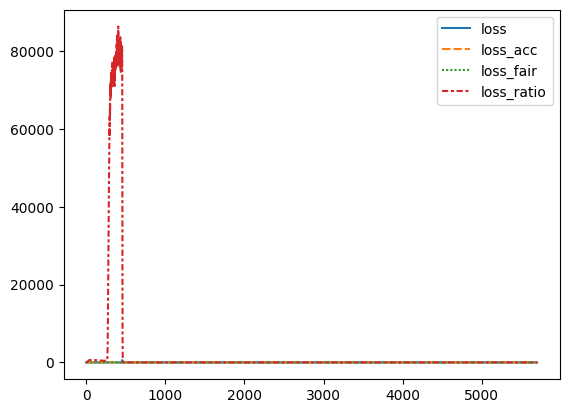


=== Baseline (원본 GLM, f) ===
F1: 0.4137619812631997
Precision: 0.27678894872847587
Recall: 0.8191109205260149
PR-AUC: 0.45895828856980675
ROC-AUC: 0.749096551524137
DP_gap: 0.6723713206808999
EO_gap: 1.1368984156876834

  [age_gender] Grid search 결과 (val, accuracy 높은 순 상위 5개):
    lambda_fair  lambda_ratio  n_classes  DP_gap_val  EO_gap_val  \
8             5         0.001          8    0.141421    0.363853   
12           10         0.001          8    0.140428    0.371618   
4             3         0.001          8    0.164680    0.421478   
0             1         0.001          8    0.146912    0.370590   
5             3         0.003          8    0.212054    0.503968   

    accuracy_val    f1_val  precision_val  recall_val  pr_auc_val  \
8       0.825095  0.350730       0.598345    0.248070    0.436986   
12      0.824822  0.344019       0.599574    0.241209    0.429764   
4       0.823774  0.362670       0.582543    0.263293    0.444411   
0       0.822427  0.346899       0.5

In [ ]:
import itertools
import pandas as pd

lamb_fair_grid = [1, 3, 5, 10]
lamb_ratio_grid = [0.001, 0.003, 0.005, 0.008]

attr = 'age_gender'
print(f"\n{'='*60}\nAttribute: {attr}\n{'='*60}")

S_train_cat, S_val_cat, n_classes = get_sensitive_attribute(
    data, attr, sens_config, idx_train, idx_val
)

all_cats = pd.concat([S_train_cat, S_val_cat]).astype('category')
S_train_codes = all_cats.cat.codes[:len(S_train_cat)].values
S_val_codes = all_cats.cat.codes[len(S_train_cat):].values

print(f"  -> {n_classes} categories: {list(all_cats.cat.categories)}")

input_dim = X_train.shape[1]
attr_grid_results = []

for lamb_fair, lamb_ratio in itertools.product(lamb_fair_grid, lamb_ratio_grid):
    print(f"    -- lambda_fair={lamb_fair}, lambda_ratio={lamb_ratio}")

    NN_r = make_NN_r(input_dim, hidden=(64, 32))

    rbmd_model = rbmd_debiasing(
        learning_rate=0.01,
        batch_size=2048,
        lamb_fair=lamb_fair,
        lamb_ratio=lamb_ratio,
        num_epochs=150,
        NN_r=NN_r,
        n_classes=n_classes,
        GPU='cuda:0',
        threshold=THRESHOLD
    )

    rbmd_model.train(
        X_train, y_train, S_train_codes,
        y_hat=proba_train,
        X_test=X_val, y_test=y_val, S_test=S_val_codes,
        y_hat_test=proba_val,
        plot_losses=True
    )

    val_probs = rbmd_model.predict_proba(X_val, proba_val)
    val_preds = rbmd_model.predict(X_val, proba_val)

    attr_grid_results.append({
        'lambda_fair': lamb_fair,
        'lambda_ratio': lamb_ratio,
        'n_classes': n_classes,
        'DP_gap_val': group_fairness_gap(val_preds, S_val_codes),
        'EO_gap_val': disparate_mistreatment_general(val_preds, y_val, S_val_codes),
        'accuracy_val': float(np.mean(val_preds == y_val)),
        'f1_val': f1_score(y_val, val_preds),
        'precision_val': precision_score(y_val, val_preds, zero_division=0),
        'recall_val': recall_score(y_val, val_preds, zero_division=0),
        'pr_auc_val': average_precision_score(y_val, val_probs),
        'roc_auc_val': roc_auc_score(y_val, val_probs),
        'proportion_changed_val': float(np.mean(val_preds != (proba_val > THRESHOLD))),
    })

grid_results = {}
grid_results[attr] = pd.DataFrame(attr_grid_results)

# baseline
baseline_preds = (proba_val > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) ===")
print("F1:", f1_score(y_val, baseline_preds))
print("Precision:", precision_score(y_val, baseline_preds, zero_division=0))
print("Recall:", recall_score(y_val, baseline_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_val, proba_val))
print("ROC-AUC:", roc_auc_score(y_val, proba_val))
print("DP_gap:", group_fairness_gap(baseline_preds, S_val_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds, y_val, S_val_codes))

# 튜닝 후 -- grid_results 직접 사용 (조합당 1행이므로 groupby 불필요)
print(f"\n  [{attr}] Grid search 결과 (val, accuracy 높은 순 상위 5개):")
print(grid_results[attr].sort_values('accuracy_val', ascending=False).head())

print(f"\n  [{attr}] Grid search 결과 (val, 변화 최소화 우선 상위 5개):")
print(grid_results[attr].sort_values('proportion_changed_val').head())

print(f"\n  [{attr}] Grid search 결과 (val, DP gap 낮은 순 상위 5개):")
print(grid_results[attr].sort_values('DP_gap_val').head())

- lambda_fair_grid의 경우 영향 미미함. 따라서 상위권에 자주 위치하는 5로 값 고정


Attribute: age_gender
  -> 8 categories: ['고령 F', '고령 M', '장년 F', '장년 M', '중년 F', '중년 M', '청년 F', '청년 M']
    -- lambda_fair=5, lambda_ratio=0.0001
epoch 0 loss_acc 0.6959 loss_fair 2.0412 loss_ratio 521.2177 DP_gap_test 0.0734 EO_gap_test 0.2134 ACC_test 0.8212 proportion_changed 0.5372
epoch 30 loss_acc 0.6956 loss_fair 2.0495 loss_ratio 13.7661 DP_gap_test 0.1125 EO_gap_test 0.3144 ACC_test 0.8293 proportion_changed 0.511
epoch 60 loss_acc 0.6894 loss_fair 2.0614 loss_ratio 19.4239 DP_gap_test 0.1202 EO_gap_test 0.3381 ACC_test 0.8239 proportion_changed 0.5055
epoch 90 loss_acc 0.6882 loss_fair 2.0617 loss_ratio 17.457 DP_gap_test 0.1144 EO_gap_test 0.3045 ACC_test 0.8253 proportion_changed 0.5025
epoch 120 loss_acc 0.6887 loss_fair 2.059 loss_ratio 24.1456 DP_gap_test 0.1207 EO_gap_test 0.3063 ACC_test 0.8223 proportion_changed 0.5006

Final DP gap: 0.12453311165006503
Final EO gap: 0.3233002017900065
Final Accuracy: 81.94463347578736
Final proportion changed: 0.500680512834472


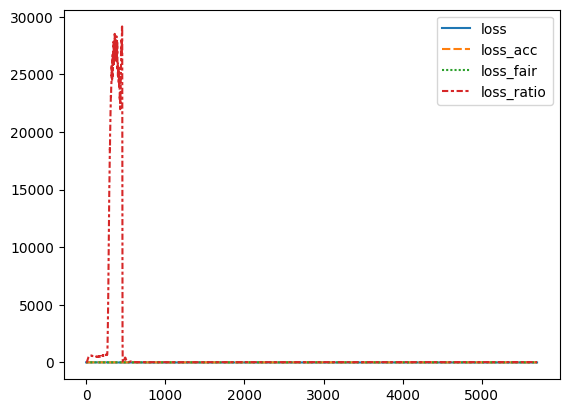

    -- lambda_fair=5, lambda_ratio=0.0003
epoch 0 loss_acc 0.6959 loss_fair 2.0408 loss_ratio 577.0126 DP_gap_test 0.0737 EO_gap_test 0.2138 ACC_test 0.8212 proportion_changed 0.5372
epoch 30 loss_acc 0.6957 loss_fair 2.0568 loss_ratio 9.8053 DP_gap_test 0.1215 EO_gap_test 0.3355 ACC_test 0.8278 proportion_changed 0.5038
epoch 60 loss_acc 0.6952 loss_fair 2.0646 loss_ratio 9.4477 DP_gap_test 0.1275 EO_gap_test 0.3439 ACC_test 0.8273 proportion_changed 0.5002
epoch 90 loss_acc 0.6923 loss_fair 2.067 loss_ratio 9.9538 DP_gap_test 0.1278 EO_gap_test 0.3372 ACC_test 0.8266 proportion_changed 0.497
epoch 120 loss_acc 0.6881 loss_fair 2.0594 loss_ratio 11.0628 DP_gap_test 0.1256 EO_gap_test 0.33 ACC_test 0.8268 proportion_changed 0.4987

Final DP gap: 0.13410061304767618
Final EO gap: 0.34658480861072455
Final Accuracy: 82.59792579688053
Final proportion changed: 0.4926232408743229


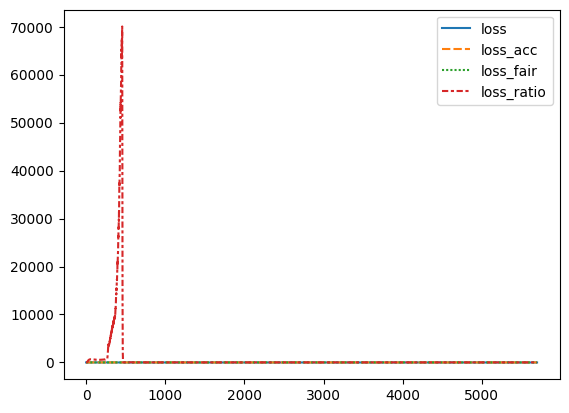

    -- lambda_fair=5, lambda_ratio=0.0005
epoch 0 loss_acc 0.6941 loss_fair 2.0537 loss_ratio 708.8711 DP_gap_test 0.0715 EO_gap_test 0.2073 ACC_test 0.8209 proportion_changed 0.5383
epoch 30 loss_acc 0.6946 loss_fair 2.0617 loss_ratio 7.4302 DP_gap_test 0.1363 EO_gap_test 0.3542 ACC_test 0.8205 proportion_changed 0.4952
epoch 60 loss_acc 0.6917 loss_fair 2.0585 loss_ratio 7.5782 DP_gap_test 0.1341 EO_gap_test 0.3517 ACC_test 0.8212 proportion_changed 0.4969
epoch 90 loss_acc 0.688 loss_fair 2.0643 loss_ratio 7.9027 DP_gap_test 0.136 EO_gap_test 0.3629 ACC_test 0.8201 proportion_changed 0.4955
epoch 120 loss_acc 0.6893 loss_fair 2.0535 loss_ratio 8.433 DP_gap_test 0.1297 EO_gap_test 0.3427 ACC_test 0.8217 proportion_changed 0.4991

Final DP gap: 0.131648684438916
Final EO gap: 0.347002570010993
Final Accuracy: 81.94871655279418
Final proportion changed: 0.494787271687944


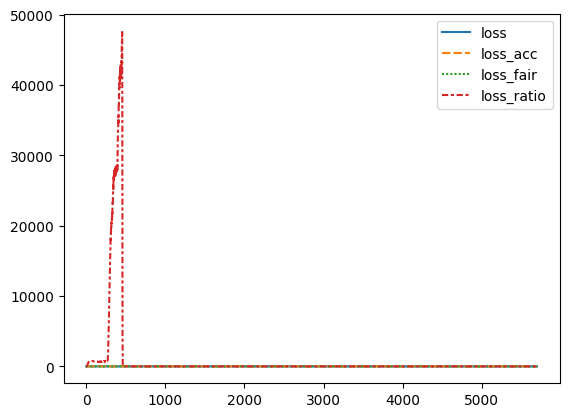

    -- lambda_fair=5, lambda_ratio=0.0008
epoch 0 loss_acc 0.6952 loss_fair 2.0353 loss_ratio 693.8461 DP_gap_test 0.0709 EO_gap_test 0.205 ACC_test 0.8205 proportion_changed 0.5384
epoch 30 loss_acc 0.6972 loss_fair 2.0658 loss_ratio 5.7683 DP_gap_test 0.1537 EO_gap_test 0.4027 ACC_test 0.8234 proportion_changed 0.4811
epoch 60 loss_acc 0.697 loss_fair 2.0626 loss_ratio 5.3953 DP_gap_test 0.1518 EO_gap_test 0.4002 ACC_test 0.8247 proportion_changed 0.4875
epoch 90 loss_acc 0.6915 loss_fair 2.0599 loss_ratio 5.7413 DP_gap_test 0.1441 EO_gap_test 0.3677 ACC_test 0.8225 proportion_changed 0.4906
epoch 120 loss_acc 0.6931 loss_fair 2.0632 loss_ratio 5.8615 DP_gap_test 0.1367 EO_gap_test 0.3624 ACC_test 0.822 proportion_changed 0.4912

Final DP gap: 0.1358482003372572
Final EO gap: 0.35351133954264297
Final Accuracy: 82.32163758608488
Final proportion changed: 0.4881999074502545


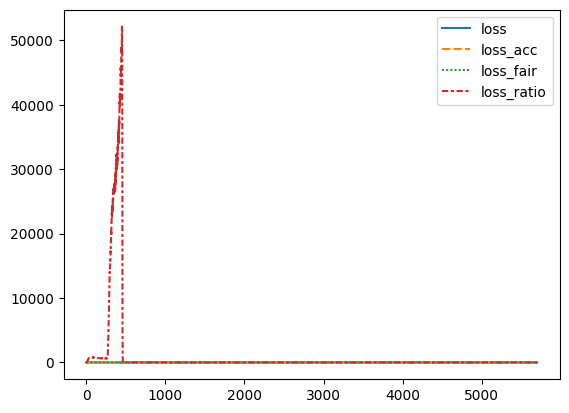

    -- lambda_fair=5, lambda_ratio=0.001
epoch 0 loss_acc 0.6946 loss_fair 2.0439 loss_ratio 514.727 DP_gap_test 0.0717 EO_gap_test 0.2075 ACC_test 0.8207 proportion_changed 0.5379
epoch 30 loss_acc 0.6961 loss_fair 2.0672 loss_ratio 4.8727 DP_gap_test 0.1578 EO_gap_test 0.4122 ACC_test 0.8257 proportion_changed 0.4838
epoch 60 loss_acc 0.6952 loss_fair 2.0607 loss_ratio 5.109 DP_gap_test 0.1591 EO_gap_test 0.4212 ACC_test 0.824 proportion_changed 0.4839
epoch 90 loss_acc 0.6924 loss_fair 2.0591 loss_ratio 5.3391 DP_gap_test 0.1506 EO_gap_test 0.3788 ACC_test 0.8225 proportion_changed 0.4841
epoch 120 loss_acc 0.6927 loss_fair 2.0576 loss_ratio 5.1687 DP_gap_test 0.1533 EO_gap_test 0.3842 ACC_test 0.8216 proportion_changed 0.4809

Final DP gap: 0.14458016682138128
Final EO gap: 0.3684896362615245
Final Accuracy: 82.00315757955195
Final proportion changed: 0.4814764406456706


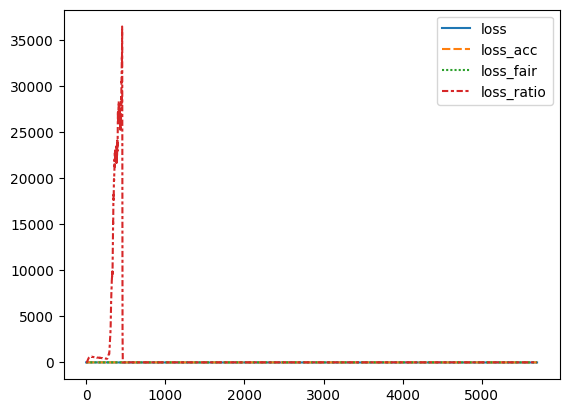


=== Baseline (원본 GLM, f) ===
F1: 0.4137619812631997
Precision: 0.27678894872847587
Recall: 0.8191109205260149
PR-AUC: 0.45895828856980675
ROC-AUC: 0.749096551524137
DP_gap: 0.6723713206808999
EO_gap: 1.1368984156876834

  [age_gender] Grid search 결과 (val, accuracy 높은 순 상위 5개):
   lambda_fair  lambda_ratio  n_classes  DP_gap_val  EO_gap_val  accuracy_val  \
1            5        0.0003          8    0.134101    0.346585      0.825979   
3            5        0.0008          8    0.135848    0.353511      0.823216   
4            5        0.0010          8    0.144580    0.368490      0.820032   
2            5        0.0005          8    0.131649    0.347003      0.819487   
0            5        0.0001          8    0.124533    0.323300      0.819446   

     f1_val  precision_val  recall_val  pr_auc_val  roc_auc_val  \
1  0.338610       0.612921    0.233919    0.427485     0.734569   
3  0.340225       0.588060    0.239351    0.416334     0.731433   
4  0.344000       0.562368    0.2

In [ ]:
import itertools
import pandas as pd

lamb_fair_grid = [5]
lamb_ratio_grid = [0.0001, 0.0003, 0.0005, 0.0008, 0.001]

attr = 'age_gender'
print(f"\n{'='*60}\nAttribute: {attr}\n{'='*60}")

S_train_cat, S_val_cat, n_classes = get_sensitive_attribute(
    data, attr, sens_config, idx_train, idx_val
)

all_cats = pd.concat([S_train_cat, S_val_cat]).astype('category')
S_train_codes = all_cats.cat.codes[:len(S_train_cat)].values
S_val_codes = all_cats.cat.codes[len(S_train_cat):].values

print(f"  -> {n_classes} categories: {list(all_cats.cat.categories)}")

input_dim = X_train.shape[1]
attr_grid_results = []

for lamb_fair, lamb_ratio in itertools.product(lamb_fair_grid, lamb_ratio_grid):
    print(f"    -- lambda_fair={lamb_fair}, lambda_ratio={lamb_ratio}")

    NN_r = make_NN_r(input_dim, hidden=(64, 32))

    rbmd_model = rbmd_debiasing(
        learning_rate=0.01,
        batch_size=2048,
        lamb_fair=lamb_fair,
        lamb_ratio=lamb_ratio,
        num_epochs=150,
        NN_r=NN_r,
        n_classes=n_classes,
        GPU='cuda:0',
        threshold=THRESHOLD
    )

    rbmd_model.train(
        X_train, y_train, S_train_codes,
        y_hat=proba_train,
        X_test=X_val, y_test=y_val, S_test=S_val_codes,
        y_hat_test=proba_val,
        plot_losses=True
    )

    val_probs = rbmd_model.predict_proba(X_val, proba_val)
    val_preds = rbmd_model.predict(X_val, proba_val)

    attr_grid_results.append({
        'lambda_fair': lamb_fair,
        'lambda_ratio': lamb_ratio,
        'n_classes': n_classes,
        'DP_gap_val': group_fairness_gap(val_preds, S_val_codes),
        'EO_gap_val': disparate_mistreatment_general(val_preds, y_val, S_val_codes),
        'accuracy_val': float(np.mean(val_preds == y_val)),
        'f1_val': f1_score(y_val, val_preds),
        'precision_val': precision_score(y_val, val_preds, zero_division=0),
        'recall_val': recall_score(y_val, val_preds, zero_division=0),
        'pr_auc_val': average_precision_score(y_val, val_probs),
        'roc_auc_val': roc_auc_score(y_val, val_probs),
        'proportion_changed_val': float(np.mean(val_preds != (proba_val > THRESHOLD))),
    })

grid_results = {}
grid_results[attr] = pd.DataFrame(attr_grid_results)

# baseline
baseline_preds = (proba_val > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) ===")
print("F1:", f1_score(y_val, baseline_preds))
print("Precision:", precision_score(y_val, baseline_preds, zero_division=0))
print("Recall:", recall_score(y_val, baseline_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_val, proba_val))
print("ROC-AUC:", roc_auc_score(y_val, proba_val))
print("DP_gap:", group_fairness_gap(baseline_preds, S_val_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds, y_val, S_val_codes))

# 튜닝 후 -- grid_results 직접 사용 (조합당 1행이므로 groupby 불필요)
print(f"\n  [{attr}] Grid search 결과 (val, accuracy 높은 순 상위 5개):")
print(grid_results[attr].sort_values('accuracy_val', ascending=False).head())

print(f"\n  [{attr}] Grid search 결과 (val, 변화 최소화 우선 상위 5개):")
print(grid_results[attr].sort_values('proportion_changed_val').head())

print(f"\n  [{attr}] Grid search 결과 (val, DP gap 낮은 순 상위 5개):")
print(grid_results[attr].sort_values('DP_gap_val').head())

epoch 0 loss_acc 0.6915 loss_fair 2.0289 loss_ratio 523.0024 DP_gap_test 0.0393 EO_gap_test 0.1191 ACC_test 0.8417 proportion_changed 0.5321
epoch 30 loss_acc 0.6937 loss_fair 2.0599 loss_ratio 4.341 DP_gap_test 0.1088 EO_gap_test 0.3052 ACC_test 0.8366 proportion_changed 0.4903
epoch 60 loss_acc 0.6914 loss_fair 2.0553 loss_ratio 4.6363 DP_gap_test 0.0979 EO_gap_test 0.2712 ACC_test 0.8383 proportion_changed 0.4938
epoch 90 loss_acc 0.6915 loss_fair 2.0613 loss_ratio 5.4155 DP_gap_test 0.0957 EO_gap_test 0.2645 ACC_test 0.8391 proportion_changed 0.4948
epoch 120 loss_acc 0.6899 loss_fair 2.0518 loss_ratio 5.153 DP_gap_test 0.1048 EO_gap_test 0.287 ACC_test 0.8399 proportion_changed 0.4915

Final DP gap: 0.11159580321633669
Final EO gap: 0.3069358423764379
Final Accuracy: 83.98112783644125
Final proportion changed: 0.4898833044788349


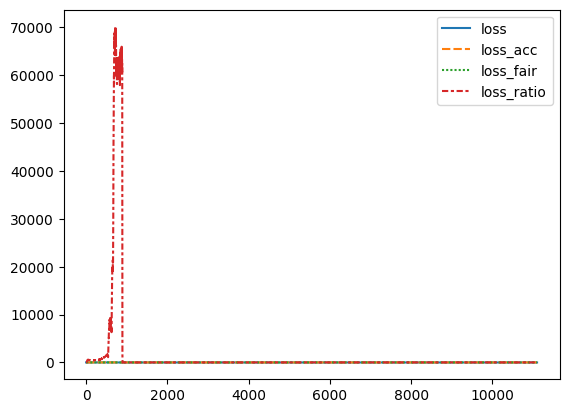


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.6662714428516722
EO_gap: 1.1796066930746614

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8398112783644125
F1: 0.2697752876679318
Precision: 0.5084014532243415
Recall: 0.18359983599836
PR-AUC: 0.3554288421663658
ROC-AUC: 0.7218993840429959
DP_gap: 0.11159580321633669
EO_gap: 0.3069358423764379
Proportion changed: 0.4898833044788349


In [ ]:
# test set으로 평가

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'age_gender', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.001,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

epoch 0 loss_acc 0.6919 loss_fair 2.042 loss_ratio 629.0928 DP_gap_test 0.0382 EO_gap_test 0.1171 ACC_test 0.8417 proportion_changed 0.5325
epoch 30 loss_acc 0.7043 loss_fair 2.061 loss_ratio 1.8168 DP_gap_test 0.203 EO_gap_test 0.5135 ACC_test 0.8192 proportion_changed 0.4406
epoch 60 loss_acc 0.7023 loss_fair 2.0493 loss_ratio 1.6526 DP_gap_test 0.1823 EO_gap_test 0.4743 ACC_test 0.8242 proportion_changed 0.4476
epoch 90 loss_acc 0.6995 loss_fair 2.061 loss_ratio 1.8203 DP_gap_test 0.1809 EO_gap_test 0.466 ACC_test 0.8236 proportion_changed 0.4479
epoch 120 loss_acc 0.696 loss_fair 2.0518 loss_ratio 1.6898 DP_gap_test 0.182 EO_gap_test 0.4625 ACC_test 0.8267 proportion_changed 0.4496

Final DP gap: 0.16722851977003964
Final EO gap: 0.42056078382347495
Final Accuracy: 82.80756472438448
Final proportion changed: 0.4519010929467271


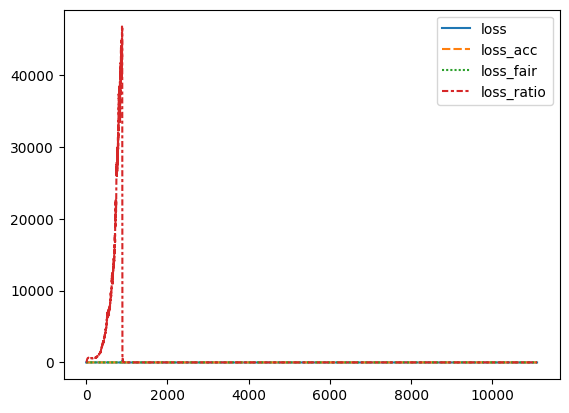


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.6662714428516722
EO_gap: 1.1796066930746614

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8280756472438447
F1: 0.33242674603581873
Precision: 0.4441854086670324
Recall: 0.2656006560065601
PR-AUC: 0.3527785358717488
ROC-AUC: 0.7179003829047618
DP_gap: 0.16722851977003964
EO_gap: 0.42056078382347495
Proportion changed: 0.4519010929467271


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'age_gender', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.005,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

- COMMOD에서 설정한 lambda_fair=8, lambda_ratio=0.01로 시도.. 궁금하니까..

epoch 0 loss_acc 0.694 loss_fair 2.0468 loss_ratio 606.6982 DP_gap_test 0.0382 EO_gap_test 0.1185 ACC_test 0.8418 proportion_changed 0.5326
epoch 30 loss_acc 0.7076 loss_fair 2.0573 loss_ratio 0.8944 DP_gap_test 0.2755 EO_gap_test 0.6527 ACC_test 0.7973 proportion_changed 0.3874
epoch 60 loss_acc 0.7067 loss_fair 2.0536 loss_ratio 0.8403 DP_gap_test 0.2918 EO_gap_test 0.6807 ACC_test 0.7943 proportion_changed 0.3815
epoch 90 loss_acc 0.7064 loss_fair 2.0538 loss_ratio 0.9116 DP_gap_test 0.2789 EO_gap_test 0.6593 ACC_test 0.7998 proportion_changed 0.3921
epoch 120 loss_acc 0.7055 loss_fair 2.0558 loss_ratio 0.9268 DP_gap_test 0.2676 EO_gap_test 0.6404 ACC_test 0.8024 proportion_changed 0.3986

Final DP gap: 0.245653677225527
Final EO gap: 0.5992183455478846
Final Accuracy: 81.2229902070916
Final proportion changed: 0.41374707600407046


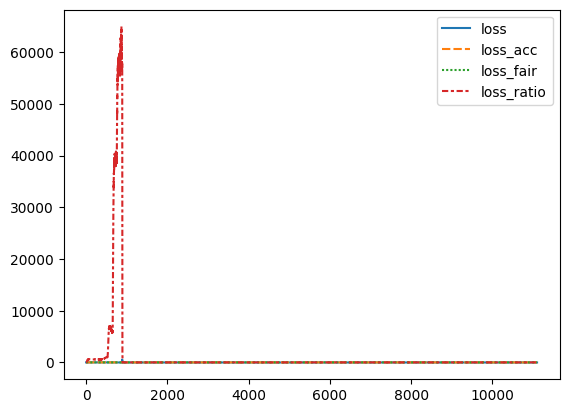


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.6662714428516722
EO_gap: 1.1796066930746614

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8122299020709159
F1: 0.36492043625961024
Precision: 0.40110052078215586
Recall: 0.33472734727347275
PR-AUC: 0.3479906903974903
ROC-AUC: 0.7214891157450773
DP_gap: 0.245653677225527
EO_gap: 0.5992183455478846
Proportion changed: 0.41374707600407046


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'age_gender', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=8, lamb_ratio=0.01,    # COMMOD 설정으로
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

- age


Attribute: age
  -> 7 categories: ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    -- lambda_fair=1, lambda_ratio=0.001
epoch 0 loss_acc 0.6933 loss_fair 1.9191 loss_ratio 653.3437 DP_gap_test 0.0699 EO_gap_test 0.2084 ACC_test 0.821 proportion_changed 0.5384
epoch 30 loss_acc 0.6961 loss_fair 1.9315 loss_ratio 4.8233 DP_gap_test 0.1636 EO_gap_test 0.4308 ACC_test 0.8244 proportion_changed 0.4788
epoch 60 loss_acc 0.6918 loss_fair 1.9302 loss_ratio 5.5843 DP_gap_test 0.1637 EO_gap_test 0.4272 ACC_test 0.8209 proportion_changed 0.482
epoch 90 loss_acc 0.6929 loss_fair 1.9256 loss_ratio 5.3739 DP_gap_test 0.1487 EO_gap_test 0.3978 ACC_test 0.8241 proportion_changed 0.4884
epoch 120 loss_acc 0.6882 loss_fair 1.9317 loss_ratio 5.3637 DP_gap_test 0.1505 EO_gap_test 0.3963 ACC_test 0.823 proportion_changed 0.4872

Final DP gap: 0.15985307566217813
Final EO gap: 0.429031588253576
Final Accuracy: 82.51898630808176
Final proportion changed: 0.4810545226882979


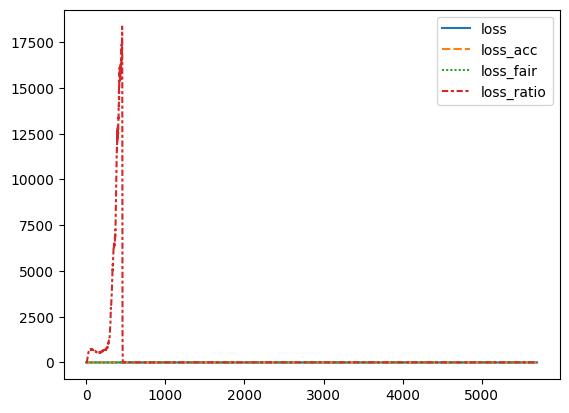

    -- lambda_fair=1, lambda_ratio=0.01
epoch 0 loss_acc 0.6967 loss_fair 1.9125 loss_ratio 460.1039 DP_gap_test 0.0728 EO_gap_test 0.2168 ACC_test 0.8211 proportion_changed 0.537
epoch 30 loss_acc 0.7085 loss_fair 1.923 loss_ratio 0.8799 DP_gap_test 0.3433 EO_gap_test 0.7883 ACC_test 0.7886 proportion_changed 0.378
epoch 60 loss_acc 0.7093 loss_fair 1.9302 loss_ratio 0.9265 DP_gap_test 0.3412 EO_gap_test 0.7868 ACC_test 0.7918 proportion_changed 0.3852
epoch 90 loss_acc 0.7099 loss_fair 1.9253 loss_ratio 0.9913 DP_gap_test 0.3618 EO_gap_test 0.8319 ACC_test 0.7896 proportion_changed 0.3793
epoch 120 loss_acc 0.705 loss_fair 1.9244 loss_ratio 0.9455 DP_gap_test 0.332 EO_gap_test 0.7701 ACC_test 0.7948 proportion_changed 0.3893

Final DP gap: 0.31355926272912166
Final EO gap: 0.7312539117757668
Final Accuracy: 79.75746522579415
Final proportion changed: 0.39592236709584344


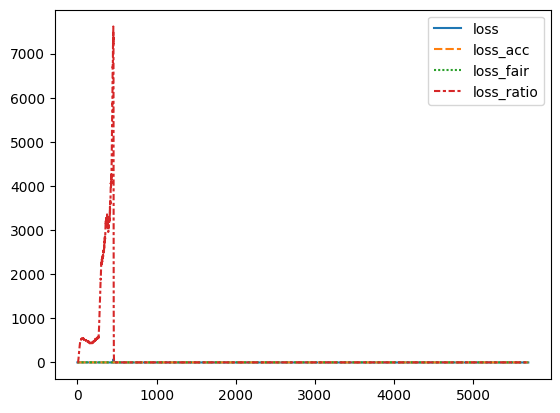

    -- lambda_fair=1, lambda_ratio=0.1
epoch 0 loss_acc 0.6937 loss_fair 1.8968 loss_ratio 494.4032 DP_gap_test 0.0714 EO_gap_test 0.212 ACC_test 0.8209 proportion_changed 0.5374
epoch 30 loss_acc 0.7362 loss_fair 1.9259 loss_ratio 0.1322 DP_gap_test 0.0693 EO_gap_test 0.1545 ACC_test 0.5818 proportion_changed 0.2455
epoch 60 loss_acc 0.7339 loss_fair 1.915 loss_ratio 0.1577 DP_gap_test 0.1696 EO_gap_test 0.2128 ACC_test 0.632 proportion_changed 0.2241
epoch 90 loss_acc 0.7335 loss_fair 1.9252 loss_ratio 0.0554 DP_gap_test 0.5847 EO_gap_test 1.1353 ACC_test 0.6693 proportion_changed 0.1569
epoch 120 loss_acc 0.7318 loss_fair 1.9355 loss_ratio 0.059 DP_gap_test 0.5801 EO_gap_test 1.1363 ACC_test 0.677 proportion_changed 0.1686

Final DP gap: 0.574855286433204
Final EO gap: 1.1224858621288978
Final Accuracy: 68.05944960121948
Final proportion changed: 0.17376214715409533


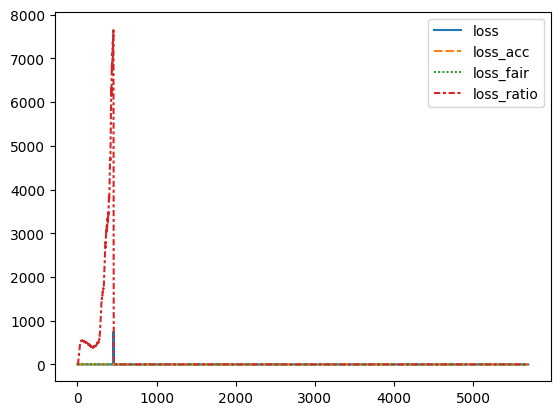

    -- lambda_fair=1, lambda_ratio=0.5
epoch 0 loss_acc 0.6949 loss_fair 1.9185 loss_ratio 495.9574 DP_gap_test 0.0705 EO_gap_test 0.2086 ACC_test 0.8207 proportion_changed 0.5377
epoch 30 loss_acc 0.7416 loss_fair 1.9339 loss_ratio 0.0053 DP_gap_test 0.7001 EO_gap_test 1.2862 ACC_test 0.5935 proportion_changed 0.049
epoch 60 loss_acc 0.7446 loss_fair 1.93 loss_ratio 0.0045 DP_gap_test 0.6963 EO_gap_test 1.2788 ACC_test 0.5961 proportion_changed 0.0527
epoch 90 loss_acc 0.7432 loss_fair 1.9294 loss_ratio 0.0044 DP_gap_test 0.6904 EO_gap_test 1.2691 ACC_test 0.5963 proportion_changed 0.0538
epoch 120 loss_acc 0.7421 loss_fair 1.9268 loss_ratio 0.0034 DP_gap_test 0.6884 EO_gap_test 1.2632 ACC_test 0.5958 proportion_changed 0.053

Final DP gap: 0.6916598729264595
Final EO gap: 1.2685843518841837
Final Accuracy: 59.59114788904919
Final proportion changed: 0.05295750877861556


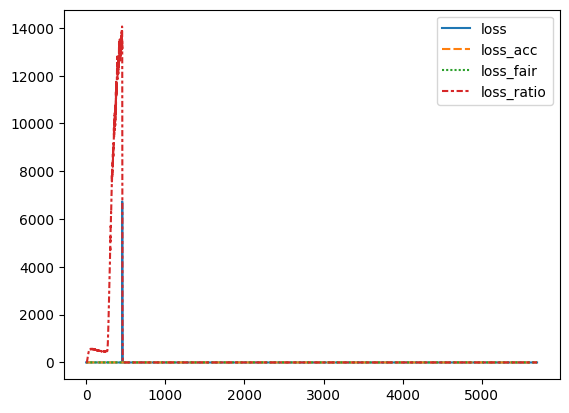

    -- lambda_fair=3, lambda_ratio=0.001
epoch 0 loss_acc 0.6947 loss_fair 1.9162 loss_ratio 606.7534 DP_gap_test 0.0717 EO_gap_test 0.213 ACC_test 0.8207 proportion_changed 0.5376
epoch 30 loss_acc 0.6962 loss_fair 1.9372 loss_ratio 5.0187 DP_gap_test 0.1549 EO_gap_test 0.4179 ACC_test 0.8231 proportion_changed 0.4875
epoch 60 loss_acc 0.6967 loss_fair 1.9238 loss_ratio 5.1849 DP_gap_test 0.1505 EO_gap_test 0.4078 ACC_test 0.8231 proportion_changed 0.4898
epoch 90 loss_acc 0.6918 loss_fair 1.9221 loss_ratio 4.808 DP_gap_test 0.1481 EO_gap_test 0.3904 ACC_test 0.8236 proportion_changed 0.4854
epoch 120 loss_acc 0.6922 loss_fair 1.927 loss_ratio 5.3402 DP_gap_test 0.1536 EO_gap_test 0.4086 ACC_test 0.822 proportion_changed 0.4844

Final DP gap: 0.15433495131271344
Final EO gap: 0.4117417689461541
Final Accuracy: 82.12973296676375
Final proportion changed: 0.48255165092413643


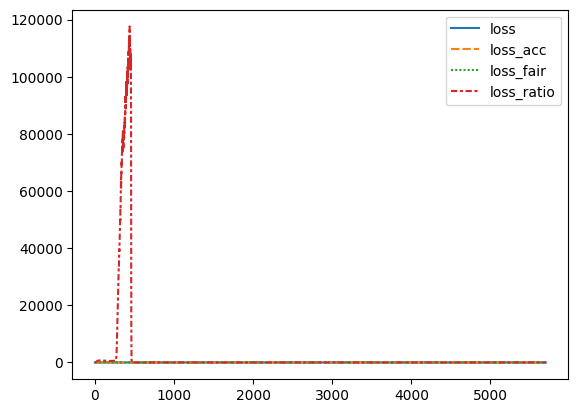

    -- lambda_fair=3, lambda_ratio=0.01
epoch 0 loss_acc 0.6957 loss_fair 1.9156 loss_ratio 680.4728 DP_gap_test 0.0702 EO_gap_test 0.2097 ACC_test 0.8208 proportion_changed 0.5383
epoch 30 loss_acc 0.7066 loss_fair 1.9279 loss_ratio 0.924 DP_gap_test 0.3769 EO_gap_test 0.8684 ACC_test 0.7851 proportion_changed 0.3675
epoch 60 loss_acc 0.7092 loss_fair 1.9246 loss_ratio 0.9053 DP_gap_test 0.3683 EO_gap_test 0.8447 ACC_test 0.7868 proportion_changed 0.3764
epoch 90 loss_acc 0.7059 loss_fair 1.9303 loss_ratio 0.9458 DP_gap_test 0.3632 EO_gap_test 0.8343 ACC_test 0.7869 proportion_changed 0.3776
epoch 120 loss_acc 0.7043 loss_fair 1.9258 loss_ratio 0.9469 DP_gap_test 0.3596 EO_gap_test 0.8262 ACC_test 0.7858 proportion_changed 0.3761

Final DP gap: 0.3577273145604455
Final EO gap: 0.8243479584288473
Final Accuracy: 78.62917494623949
Final proportion changed: 0.37723548466124074


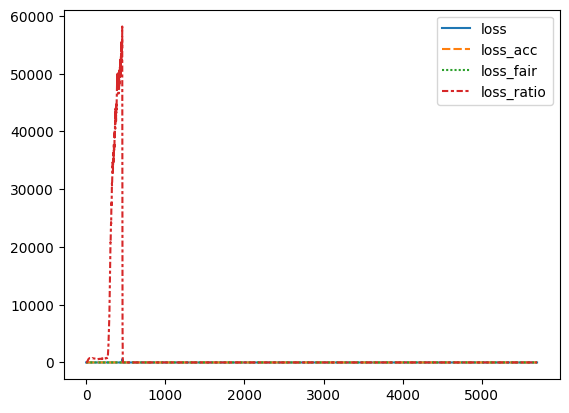

    -- lambda_fair=3, lambda_ratio=0.1
epoch 0 loss_acc 0.6952 loss_fair 1.8972 loss_ratio 445.9437 DP_gap_test 0.0747 EO_gap_test 0.2228 ACC_test 0.8215 proportion_changed 0.5364
epoch 30 loss_acc 0.7316 loss_fair 1.9263 loss_ratio 0.0877 DP_gap_test 0.5328 EO_gap_test 1.0148 ACC_test 0.6595 proportion_changed 0.1699
epoch 60 loss_acc 0.731 loss_fair 1.9308 loss_ratio 0.0681 DP_gap_test 0.565 EO_gap_test 1.086 ACC_test 0.6619 proportion_changed 0.1557
epoch 90 loss_acc 0.7298 loss_fair 1.9206 loss_ratio 0.0639 DP_gap_test 0.5731 EO_gap_test 1.1073 ACC_test 0.6691 proportion_changed 0.1596
epoch 120 loss_acc 0.7334 loss_fair 1.9311 loss_ratio 0.0613 DP_gap_test 0.5821 EO_gap_test 1.1256 ACC_test 0.6692 proportion_changed 0.1585

Final DP gap: 0.5821432194876168
Final EO gap: 1.134145065971512
Final Accuracy: 67.21425266080519
Final proportion changed: 0.16288755205923183


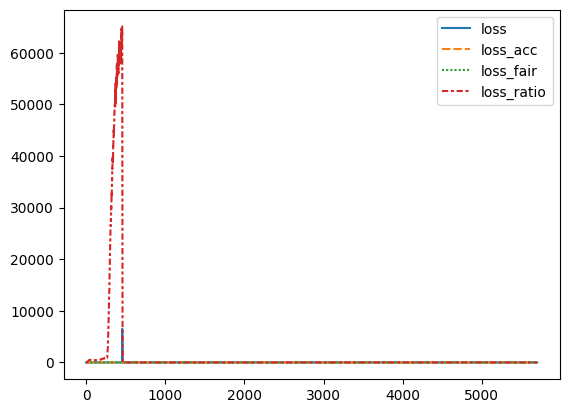

    -- lambda_fair=3, lambda_ratio=0.5
epoch 0 loss_acc 0.6946 loss_fair 1.91 loss_ratio 475.1909 DP_gap_test 0.0716 EO_gap_test 0.2124 ACC_test 0.8209 proportion_changed 0.5373
epoch 30 loss_acc 0.7414 loss_fair 1.9324 loss_ratio 0.0045 DP_gap_test 0.7048 EO_gap_test 1.2981 ACC_test 0.5931 proportion_changed 0.0495
epoch 60 loss_acc 0.7485 loss_fair 1.9205 loss_ratio 0.0036 DP_gap_test 0.6999 EO_gap_test 1.2867 ACC_test 0.592 proportion_changed 0.0473
epoch 90 loss_acc 0.7408 loss_fair 1.9236 loss_ratio 0.0041 DP_gap_test 0.7022 EO_gap_test 1.2944 ACC_test 0.5939 proportion_changed 0.0498
epoch 120 loss_acc 0.7406 loss_fair 1.9279 loss_ratio 0.0047 DP_gap_test 0.7083 EO_gap_test 1.3048 ACC_test 0.5915 proportion_changed 0.0466

Final DP gap: 0.703287393793007
Final EO gap: 1.2987465294902194
Final Accuracy: 59.49723711789204
Final proportion changed: 0.05139232925932983


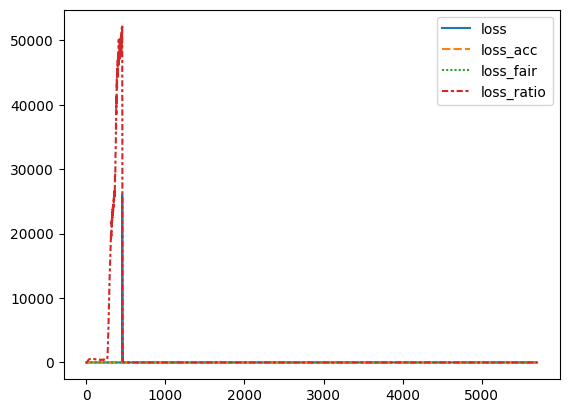

    -- lambda_fair=5, lambda_ratio=0.001
epoch 0 loss_acc 0.6915 loss_fair 1.9084 loss_ratio 505.81 DP_gap_test 0.0717 EO_gap_test 0.2136 ACC_test 0.8211 proportion_changed 0.5373
epoch 30 loss_acc 0.7047 loss_fair 1.9271 loss_ratio 7.8814 DP_gap_test 0.0759 EO_gap_test 0.1281 ACC_test 0.794 proportion_changed 0.4377
epoch 60 loss_acc 0.6961 loss_fair 1.928 loss_ratio 5.0615 DP_gap_test 0.1753 EO_gap_test 0.4657 ACC_test 0.8234 proportion_changed 0.4783
epoch 90 loss_acc 0.6988 loss_fair 1.9294 loss_ratio 4.8377 DP_gap_test 0.1688 EO_gap_test 0.4366 ACC_test 0.8229 proportion_changed 0.4793
epoch 120 loss_acc 0.6941 loss_fair 1.9258 loss_ratio 4.9515 DP_gap_test 0.1547 EO_gap_test 0.4152 ACC_test 0.8228 proportion_changed 0.4847

Final DP gap: 0.15410186475657386
Final EO gap: 0.4121981490702898
Final Accuracy: 82.31483245774015
Final proportion changed: 0.4870974766584098


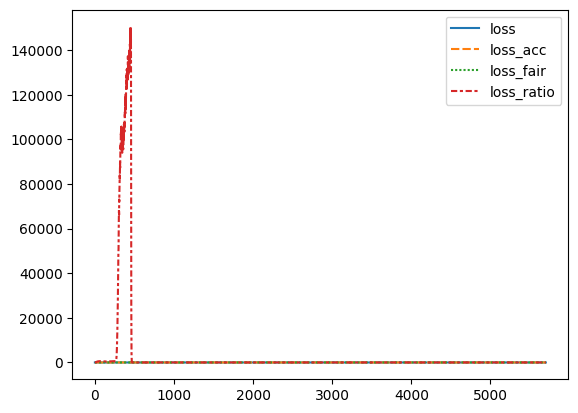

    -- lambda_fair=5, lambda_ratio=0.01
epoch 0 loss_acc 0.6977 loss_fair 1.9059 loss_ratio 472.8874 DP_gap_test 0.0722 EO_gap_test 0.2144 ACC_test 0.8211 proportion_changed 0.5371
epoch 30 loss_acc 0.7121 loss_fair 1.9313 loss_ratio 0.943 DP_gap_test 0.368 EO_gap_test 0.8467 ACC_test 0.7784 proportion_changed 0.3592
epoch 60 loss_acc 0.7099 loss_fair 1.9291 loss_ratio 0.8821 DP_gap_test 0.3629 EO_gap_test 0.8402 ACC_test 0.7831 proportion_changed 0.369
epoch 90 loss_acc 0.7115 loss_fair 1.9223 loss_ratio 0.9174 DP_gap_test 0.3617 EO_gap_test 0.8337 ACC_test 0.7835 proportion_changed 0.3702
epoch 120 loss_acc 0.7124 loss_fair 1.9285 loss_ratio 0.8762 DP_gap_test 0.3626 EO_gap_test 0.8337 ACC_test 0.7826 proportion_changed 0.3686

Final DP gap: 0.3655839506527023
Final EO gap: 0.8362660617583081
Final Accuracy: 78.11198519204072
Final proportion changed: 0.3644690638865449


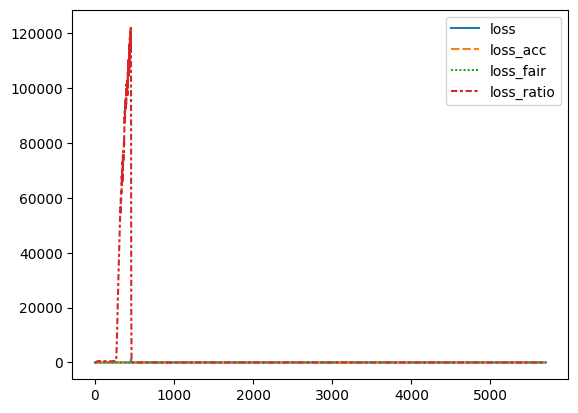

    -- lambda_fair=5, lambda_ratio=0.1
epoch 0 loss_acc 0.6957 loss_fair 1.9116 loss_ratio 525.5801 DP_gap_test 0.072 EO_gap_test 0.2129 ACC_test 0.8208 proportion_changed 0.5373
epoch 30 loss_acc 0.7289 loss_fair 1.9266 loss_ratio 0.0578 DP_gap_test 0.6001 EO_gap_test 1.16 ACC_test 0.6681 proportion_changed 0.1556
epoch 60 loss_acc 0.7318 loss_fair 1.9192 loss_ratio 0.06 DP_gap_test 0.5984 EO_gap_test 1.1629 ACC_test 0.6694 proportion_changed 0.1573
epoch 90 loss_acc 0.7298 loss_fair 1.926 loss_ratio 0.0609 DP_gap_test 0.5975 EO_gap_test 1.1599 ACC_test 0.6699 proportion_changed 0.1581
epoch 120 loss_acc 0.7301 loss_fair 1.9259 loss_ratio 0.0594 DP_gap_test 0.5949 EO_gap_test 1.1604 ACC_test 0.6724 proportion_changed 0.1618

Final DP gap: 0.5979860794611245
Final EO gap: 1.1789419577834641
Final Accuracy: 67.38846394643004
Final proportion changed: 0.16476576748237473


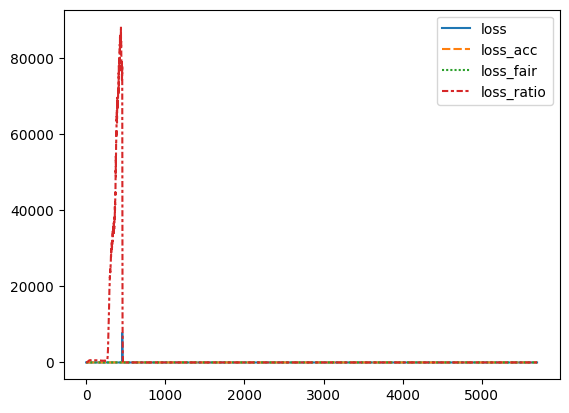

    -- lambda_fair=5, lambda_ratio=0.5
epoch 0 loss_acc 0.6946 loss_fair 1.9119 loss_ratio 379.2746 DP_gap_test 0.0724 EO_gap_test 0.2143 ACC_test 0.8209 proportion_changed 0.5368
epoch 30 loss_acc 0.7419 loss_fair 1.9214 loss_ratio 0.0085 DP_gap_test 0.7012 EO_gap_test 1.2954 ACC_test 0.5906 proportion_changed 0.0524
epoch 60 loss_acc 0.738 loss_fair 1.932 loss_ratio 0.0061 DP_gap_test 0.7033 EO_gap_test 1.3064 ACC_test 0.5951 proportion_changed 0.0542
epoch 90 loss_acc 0.7411 loss_fair 1.9337 loss_ratio 0.0062 DP_gap_test 0.6987 EO_gap_test 1.2942 ACC_test 0.5967 proportion_changed 0.0545
epoch 120 loss_acc 0.7401 loss_fair 1.9257 loss_ratio 0.0062 DP_gap_test 0.6862 EO_gap_test 1.2686 ACC_test 0.5999 proportion_changed 0.0585

Final DP gap: 0.6906573937235849
Final EO gap: 1.2710364630118176
Final Accuracy: 59.4836268612026
Final proportion changed: 0.0512834472058143


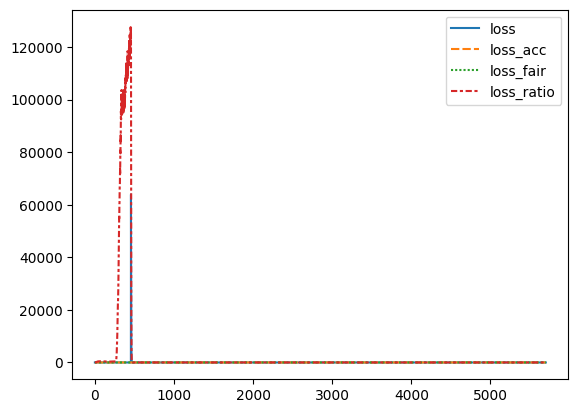

    -- lambda_fair=10, lambda_ratio=0.001
epoch 0 loss_acc 0.6933 loss_fair 1.9212 loss_ratio 421.0171 DP_gap_test 0.0716 EO_gap_test 0.2114 ACC_test 0.8207 proportion_changed 0.5373
epoch 30 loss_acc 0.6985 loss_fair 1.9256 loss_ratio 6.0798 DP_gap_test 0.1487 EO_gap_test 0.4091 ACC_test 0.826 proportion_changed 0.4866
epoch 60 loss_acc 0.7026 loss_fair 1.9256 loss_ratio 4.6697 DP_gap_test 0.1517 EO_gap_test 0.4157 ACC_test 0.8256 proportion_changed 0.4872
epoch 90 loss_acc 0.6977 loss_fair 1.9281 loss_ratio 4.7215 DP_gap_test 0.1499 EO_gap_test 0.411 ACC_test 0.8264 proportion_changed 0.488
epoch 120 loss_acc 0.6978 loss_fair 1.9356 loss_ratio 4.5512 DP_gap_test 0.1568 EO_gap_test 0.423 ACC_test 0.8246 proportion_changed 0.4838

Final DP gap: 0.16644769452924016
Final EO gap: 0.44028051351587105
Final Accuracy: 82.35294117647058
Final proportion changed: 0.4793124098320494


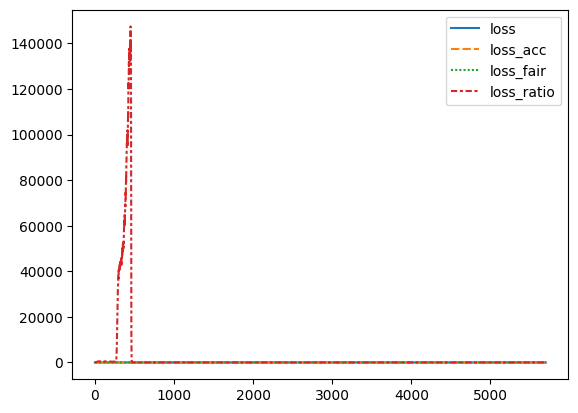

    -- lambda_fair=10, lambda_ratio=0.01
epoch 0 loss_acc 0.6955 loss_fair 1.911 loss_ratio 522.241 DP_gap_test 0.0721 EO_gap_test 0.215 ACC_test 0.8211 proportion_changed 0.5373
epoch 30 loss_acc 0.7147 loss_fair 1.9214 loss_ratio 4.6004 DP_gap_test 0.2605 EO_gap_test 0.5895 ACC_test 0.702 proportion_changed 0.4642
epoch 60 loss_acc 0.7199 loss_fair 1.9331 loss_ratio 1.0161 DP_gap_test 0.2806 EO_gap_test 0.5351 ACC_test 0.7339 proportion_changed 0.3071
epoch 90 loss_acc 0.7098 loss_fair 1.9339 loss_ratio 0.9728 DP_gap_test 0.3507 EO_gap_test 0.7733 ACC_test 0.7757 proportion_changed 0.3508
epoch 120 loss_acc 0.7121 loss_fair 1.9209 loss_ratio 0.9557 DP_gap_test 0.3605 EO_gap_test 0.8116 ACC_test 0.7809 proportion_changed 0.3616

Final DP gap: 0.36478543699787697
Final EO gap: 0.8300987862419973
Final Accuracy: 78.20589596319788
Final proportion changed: 0.3634210741214579


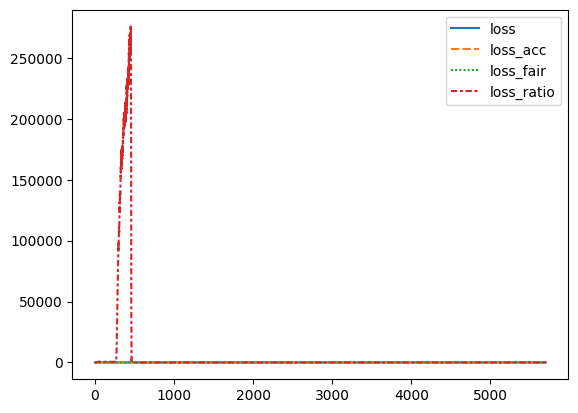

    -- lambda_fair=10, lambda_ratio=0.1
epoch 0 loss_acc 0.6948 loss_fair 1.9025 loss_ratio 618.9182 DP_gap_test 0.0688 EO_gap_test 0.2034 ACC_test 0.8204 proportion_changed 0.5386
epoch 30 loss_acc 0.9513 loss_fair 1.9176 loss_ratio 2.0134 DP_gap_test 0.0 EO_gap_test 0.0 ACC_test 0.1904 proportion_changed 0.4364
epoch 60 loss_acc 0.9296 loss_fair 1.9279 loss_ratio 1.7359 DP_gap_test 0.003 EO_gap_test 0.0063 ACC_test 0.1914 proportion_changed 0.4359
epoch 90 loss_acc 0.73 loss_fair 1.9178 loss_ratio 0.0764 DP_gap_test 0.6421 EO_gap_test 1.2702 ACC_test 0.6573 proportion_changed 0.1441
epoch 120 loss_acc 0.7295 loss_fair 1.9312 loss_ratio 0.0755 DP_gap_test 0.5998 EO_gap_test 1.1901 ACC_test 0.6736 proportion_changed 0.1648

Final DP gap: 0.616925315306356
Final EO gap: 1.2123038101334176
Final Accuracy: 66.8168331654735
Final proportion changed: 0.15619130576802678


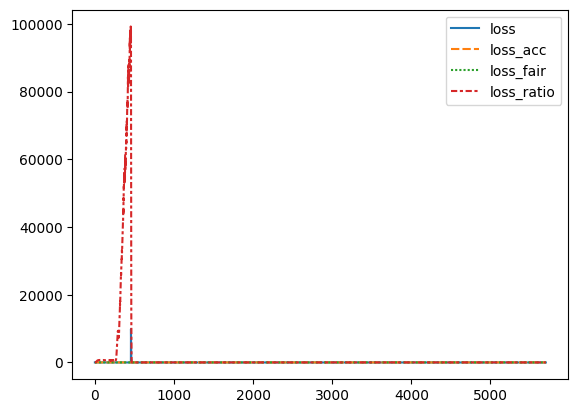

    -- lambda_fair=10, lambda_ratio=0.5
epoch 0 loss_acc 0.6928 loss_fair 1.904 loss_ratio 569.7542 DP_gap_test 0.0709 EO_gap_test 0.2108 ACC_test 0.821 proportion_changed 0.5375
epoch 30 loss_acc 0.801 loss_fair 1.9269 loss_ratio 0.332 DP_gap_test 0.0028 EO_gap_test 0.0047 ACC_test 0.1908 proportion_changed 0.436
epoch 60 loss_acc 0.7453 loss_fair 1.9238 loss_ratio 0.0005 DP_gap_test 0.7223 EO_gap_test 1.3152 ACC_test 0.5704 proportion_changed 0.0173
epoch 90 loss_acc 0.7441 loss_fair 1.9264 loss_ratio 0.0037 DP_gap_test 0.6976 EO_gap_test 1.2857 ACC_test 0.5913 proportion_changed 0.0467
epoch 120 loss_acc 0.7424 loss_fair 1.9254 loss_ratio 0.0037 DP_gap_test 0.6978 EO_gap_test 1.2859 ACC_test 0.5913 proportion_changed 0.0468

Final DP gap: 0.6977803100555133
Final EO gap: 1.2858749176312396
Final Accuracy: 59.132482238615026
Final proportion changed: 0.046764841984919835


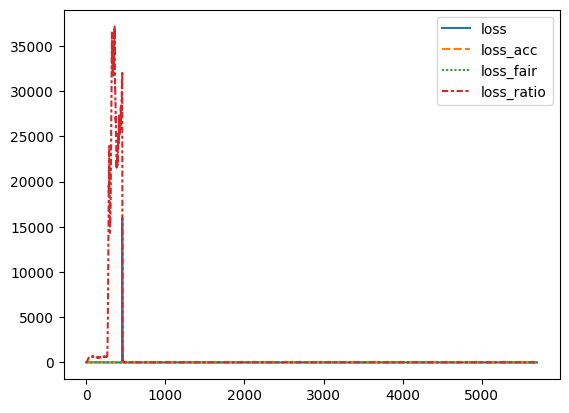


=== Baseline (원본 GLM, f) ===
F1: 0.4137619812631997
Precision: 0.27678894872847587
Recall: 0.8191109205260149
PR-AUC: 0.45895828856980675
ROC-AUC: 0.749096551524137
DP_gap: 0.7359799562150519
EO_gap: 1.3287396959014535

  [age] Grid search 결과 (val, accuracy 높은 순 상위 5개):
    lambda_fair  lambda_ratio  n_classes  DP_gap_val  EO_gap_val  \
0             1         0.001          7    0.159853    0.429032   
12           10         0.001          7    0.166448    0.440281   
8             5         0.001          7    0.154102    0.412198   
4             3         0.001          7    0.154335    0.411742   
1             1         0.010          7    0.313559    0.731254   

    accuracy_val    f1_val  precision_val  recall_val  pr_auc_val  \
0       0.825190  0.362011       0.593485    0.260435    0.443416   
12      0.823529  0.360903       0.581480    0.261650    0.449176   
8       0.823148  0.338458       0.588319    0.237564    0.428547   
4       0.821297  0.342316       0.572170  

In [ ]:
# 일단 범위 크게해서 age_gender와 비슷한 경향 보이는지 확인
# 비슷한 경향 보이면 age_gender 결과 바탕으로 grid_search 범위 조정
import itertools
import pandas as pd

lamb_fair_grid = [1,3,5,10]
lamb_ratio_grid = [0.001, 0.01, 0.1, 0.5]

attr = 'age'
print(f"\n{'='*60}\nAttribute: {attr}\n{'='*60}")

S_train_cat, S_val_cat, n_classes = get_sensitive_attribute(
    data, attr, sens_config, idx_train, idx_val
)

all_cats = pd.concat([S_train_cat, S_val_cat]).astype('category')
S_train_codes = all_cats.cat.codes[:len(S_train_cat)].values
S_val_codes = all_cats.cat.codes[len(S_train_cat):].values

print(f"  -> {n_classes} categories: {list(all_cats.cat.categories)}")

input_dim = X_train.shape[1]
attr_grid_results = []

for lamb_fair, lamb_ratio in itertools.product(lamb_fair_grid, lamb_ratio_grid):
    print(f"    -- lambda_fair={lamb_fair}, lambda_ratio={lamb_ratio}")

    NN_r = make_NN_r(input_dim, hidden=(64, 32))

    rbmd_model = rbmd_debiasing(
        learning_rate=0.01,
        batch_size=2048,
        lamb_fair=lamb_fair,
        lamb_ratio=lamb_ratio,
        num_epochs=150,
        NN_r=NN_r,
        n_classes=n_classes,
        GPU='cuda:0',
        threshold=THRESHOLD
    )

    rbmd_model.train(
        X_train, y_train, S_train_codes,
        y_hat=proba_train,
        X_test=X_val, y_test=y_val, S_test=S_val_codes,
        y_hat_test=proba_val,
        plot_losses=True
    )

    val_probs = rbmd_model.predict_proba(X_val, proba_val)
    val_preds = rbmd_model.predict(X_val, proba_val)

    attr_grid_results.append({
        'lambda_fair': lamb_fair,
        'lambda_ratio': lamb_ratio,
        'n_classes': n_classes,
        'DP_gap_val': group_fairness_gap(val_preds, S_val_codes),
        'EO_gap_val': disparate_mistreatment_general(val_preds, y_val, S_val_codes),
        'accuracy_val': float(np.mean(val_preds == y_val)),
        'f1_val': f1_score(y_val, val_preds),
        'precision_val': precision_score(y_val, val_preds, zero_division=0),
        'recall_val': recall_score(y_val, val_preds, zero_division=0),
        'pr_auc_val': average_precision_score(y_val, val_probs),
        'roc_auc_val': roc_auc_score(y_val, val_probs),
        'proportion_changed_val': float(np.mean(val_preds != (proba_val > THRESHOLD))),
    })

grid_results = {}
grid_results[attr] = pd.DataFrame(attr_grid_results)

# baseline
baseline_preds = (proba_val > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) ===")
print("F1:", f1_score(y_val, baseline_preds))
print("Precision:", precision_score(y_val, baseline_preds, zero_division=0))
print("Recall:", recall_score(y_val, baseline_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_val, proba_val))
print("ROC-AUC:", roc_auc_score(y_val, proba_val))
print("DP_gap:", group_fairness_gap(baseline_preds, S_val_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds, y_val, S_val_codes))

# 튜닝 후 -- grid_results 직접 사용 (조합당 1행이므로 groupby 불필요)
print(f"\n  [{attr}] Grid search 결과 (val, accuracy 높은 순 상위 5개):")
print(grid_results[attr].sort_values('accuracy_val', ascending=False).head())

print(f"\n  [{attr}] Grid search 결과 (val, 변화 최소화 우선 상위 5개):")
print(grid_results[attr].sort_values('proportion_changed_val').head())

print(f"\n  [{attr}] Grid search 결과 (val, DP gap 낮은 순 상위 5개):")
print(grid_results[attr].sort_values('DP_gap_val').head())

- age_gender와 마찬가지로 lambda_fair의 경우 효고 크지 않음. 5로 고정


Attribute: age
  -> 7 categories: ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    -- lambda_fair=5, lambda_ratio=0.001
epoch 0 loss_acc 0.6959 loss_fair 1.9225 loss_ratio 426.5509 DP_gap_test 0.0732 EO_gap_test 0.2167 ACC_test 0.821 proportion_changed 0.5369
epoch 30 loss_acc 0.6948 loss_fair 1.9228 loss_ratio 5.0931 DP_gap_test 0.1677 EO_gap_test 0.4468 ACC_test 0.8239 proportion_changed 0.482
epoch 60 loss_acc 0.6945 loss_fair 1.9304 loss_ratio 5.2726 DP_gap_test 0.1345 EO_gap_test 0.3548 ACC_test 0.824 proportion_changed 0.494
epoch 90 loss_acc 0.691 loss_fair 1.9353 loss_ratio 5.3219 DP_gap_test 0.1416 EO_gap_test 0.3735 ACC_test 0.824 proportion_changed 0.489
epoch 120 loss_acc 0.6937 loss_fair 1.92 loss_ratio 5.0621 DP_gap_test 0.1344 EO_gap_test 0.346 ACC_test 0.8245 proportion_changed 0.4907

Final DP gap: 0.14577432286546704
Final EO gap: 0.3827539011219733
Final Accuracy: 82.29850014971282
Final proportion changed: 0.487968533086534


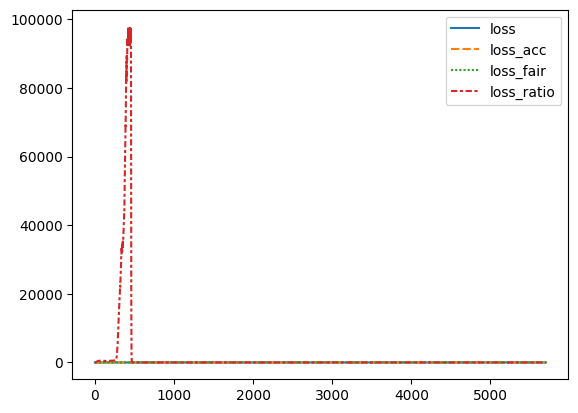

    -- lambda_fair=5, lambda_ratio=0.003
epoch 0 loss_acc 0.6927 loss_fair 1.915 loss_ratio 563.8272 DP_gap_test 0.0713 EO_gap_test 0.2118 ACC_test 0.8209 proportion_changed 0.5376
epoch 30 loss_acc 0.7042 loss_fair 1.9285 loss_ratio 2.3279 DP_gap_test 0.2474 EO_gap_test 0.6165 ACC_test 0.8132 proportion_changed 0.4425
epoch 60 loss_acc 0.7008 loss_fair 1.9305 loss_ratio 2.3635 DP_gap_test 0.2199 EO_gap_test 0.5523 ACC_test 0.8162 proportion_changed 0.4525
epoch 90 loss_acc 0.6988 loss_fair 1.9339 loss_ratio 2.6043 DP_gap_test 0.2081 EO_gap_test 0.5285 ACC_test 0.815 proportion_changed 0.4609
epoch 120 loss_acc 0.6978 loss_fair 1.9286 loss_ratio 2.5686 DP_gap_test 0.1982 EO_gap_test 0.5032 ACC_test 0.8157 proportion_changed 0.4658

Final DP gap: 0.19541293519771352
Final EO gap: 0.49803738289633204
Final Accuracy: 81.92285706508424
Final proportion changed: 0.4648855377412418


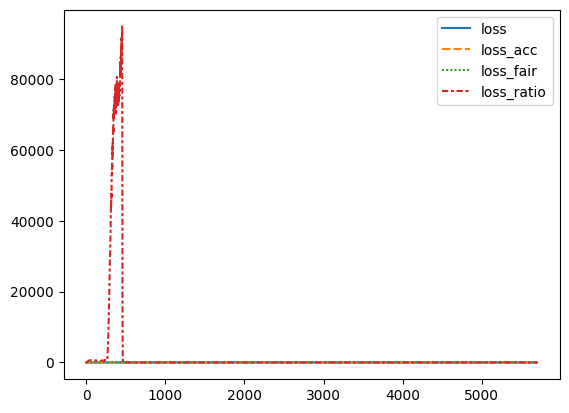

    -- lambda_fair=5, lambda_ratio=0.005
epoch 0 loss_acc 0.6963 loss_fair 1.9112 loss_ratio 637.9963 DP_gap_test 0.0711 EO_gap_test 0.2128 ACC_test 0.8211 proportion_changed 0.5379
epoch 30 loss_acc 0.7064 loss_fair 1.9298 loss_ratio 1.8013 DP_gap_test 0.2674 EO_gap_test 0.6316 ACC_test 0.8034 proportion_changed 0.4131
epoch 60 loss_acc 0.7054 loss_fair 1.9284 loss_ratio 1.6401 DP_gap_test 0.2698 EO_gap_test 0.6531 ACC_test 0.8042 proportion_changed 0.4177
epoch 90 loss_acc 0.7057 loss_fair 1.9339 loss_ratio 1.6848 DP_gap_test 0.2682 EO_gap_test 0.645 ACC_test 0.8071 proportion_changed 0.4238
epoch 120 loss_acc 0.7023 loss_fair 1.9284 loss_ratio 1.6842 DP_gap_test 0.2709 EO_gap_test 0.6492 ACC_test 0.8083 proportion_changed 0.4258

Final DP gap: 0.25632233953244177
Final EO gap: 0.6215216546217379
Final Accuracy: 81.17429294716499
Final proportion changed: 0.43494297302447127


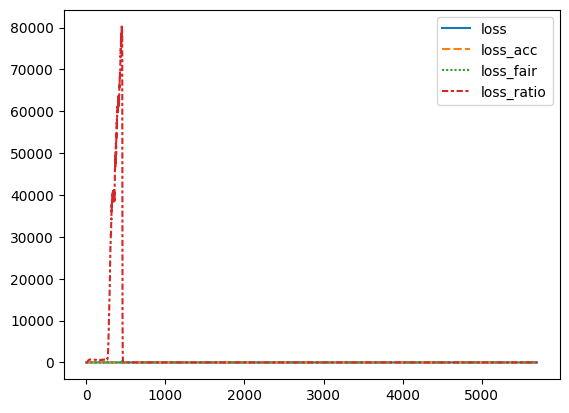

    -- lambda_fair=5, lambda_ratio=0.008
epoch 0 loss_acc 0.6928 loss_fair 1.9147 loss_ratio 458.8437 DP_gap_test 0.0721 EO_gap_test 0.214 ACC_test 0.821 proportion_changed 0.5371
epoch 30 loss_acc 0.7055 loss_fair 1.9255 loss_ratio 1.0805 DP_gap_test 0.3396 EO_gap_test 0.792 ACC_test 0.7925 proportion_changed 0.3879
epoch 60 loss_acc 0.7096 loss_fair 1.9278 loss_ratio 1.109 DP_gap_test 0.3408 EO_gap_test 0.795 ACC_test 0.792 proportion_changed 0.3869
epoch 90 loss_acc 0.7102 loss_fair 1.9235 loss_ratio 1.0578 DP_gap_test 0.341 EO_gap_test 0.7953 ACC_test 0.7908 proportion_changed 0.3848
epoch 120 loss_acc 0.7079 loss_fair 1.9319 loss_ratio 0.9778 DP_gap_test 0.3427 EO_gap_test 0.7947 ACC_test 0.789 proportion_changed 0.3806

Final DP gap: 0.32404367599182965
Final EO gap: 0.7506887740358171
Final Accuracy: 79.4035985518687
Final proportion changed: 0.39202983368266325


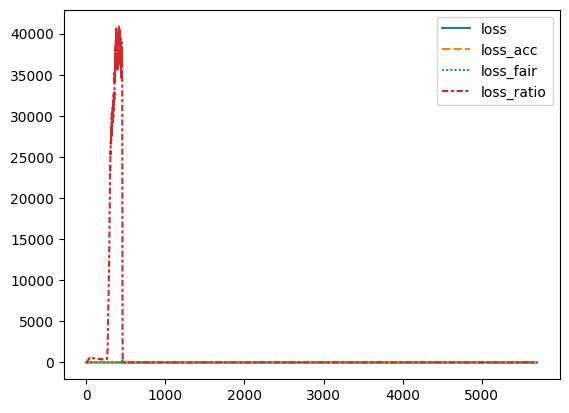

    -- lambda_fair=5, lambda_ratio=0.01
epoch 0 loss_acc 0.692 loss_fair 1.9097 loss_ratio 481.9814 DP_gap_test 0.0717 EO_gap_test 0.2123 ACC_test 0.8209 proportion_changed 0.5373
epoch 30 loss_acc 0.7105 loss_fair 1.9291 loss_ratio 0.8995 DP_gap_test 0.3235 EO_gap_test 0.7549 ACC_test 0.7851 proportion_changed 0.3676
epoch 60 loss_acc 0.7088 loss_fair 1.9244 loss_ratio 0.8815 DP_gap_test 0.3452 EO_gap_test 0.789 ACC_test 0.7843 proportion_changed 0.3694
epoch 90 loss_acc 0.7087 loss_fair 1.9302 loss_ratio 0.8844 DP_gap_test 0.3568 EO_gap_test 0.82 ACC_test 0.7852 proportion_changed 0.3709
epoch 120 loss_acc 0.7105 loss_fair 1.9289 loss_ratio 0.8756 DP_gap_test 0.3629 EO_gap_test 0.8356 ACC_test 0.7843 proportion_changed 0.3699

Final DP gap: 0.3652266153913882
Final EO gap: 0.8331750804238662
Final Accuracy: 78.25625391294881
Final proportion changed: 0.3665106023899611


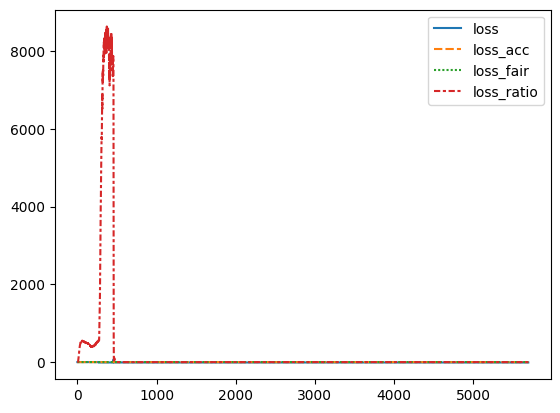

    -- lambda_fair=5, lambda_ratio=0.1
epoch 0 loss_acc 0.6929 loss_fair 1.9175 loss_ratio 634.9124 DP_gap_test 0.0706 EO_gap_test 0.2103 ACC_test 0.821 proportion_changed 0.5381
epoch 30 loss_acc 0.7322 loss_fair 1.929 loss_ratio 0.0576 DP_gap_test 0.6022 EO_gap_test 1.1889 ACC_test 0.6685 proportion_changed 0.1567
epoch 60 loss_acc 0.7315 loss_fair 1.9305 loss_ratio 0.0547 DP_gap_test 0.6022 EO_gap_test 1.179 ACC_test 0.6689 proportion_changed 0.157
epoch 90 loss_acc 0.7302 loss_fair 1.9243 loss_ratio 0.0549 DP_gap_test 0.6004 EO_gap_test 1.1739 ACC_test 0.6677 proportion_changed 0.1551
epoch 120 loss_acc 0.7312 loss_fair 1.9315 loss_ratio 0.059 DP_gap_test 0.6037 EO_gap_test 1.1868 ACC_test 0.6704 proportion_changed 0.1591

Final DP gap: 0.6097263205150434
Final EO gap: 1.1998551300508482
Final Accuracy: 66.58001469907722
Final proportion changed: 0.1533875928900019


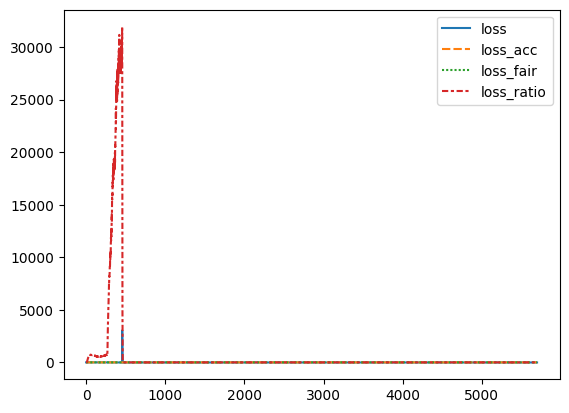


=== Baseline (원본 GLM, f) ===
F1: 0.4137619812631997
Precision: 0.27678894872847587
Recall: 0.8191109205260149
PR-AUC: 0.45895828856980675
ROC-AUC: 0.749096551524137
DP_gap: 0.7359799562150519
EO_gap: 1.3287396959014535

  [age] Grid search 결과 (val, accuracy 높은 순 상위 5개):
   lambda_fair  lambda_ratio  n_classes  DP_gap_val  EO_gap_val  accuracy_val  \
0            5         0.001          7    0.145774    0.382754      0.822985   
1            5         0.003          7    0.195413    0.498037      0.819229   
2            5         0.005          7    0.256322    0.621522      0.811743   
3            5         0.008          7    0.324044    0.750689      0.794036   
4            5         0.010          7    0.365227    0.833175      0.782563   

     f1_val  precision_val  recall_val  pr_auc_val  roc_auc_val  \
0  0.338050       0.587164    0.237350    0.420300     0.732523   
1  0.378300       0.548155    0.288808    0.432435     0.749452   
2  0.412804       0.508365    0.347484  

In [ ]:
lamb_fair_grid = [5]
lamb_ratio_grid = [0.001, 0.003, 0.005, 0.008, 0.01, 0.1]

attr = 'age'
print(f"\n{'='*60}\nAttribute: {attr}\n{'='*60}")

S_train_cat, S_val_cat, n_classes = get_sensitive_attribute(
    data, attr, sens_config, idx_train, idx_val
)

all_cats = pd.concat([S_train_cat, S_val_cat]).astype('category')
S_train_codes = all_cats.cat.codes[:len(S_train_cat)].values
S_val_codes = all_cats.cat.codes[len(S_train_cat):].values

print(f"  -> {n_classes} categories: {list(all_cats.cat.categories)}")

input_dim = X_train.shape[1]
attr_grid_results = []

for lamb_fair, lamb_ratio in itertools.product(lamb_fair_grid, lamb_ratio_grid):
    print(f"    -- lambda_fair={lamb_fair}, lambda_ratio={lamb_ratio}")

    NN_r = make_NN_r(input_dim, hidden=(64, 32))

    rbmd_model = rbmd_debiasing(
        learning_rate=0.01,
        batch_size=2048,
        lamb_fair=lamb_fair,
        lamb_ratio=lamb_ratio,
        num_epochs=150,
        NN_r=NN_r,
        n_classes=n_classes,
        GPU='cuda:0',
        threshold=THRESHOLD
    )

    rbmd_model.train(
        X_train, y_train, S_train_codes,
        y_hat=proba_train,
        X_test=X_val, y_test=y_val, S_test=S_val_codes,
        y_hat_test=proba_val,
        plot_losses=True
    )

    val_probs = rbmd_model.predict_proba(X_val, proba_val)
    val_preds = rbmd_model.predict(X_val, proba_val)

    attr_grid_results.append({
        'lambda_fair': lamb_fair,
        'lambda_ratio': lamb_ratio,
        'n_classes': n_classes,
        'DP_gap_val': group_fairness_gap(val_preds, S_val_codes),
        'EO_gap_val': disparate_mistreatment_general(val_preds, y_val, S_val_codes),
        'accuracy_val': float(np.mean(val_preds == y_val)),
        'f1_val': f1_score(y_val, val_preds),
        'precision_val': precision_score(y_val, val_preds, zero_division=0),
        'recall_val': recall_score(y_val, val_preds, zero_division=0),
        'pr_auc_val': average_precision_score(y_val, val_probs),
        'roc_auc_val': roc_auc_score(y_val, val_probs),
        'proportion_changed_val': float(np.mean(val_preds != (proba_val > THRESHOLD))),
    })

grid_results = {}
grid_results[attr] = pd.DataFrame(attr_grid_results)

# baseline
baseline_preds = (proba_val > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) ===")
print("F1:", f1_score(y_val, baseline_preds))
print("Precision:", precision_score(y_val, baseline_preds, zero_division=0))
print("Recall:", recall_score(y_val, baseline_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_val, proba_val))
print("ROC-AUC:", roc_auc_score(y_val, proba_val))
print("DP_gap:", group_fairness_gap(baseline_preds, S_val_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds, y_val, S_val_codes))

# 튜닝 후 -- grid_results 직접 사용 (조합당 1행이므로 groupby 불필요)
print(f"\n  [{attr}] Grid search 결과 (val, accuracy 높은 순 상위 5개):")
print(grid_results[attr].sort_values('accuracy_val', ascending=False).head())

print(f"\n  [{attr}] Grid search 결과 (val, 변화 최소화 우선 상위 5개):")
print(grid_results[attr].sort_values('proportion_changed_val').head())

print(f"\n  [{attr}] Grid search 결과 (val, DP gap 낮은 순 상위 5개):")
print(grid_results[attr].sort_values('DP_gap_val').head())

epoch 0 loss_acc 0.6897 loss_fair 1.9076 loss_ratio 524.0288 DP_gap_test 0.0418 EO_gap_test 0.1298 ACC_test 0.8418 proportion_changed 0.5318
epoch 30 loss_acc 0.6941 loss_fair 1.9302 loss_ratio 4.8066 DP_gap_test 0.113 EO_gap_test 0.323 ACC_test 0.8393 proportion_changed 0.4898
epoch 60 loss_acc 0.6876 loss_fair 1.9255 loss_ratio 5.4289 DP_gap_test 0.1015 EO_gap_test 0.2918 ACC_test 0.8406 proportion_changed 0.4912
epoch 90 loss_acc 0.687 loss_fair 1.9234 loss_ratio 5.8767 DP_gap_test 0.1074 EO_gap_test 0.305 ACC_test 0.8416 proportion_changed 0.4884
epoch 120 loss_acc 0.6904 loss_fair 1.9332 loss_ratio 5.5778 DP_gap_test 0.1105 EO_gap_test 0.3162 ACC_test 0.8403 proportion_changed 0.4853

Final DP gap: 0.11576122000065661
Final EO gap: 0.32574660344170825
Final Accuracy: 83.88333091043651
Final proportion changed: 0.4830375196585037


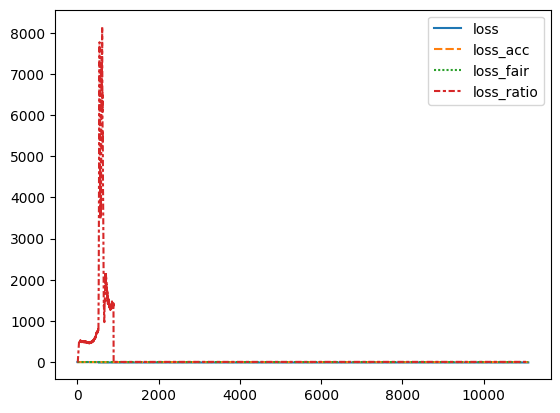


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.7194998850914344
EO_gap: 1.3383544137121548

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8388333091043652
F1: 0.28804950668457
Precision: 0.5
Recall: 0.2022960229602296
PR-AUC: 0.3555550894469163
ROC-AUC: 0.7188019358766817
DP_gap: 0.11576122000065661
EO_gap: 0.32574660344170825
Proportion changed: 0.4830375196585037


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'age', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.001,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

epoch 0 loss_acc 0.6894 loss_fair 1.8968 loss_ratio 591.7892 DP_gap_test 0.041 EO_gap_test 0.1271 ACC_test 0.8417 proportion_changed 0.5323
epoch 30 loss_acc 0.7014 loss_fair 1.9224 loss_ratio 1.5173 DP_gap_test 0.2151 EO_gap_test 0.5241 ACC_test 0.7936 proportion_changed 0.3843
epoch 60 loss_acc 0.7014 loss_fair 1.9228 loss_ratio 1.517 DP_gap_test 0.2006 EO_gap_test 0.5199 ACC_test 0.8177 proportion_changed 0.436
epoch 90 loss_acc 0.7051 loss_fair 1.9376 loss_ratio 1.543 DP_gap_test 0.1979 EO_gap_test 0.5154 ACC_test 0.821 proportion_changed 0.4429
epoch 120 loss_acc 0.7038 loss_fair 1.9201 loss_ratio 1.6156 DP_gap_test 0.1989 EO_gap_test 0.5192 ACC_test 0.8229 proportion_changed 0.4465

Final DP gap: 0.1706391542729571
Final EO gap: 0.4487407560636386
Final Accuracy: 82.71241095854204
Final proportion changed: 0.45338126263760953


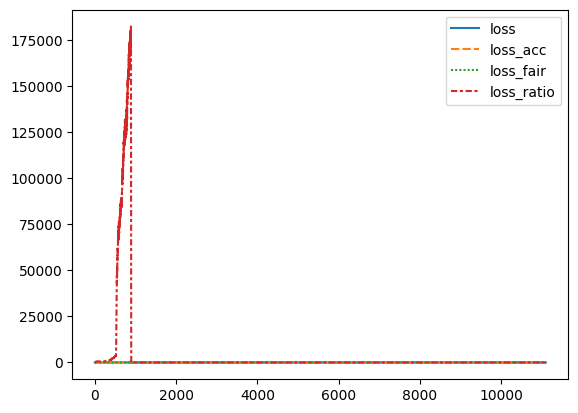


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.7194998850914344
EO_gap: 1.3383544137121548

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8271241095854204
F1: 0.32401426282879436
Precision: 0.43809390721073227
Recall: 0.2570725707257073
PR-AUC: 0.3540401438326547
ROC-AUC: 0.7236822907994646
DP_gap: 0.1706391542729571
EO_gap: 0.4487407560636386
Proportion changed: 0.45338126263760953


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'age', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.005,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

- gender


Attribute: gender
  -> 2 categories: ['F', 'M']
    -- lambda_fair=1, lambda_ratio=0.001
epoch 0 loss_acc 0.6936 loss_fair 0.6844 loss_ratio 517.3357 DP_gap_test 0.0099 EO_gap_test 0.0295 ACC_test 0.8207 proportion_changed 0.5379
epoch 30 loss_acc 0.693 loss_fair 0.6874 loss_ratio 4.8878 DP_gap_test 0.0205 EO_gap_test 0.0385 ACC_test 0.8254 proportion_changed 0.486
epoch 60 loss_acc 0.6932 loss_fair 0.6915 loss_ratio 5.174 DP_gap_test 0.0136 EO_gap_test 0.0121 ACC_test 0.824 proportion_changed 0.4827
epoch 90 loss_acc 0.6925 loss_fair 0.6879 loss_ratio 5.3176 DP_gap_test 0.0176 EO_gap_test 0.0216 ACC_test 0.8206 proportion_changed 0.4744
epoch 120 loss_acc 0.6881 loss_fair 0.6896 loss_ratio 6.1226 DP_gap_test 0.0215 EO_gap_test 0.0352 ACC_test 0.8207 proportion_changed 0.4688

Final DP gap: 0.021855061817807456
Final EO gap: 0.0363935828653236
Final Accuracy: 82.19097912186623
Final proportion changed: 0.46721289163513624


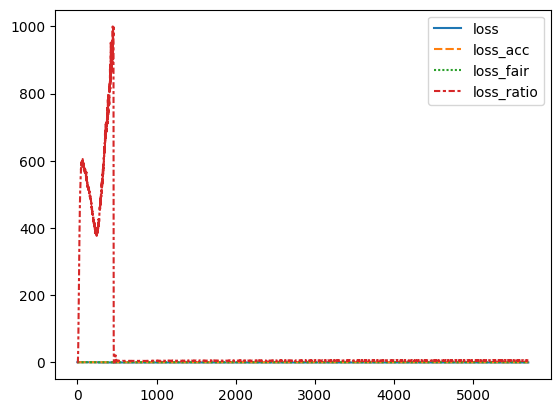

    -- lambda_fair=1, lambda_ratio=0.01
epoch 0 loss_acc 0.6953 loss_fair 0.6882 loss_ratio 524.6918 DP_gap_test 0.0098 EO_gap_test 0.0283 ACC_test 0.821 proportion_changed 0.5373
epoch 30 loss_acc 0.7051 loss_fair 0.6895 loss_ratio 0.9634 DP_gap_test 0.0488 EO_gap_test 0.0845 ACC_test 0.7924 proportion_changed 0.3859
epoch 60 loss_acc 0.7048 loss_fair 0.6913 loss_ratio 0.956 DP_gap_test 0.0512 EO_gap_test 0.0865 ACC_test 0.7924 proportion_changed 0.3836
epoch 90 loss_acc 0.7051 loss_fair 0.6892 loss_ratio 0.9505 DP_gap_test 0.0473 EO_gap_test 0.0793 ACC_test 0.7943 proportion_changed 0.3871
epoch 120 loss_acc 0.7047 loss_fair 0.69 loss_ratio 1.0551 DP_gap_test 0.0434 EO_gap_test 0.0716 ACC_test 0.8008 proportion_changed 0.4014

Final DP gap: 0.04482047820644455
Final EO gap: 0.072674105865874
Final Accuracy: 79.73160573808423
Final proportion changed: 0.3925334131801726


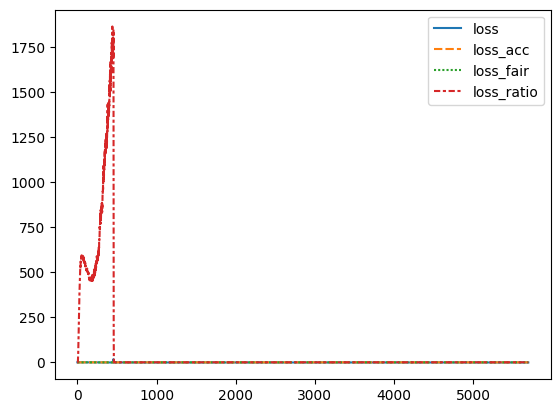

    -- lambda_fair=1, lambda_ratio=0.1
epoch 0 loss_acc 0.6948 loss_fair 0.6901 loss_ratio 369.8849 DP_gap_test 0.0103 EO_gap_test 0.0299 ACC_test 0.8208 proportion_changed 0.537
epoch 30 loss_acc 0.7287 loss_fair 0.6902 loss_ratio 0.0675 DP_gap_test 0.0191 EO_gap_test 0.0181 ACC_test 0.6636 proportion_changed 0.151
epoch 60 loss_acc 0.7296 loss_fair 0.6885 loss_ratio 0.0583 DP_gap_test 0.0782 EO_gap_test 0.1297 ACC_test 0.6727 proportion_changed 0.1631
epoch 90 loss_acc 0.7291 loss_fair 0.6921 loss_ratio 0.063 DP_gap_test 0.0773 EO_gap_test 0.1299 ACC_test 0.6741 proportion_changed 0.1646
epoch 120 loss_acc 0.729 loss_fair 0.6908 loss_ratio 0.0622 DP_gap_test 0.0767 EO_gap_test 0.1273 ACC_test 0.6758 proportion_changed 0.1667

Final DP gap: 0.07720976611360136
Final EO gap: 0.1283154498374509
Final Accuracy: 67.97098293273811
Final proportion changed: 0.17298636252279717


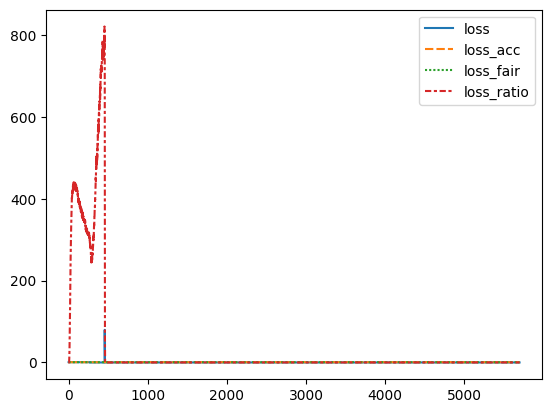

    -- lambda_fair=1, lambda_ratio=0.5
epoch 0 loss_acc 0.6928 loss_fair 0.6918 loss_ratio 517.32 DP_gap_test 0.0099 EO_gap_test 0.0287 ACC_test 0.821 proportion_changed 0.5373
epoch 30 loss_acc 0.7438 loss_fair 0.6907 loss_ratio 0.0043 DP_gap_test 0.0857 EO_gap_test 0.1358 ACC_test 0.5965 proportion_changed 0.0537
epoch 60 loss_acc 0.7424 loss_fair 0.6892 loss_ratio 0.0031 DP_gap_test 0.0848 EO_gap_test 0.1355 ACC_test 0.5918 proportion_changed 0.0473
epoch 90 loss_acc 0.736 loss_fair 0.6904 loss_ratio 0.0037 DP_gap_test 0.0841 EO_gap_test 0.1336 ACC_test 0.5951 proportion_changed 0.0517
epoch 120 loss_acc 0.7385 loss_fair 0.6912 loss_ratio 0.0042 DP_gap_test 0.0839 EO_gap_test 0.1337 ACC_test 0.5948 proportion_changed 0.0515

Final DP gap: 0.0839140398721544
Final EO gap: 0.13401400462901752
Final Accuracy: 59.47818275852682
Final proportion changed: 0.05152843182622424


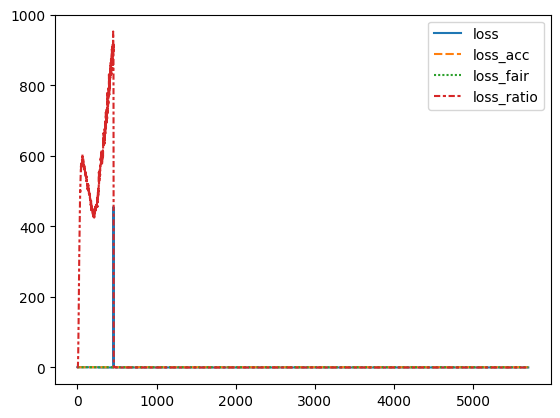

    -- lambda_fair=3, lambda_ratio=0.001
epoch 0 loss_acc 0.6934 loss_fair 0.6914 loss_ratio 583.1229 DP_gap_test 0.0099 EO_gap_test 0.029 ACC_test 0.8208 proportion_changed 0.5377
epoch 30 loss_acc 0.692 loss_fair 0.6897 loss_ratio 4.7889 DP_gap_test 0.0201 EO_gap_test 0.0315 ACC_test 0.8218 proportion_changed 0.4853
epoch 60 loss_acc 0.6896 loss_fair 0.6893 loss_ratio 5.0816 DP_gap_test 0.0197 EO_gap_test 0.0334 ACC_test 0.821 proportion_changed 0.4885
epoch 90 loss_acc 0.6901 loss_fair 0.6887 loss_ratio 6.0701 DP_gap_test 0.0173 EO_gap_test 0.019 ACC_test 0.8174 proportion_changed 0.4814
epoch 120 loss_acc 0.6879 loss_fair 0.6919 loss_ratio 6.0807 DP_gap_test 0.0215 EO_gap_test 0.0298 ACC_test 0.8136 proportion_changed 0.4732

Final DP gap: 0.024215819324963556
Final EO gap: 0.03535425887688611
Final Accuracy: 81.2518714102948
Final proportion changed: 0.47088766094128537


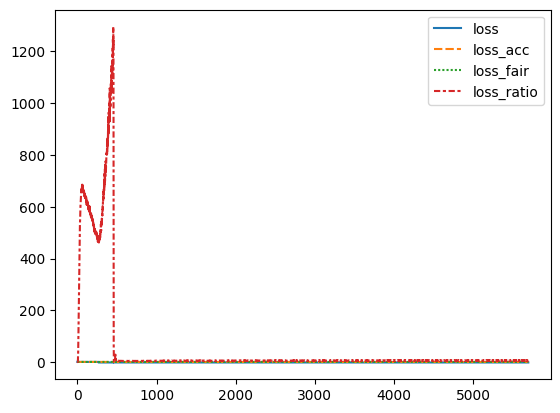

    -- lambda_fair=3, lambda_ratio=0.01
epoch 0 loss_acc 0.6937 loss_fair 0.6868 loss_ratio 689.2938 DP_gap_test 0.0094 EO_gap_test 0.028 ACC_test 0.8205 proportion_changed 0.5386
epoch 30 loss_acc 0.71 loss_fair 0.6914 loss_ratio 0.874 DP_gap_test 0.0474 EO_gap_test 0.0812 ACC_test 0.7874 proportion_changed 0.378
epoch 60 loss_acc 0.7068 loss_fair 0.6909 loss_ratio 0.9086 DP_gap_test 0.0468 EO_gap_test 0.0803 ACC_test 0.795 proportion_changed 0.393
epoch 90 loss_acc 0.706 loss_fair 0.6879 loss_ratio 0.9221 DP_gap_test 0.0463 EO_gap_test 0.0779 ACC_test 0.7944 proportion_changed 0.3889
epoch 120 loss_acc 0.7067 loss_fair 0.6874 loss_ratio 0.9614 DP_gap_test 0.0451 EO_gap_test 0.0766 ACC_test 0.795 proportion_changed 0.3915

Final DP gap: 0.04781043146165054
Final EO gap: 0.08455807280452597
Final Accuracy: 79.35324060211776
Final proportion changed: 0.38616381304951414


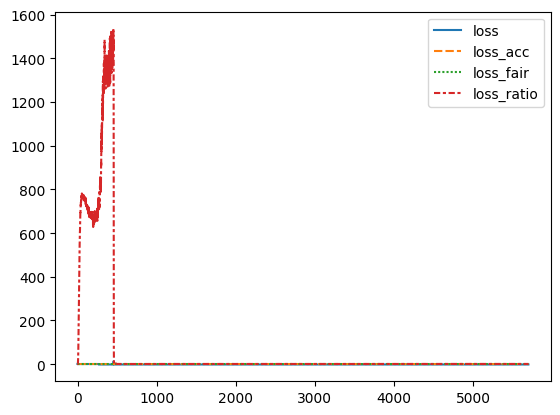

    -- lambda_fair=3, lambda_ratio=0.1
epoch 0 loss_acc 0.6947 loss_fair 0.6885 loss_ratio 526.2923 DP_gap_test 0.0098 EO_gap_test 0.0281 ACC_test 0.8211 proportion_changed 0.5373
epoch 30 loss_acc 0.7268 loss_fair 0.6914 loss_ratio 0.0601 DP_gap_test 0.0795 EO_gap_test 0.1324 ACC_test 0.6729 proportion_changed 0.1637
epoch 60 loss_acc 0.7297 loss_fair 0.6915 loss_ratio 0.066 DP_gap_test 0.0798 EO_gap_test 0.1336 ACC_test 0.6773 proportion_changed 0.1699
epoch 90 loss_acc 0.7294 loss_fair 0.6915 loss_ratio 0.059 DP_gap_test 0.0797 EO_gap_test 0.1334 ACC_test 0.6746 proportion_changed 0.1663
epoch 120 loss_acc 0.7287 loss_fair 0.6853 loss_ratio 0.06 DP_gap_test 0.079 EO_gap_test 0.1324 ACC_test 0.6704 proportion_changed 0.1604

Final DP gap: 0.07940695595593938
Final EO gap: 0.1334623311857845
Final Accuracy: 67.84168549418843
Final proportion changed: 0.1725644445654245


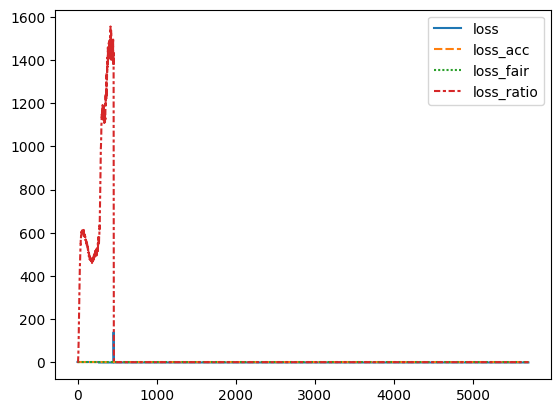

    -- lambda_fair=3, lambda_ratio=0.5
epoch 0 loss_acc 0.6954 loss_fair 0.6921 loss_ratio 653.8047 DP_gap_test 0.0096 EO_gap_test 0.0282 ACC_test 0.8209 proportion_changed 0.5379
epoch 30 loss_acc 0.7434 loss_fair 0.6894 loss_ratio 0.0037 DP_gap_test 0.0882 EO_gap_test 0.1401 ACC_test 0.5931 proportion_changed 0.0494
epoch 60 loss_acc 0.7451 loss_fair 0.6902 loss_ratio 0.0046 DP_gap_test 0.0868 EO_gap_test 0.1377 ACC_test 0.593 proportion_changed 0.0491
epoch 90 loss_acc 0.7444 loss_fair 0.6868 loss_ratio 0.0035 DP_gap_test 0.0872 EO_gap_test 0.1398 ACC_test 0.5983 proportion_changed 0.0569
epoch 120 loss_acc 0.7428 loss_fair 0.6893 loss_ratio 0.0035 DP_gap_test 0.0868 EO_gap_test 0.1381 ACC_test 0.5975 proportion_changed 0.0554

Final DP gap: 0.08759390103394149
Final EO gap: 0.1392300106417903
Final Accuracy: 59.310776601246694
Final proportion changed: 0.049092195878814276


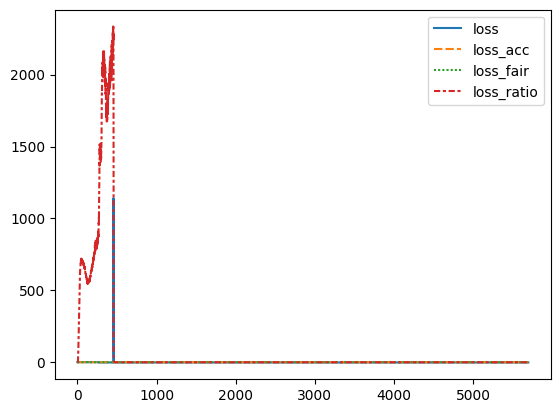

    -- lambda_fair=5, lambda_ratio=0.001
epoch 0 loss_acc 0.6957 loss_fair 0.6872 loss_ratio 478.1378 DP_gap_test 0.0099 EO_gap_test 0.0284 ACC_test 0.8211 proportion_changed 0.5372
epoch 30 loss_acc 0.6956 loss_fair 0.6896 loss_ratio 4.9151 DP_gap_test 0.023 EO_gap_test 0.0432 ACC_test 0.8232 proportion_changed 0.482
epoch 60 loss_acc 0.6928 loss_fair 0.6882 loss_ratio 5.3426 DP_gap_test 0.0182 EO_gap_test 0.0256 ACC_test 0.8224 proportion_changed 0.4875
epoch 90 loss_acc 0.6921 loss_fair 0.6924 loss_ratio 5.0266 DP_gap_test 0.0227 EO_gap_test 0.0348 ACC_test 0.8187 proportion_changed 0.4811
epoch 120 loss_acc 0.6908 loss_fair 0.6894 loss_ratio 5.7737 DP_gap_test 0.0194 EO_gap_test 0.028 ACC_test 0.8186 proportion_changed 0.4852

Final DP gap: 0.01793911938153886
Final EO gap: 0.022059359189549023
Final Accuracy: 81.8194191142445
Final proportion changed: 0.48138116884884447


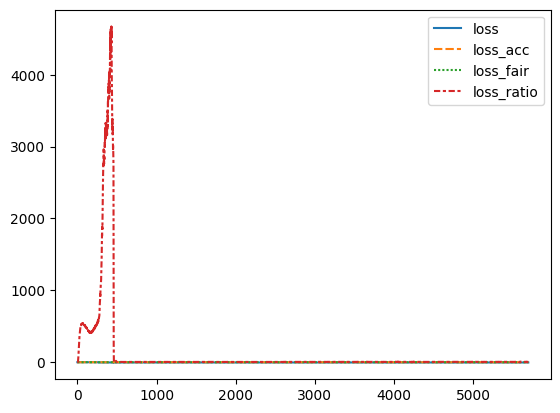

    -- lambda_fair=5, lambda_ratio=0.01
epoch 0 loss_acc 0.6958 loss_fair 0.6882 loss_ratio 709.8562 DP_gap_test 0.0094 EO_gap_test 0.028 ACC_test 0.8208 proportion_changed 0.5384
epoch 30 loss_acc 0.708 loss_fair 0.6898 loss_ratio 0.8871 DP_gap_test 0.0547 EO_gap_test 0.0942 ACC_test 0.7865 proportion_changed 0.3749
epoch 60 loss_acc 0.707 loss_fair 0.691 loss_ratio 0.9422 DP_gap_test 0.0453 EO_gap_test 0.0745 ACC_test 0.7944 proportion_changed 0.3875
epoch 90 loss_acc 0.7075 loss_fair 0.6866 loss_ratio 1.016 DP_gap_test 0.0414 EO_gap_test 0.0709 ACC_test 0.7956 proportion_changed 0.391
epoch 120 loss_acc 0.7074 loss_fair 0.688 loss_ratio 1.0646 DP_gap_test 0.0443 EO_gap_test 0.0766 ACC_test 0.7949 proportion_changed 0.3909

Final DP gap: 0.043676370440340284
Final EO gap: 0.07344261856653314
Final Accuracy: 79.38318316683453
Final proportion changed: 0.3874431771783216


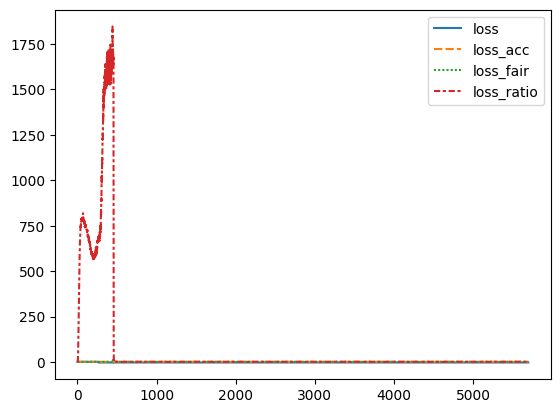

    -- lambda_fair=5, lambda_ratio=0.1
epoch 0 loss_acc 0.6959 loss_fair 0.692 loss_ratio 564.618 DP_gap_test 0.0099 EO_gap_test 0.0292 ACC_test 0.8205 proportion_changed 0.5382
epoch 30 loss_acc 0.7311 loss_fair 0.6863 loss_ratio 0.057 DP_gap_test 0.0825 EO_gap_test 0.1387 ACC_test 0.6745 proportion_changed 0.1664
epoch 60 loss_acc 0.7303 loss_fair 0.6916 loss_ratio 0.0552 DP_gap_test 0.0809 EO_gap_test 0.1359 ACC_test 0.6757 proportion_changed 0.1672
epoch 90 loss_acc 0.7282 loss_fair 0.6892 loss_ratio 0.0596 DP_gap_test 0.0803 EO_gap_test 0.1342 ACC_test 0.6771 proportion_changed 0.1693
epoch 120 loss_acc 0.7286 loss_fair 0.6911 loss_ratio 0.062 DP_gap_test 0.0802 EO_gap_test 0.1344 ACC_test 0.6774 proportion_changed 0.1711

Final DP gap: 0.08058769674011823
Final EO gap: 0.13511886147518365
Final Accuracy: 67.6497808748673
Final proportion changed: 0.16982878297084683


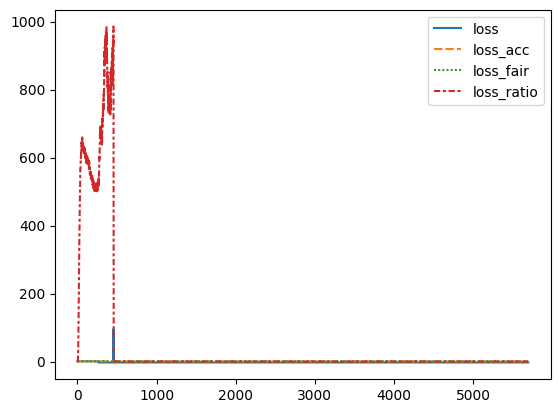

    -- lambda_fair=5, lambda_ratio=0.5
epoch 0 loss_acc 0.6902 loss_fair 0.6906 loss_ratio 490.6711 DP_gap_test 0.0099 EO_gap_test 0.0285 ACC_test 0.821 proportion_changed 0.5371
epoch 30 loss_acc 0.744 loss_fair 0.6858 loss_ratio 0.0049 DP_gap_test 0.0863 EO_gap_test 0.1394 ACC_test 0.5988 proportion_changed 0.058
epoch 60 loss_acc 0.7403 loss_fair 0.6886 loss_ratio 0.0048 DP_gap_test 0.0858 EO_gap_test 0.1368 ACC_test 0.5941 proportion_changed 0.0505
epoch 90 loss_acc 0.7419 loss_fair 0.6923 loss_ratio 0.0044 DP_gap_test 0.0865 EO_gap_test 0.1394 ACC_test 0.5975 proportion_changed 0.0556
epoch 120 loss_acc 0.7416 loss_fair 0.6912 loss_ratio 0.0046 DP_gap_test 0.0869 EO_gap_test 0.1405 ACC_test 0.5978 proportion_changed 0.056

Final DP gap: 0.08685106052124525
Final EO gap: 0.14025064764587375
Final Accuracy: 59.8102730217492
Final proportion changed: 0.05640090372104418


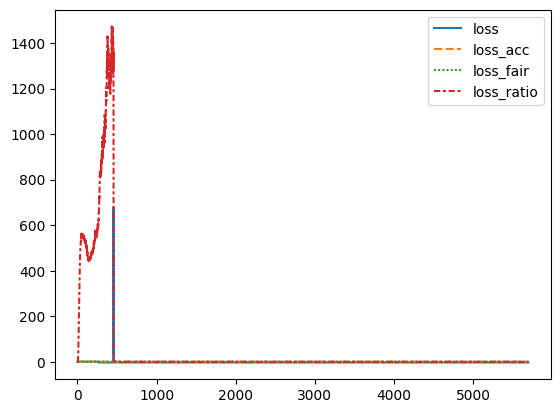

    -- lambda_fair=10, lambda_ratio=0.001
epoch 0 loss_acc 0.691 loss_fair 0.6866 loss_ratio 512.9308 DP_gap_test 0.0097 EO_gap_test 0.0279 ACC_test 0.8211 proportion_changed 0.5372
epoch 30 loss_acc 0.6987 loss_fair 0.6878 loss_ratio 3.9664 DP_gap_test 0.0085 EO_gap_test 0.0109 ACC_test 0.8231 proportion_changed 0.4685
epoch 60 loss_acc 0.6952 loss_fair 0.687 loss_ratio 5.2671 DP_gap_test 0.0171 EO_gap_test 0.025 ACC_test 0.8215 proportion_changed 0.4889
epoch 90 loss_acc 0.6893 loss_fair 0.6883 loss_ratio 5.5958 DP_gap_test 0.0181 EO_gap_test 0.0292 ACC_test 0.8226 proportion_changed 0.491
epoch 120 loss_acc 0.6918 loss_fair 0.6901 loss_ratio 5.6117 DP_gap_test 0.0155 EO_gap_test 0.0187 ACC_test 0.8217 proportion_changed 0.4877

Final DP gap: 0.018937628143903595
Final EO gap: 0.02515167558873157
Final Accuracy: 81.88610937202276
Final proportion changed: 0.4857228407327762


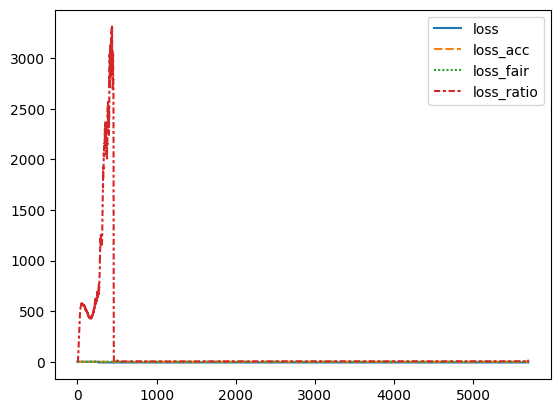

    -- lambda_fair=10, lambda_ratio=0.01
epoch 0 loss_acc 0.6939 loss_fair 0.6892 loss_ratio 425.0814 DP_gap_test 0.0099 EO_gap_test 0.0285 ACC_test 0.8213 proportion_changed 0.5366
epoch 30 loss_acc 0.7054 loss_fair 0.6878 loss_ratio 0.9013 DP_gap_test 0.0476 EO_gap_test 0.0787 ACC_test 0.7907 proportion_changed 0.3822
epoch 60 loss_acc 0.709 loss_fair 0.6896 loss_ratio 0.9329 DP_gap_test 0.045 EO_gap_test 0.0748 ACC_test 0.7945 proportion_changed 0.3866
epoch 90 loss_acc 0.7061 loss_fair 0.6887 loss_ratio 0.9939 DP_gap_test 0.0458 EO_gap_test 0.0769 ACC_test 0.7939 proportion_changed 0.3859
epoch 120 loss_acc 0.7064 loss_fair 0.6885 loss_ratio 0.9843 DP_gap_test 0.0463 EO_gap_test 0.0776 ACC_test 0.7913 proportion_changed 0.3812

Final DP gap: 0.04895690399671032
Final EO gap: 0.08583628165759014
Final Accuracy: 79.20080572719601
Final proportion changed: 0.3814274437215886


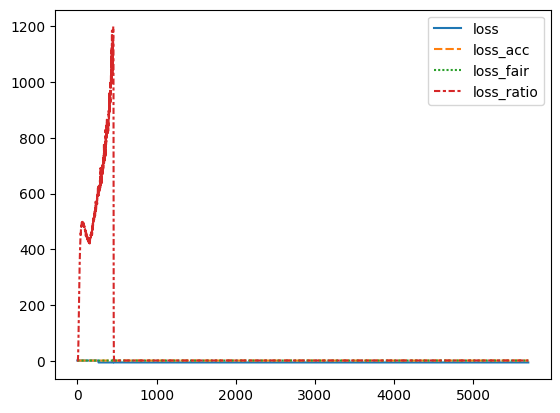

    -- lambda_fair=10, lambda_ratio=0.1
epoch 0 loss_acc 0.6958 loss_fair 0.69 loss_ratio 505.2306 DP_gap_test 0.0101 EO_gap_test 0.0303 ACC_test 0.8208 proportion_changed 0.5376
epoch 30 loss_acc 0.7347 loss_fair 0.6895 loss_ratio 0.0579 DP_gap_test 0.0807 EO_gap_test 0.134 ACC_test 0.6715 proportion_changed 0.1624
epoch 60 loss_acc 0.729 loss_fair 0.6864 loss_ratio 0.0637 DP_gap_test 0.0801 EO_gap_test 0.1336 ACC_test 0.6771 proportion_changed 0.1701
epoch 90 loss_acc 0.7339 loss_fair 0.6889 loss_ratio 0.0583 DP_gap_test 0.0805 EO_gap_test 0.1334 ACC_test 0.6765 proportion_changed 0.169
epoch 120 loss_acc 0.7293 loss_fair 0.6897 loss_ratio 0.0599 DP_gap_test 0.0813 EO_gap_test 0.1357 ACC_test 0.6771 proportion_changed 0.1692

Final DP gap: 0.08006431544536896
Final EO gap: 0.1323238815011839
Final Accuracy: 67.71647113264557
Final proportion changed: 0.16845414704521328


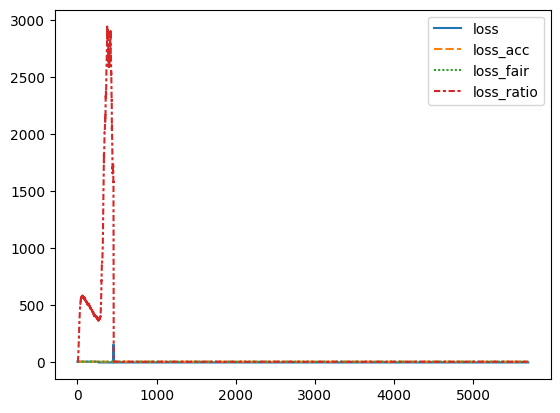

    -- lambda_fair=10, lambda_ratio=0.5
epoch 0 loss_acc 0.6947 loss_fair 0.6931 loss_ratio 530.6235 DP_gap_test 0.0099 EO_gap_test 0.0289 ACC_test 0.8208 proportion_changed 0.5376
epoch 30 loss_acc 0.7424 loss_fair 0.6902 loss_ratio 0.0048 DP_gap_test 0.0846 EO_gap_test 0.1328 ACC_test 0.5944 proportion_changed 0.051
epoch 60 loss_acc 0.7441 loss_fair 0.6915 loss_ratio 0.0041 DP_gap_test 0.0855 EO_gap_test 0.1348 ACC_test 0.5927 proportion_changed 0.0489
epoch 90 loss_acc 0.7431 loss_fair 0.6902 loss_ratio 0.0045 DP_gap_test 0.0865 EO_gap_test 0.1374 ACC_test 0.5958 proportion_changed 0.0533
epoch 120 loss_acc 0.7475 loss_fair 0.6922 loss_ratio 0.0047 DP_gap_test 0.0859 EO_gap_test 0.1365 ACC_test 0.5965 proportion_changed 0.054

Final DP gap: 0.08492642672303574
Final EO gap: 0.13604706962778673
Final Accuracy: 59.43462993712061
Final proportion changed: 0.05109290361216213


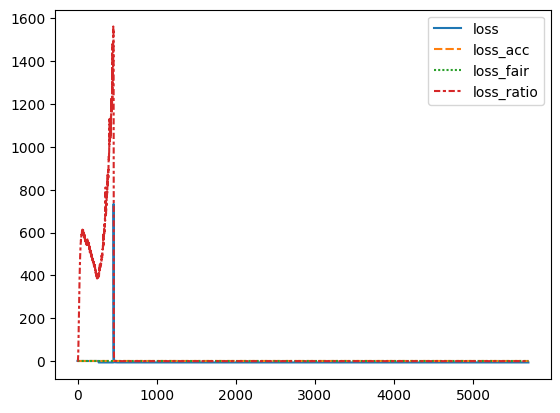


=== Baseline (원본 GLM, f) ===
F1: 0.4137619812631997
Precision: 0.27678894872847587
Recall: 0.8191109205260149
PR-AUC: 0.45895828856980675
ROC-AUC: 0.749096551524137
DP_gap: 0.08037013650330216
EO_gap: 0.12044654048981457

  [gender] Grid search 결과 (val, accuracy 높은 순 상위 5개):
    lambda_fair  lambda_ratio  n_classes  DP_gap_val  EO_gap_val  \
0             1         0.001          2    0.021855    0.036394   
12           10         0.001          2    0.018938    0.025152   
8             5         0.001          2    0.017939    0.022059   
4             3         0.001          2    0.024216    0.035354   
1             1         0.010          2    0.044820    0.072674   

    accuracy_val    f1_val  precision_val  recall_val  pr_auc_val  \
0       0.821910  0.381879       0.563188    0.288879    0.415448   
12      0.818861  0.325888       0.559381    0.229917    0.401349   
8       0.818194  0.336940       0.551511    0.242567    0.405668   
4       0.812519  0.342074       0.515

In [ ]:
lamb_fair_grid = [1,3,5,10]
lamb_ratio_grid = [0.001, 0.01, 0.1, 0.5]

attr = 'gender'
print(f"\n{'='*60}\nAttribute: {attr}\n{'='*60}")

S_train_cat, S_val_cat, n_classes = get_sensitive_attribute(
    data, attr, sens_config, idx_train, idx_val
)

all_cats = pd.concat([S_train_cat, S_val_cat]).astype('category')
S_train_codes = all_cats.cat.codes[:len(S_train_cat)].values
S_val_codes = all_cats.cat.codes[len(S_train_cat):].values

print(f"  -> {n_classes} categories: {list(all_cats.cat.categories)}")

input_dim = X_train.shape[1]
attr_grid_results = []

for lamb_fair, lamb_ratio in itertools.product(lamb_fair_grid, lamb_ratio_grid):
    print(f"    -- lambda_fair={lamb_fair}, lambda_ratio={lamb_ratio}")

    NN_r = make_NN_r(input_dim, hidden=(64, 32))

    rbmd_model = rbmd_debiasing(
        learning_rate=0.01,
        batch_size=2048,
        lamb_fair=lamb_fair,
        lamb_ratio=lamb_ratio,
        num_epochs=150,
        NN_r=NN_r,
        n_classes=n_classes,
        GPU='cuda:0',
        threshold=THRESHOLD
    )

    rbmd_model.train(
        X_train, y_train, S_train_codes,
        y_hat=proba_train,
        X_test=X_val, y_test=y_val, S_test=S_val_codes,
        y_hat_test=proba_val,
        plot_losses=True
    )

    val_probs = rbmd_model.predict_proba(X_val, proba_val)
    val_preds = rbmd_model.predict(X_val, proba_val)

    attr_grid_results.append({
        'lambda_fair': lamb_fair,
        'lambda_ratio': lamb_ratio,
        'n_classes': n_classes,
        'DP_gap_val': group_fairness_gap(val_preds, S_val_codes),
        'EO_gap_val': disparate_mistreatment_general(val_preds, y_val, S_val_codes),
        'accuracy_val': float(np.mean(val_preds == y_val)),
        'f1_val': f1_score(y_val, val_preds),
        'precision_val': precision_score(y_val, val_preds, zero_division=0),
        'recall_val': recall_score(y_val, val_preds, zero_division=0),
        'pr_auc_val': average_precision_score(y_val, val_probs),
        'roc_auc_val': roc_auc_score(y_val, val_probs),
        'proportion_changed_val': float(np.mean(val_preds != (proba_val > THRESHOLD))),
    })

grid_results = {}
grid_results[attr] = pd.DataFrame(attr_grid_results)

# baseline
baseline_preds = (proba_val > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) ===")
print("F1:", f1_score(y_val, baseline_preds))
print("Precision:", precision_score(y_val, baseline_preds, zero_division=0))
print("Recall:", recall_score(y_val, baseline_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_val, proba_val))
print("ROC-AUC:", roc_auc_score(y_val, proba_val))
print("DP_gap:", group_fairness_gap(baseline_preds, S_val_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds, y_val, S_val_codes))

# 튜닝 후 -- grid_results 직접 사용 (조합당 1행이므로 groupby 불필요)
print(f"\n  [{attr}] Grid search 결과 (val, accuracy 높은 순 상위 5개):")
print(grid_results[attr].sort_values('accuracy_val', ascending=False).head())

print(f"\n  [{attr}] Grid search 결과 (val, 변화 최소화 우선 상위 5개):")
print(grid_results[attr].sort_values('proportion_changed_val').head())

print(f"\n  [{attr}] Grid search 결과 (val, DP gap 낮은 순 상위 5개):")
print(grid_results[attr].sort_values('DP_gap_val').head())


Attribute: gender
  -> 2 categories: ['F', 'M']
    -- lambda_fair=5, lambda_ratio=0.001
epoch 0 loss_acc 0.6961 loss_fair 0.6872 loss_ratio 486.7724 DP_gap_test 0.01 EO_gap_test 0.0291 ACC_test 0.8209 proportion_changed 0.5373
epoch 30 loss_acc 0.6962 loss_fair 0.6925 loss_ratio 5.0003 DP_gap_test 0.0171 EO_gap_test 0.0297 ACC_test 0.8256 proportion_changed 0.4865
epoch 60 loss_acc 0.6916 loss_fair 0.6875 loss_ratio 5.1149 DP_gap_test 0.0182 EO_gap_test 0.026 ACC_test 0.8184 proportion_changed 0.4773
epoch 90 loss_acc 0.6903 loss_fair 0.6923 loss_ratio 5.4801 DP_gap_test 0.0224 EO_gap_test 0.0353 ACC_test 0.8161 proportion_changed 0.4705
epoch 120 loss_acc 0.691 loss_fair 0.6805 loss_ratio 6.0485 DP_gap_test 0.0241 EO_gap_test 0.0356 ACC_test 0.8156 proportion_changed 0.4667

Final DP gap: 0.024654658636643803
Final EO gap: 0.037707545714969135
Final Accuracy: 80.82450935024634
Final proportion changed: 0.46487192748455236


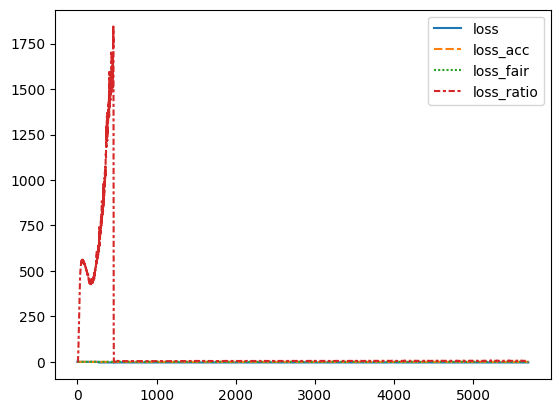

    -- lambda_fair=5, lambda_ratio=0.003
epoch 0 loss_acc 0.6959 loss_fair 0.689 loss_ratio 623.1536 DP_gap_test 0.0098 EO_gap_test 0.0294 ACC_test 0.8205 proportion_changed 0.538
epoch 30 loss_acc 0.6975 loss_fair 0.6901 loss_ratio 2.4595 DP_gap_test 0.0256 EO_gap_test 0.041 ACC_test 0.8187 proportion_changed 0.4547
epoch 60 loss_acc 0.6943 loss_fair 0.6866 loss_ratio 2.582 DP_gap_test 0.0239 EO_gap_test 0.0363 ACC_test 0.8196 proportion_changed 0.4535
epoch 90 loss_acc 0.6954 loss_fair 0.6888 loss_ratio 2.6178 DP_gap_test 0.0239 EO_gap_test 0.0395 ACC_test 0.817 proportion_changed 0.4482
epoch 120 loss_acc 0.6948 loss_fair 0.6878 loss_ratio 2.674 DP_gap_test 0.0262 EO_gap_test 0.0435 ACC_test 0.817 proportion_changed 0.4445

Final DP gap: 0.03451548690771944
Final EO gap: 0.062149307709987583
Final Accuracy: 81.4492201322917
Final proportion changed: 0.4381005525764216


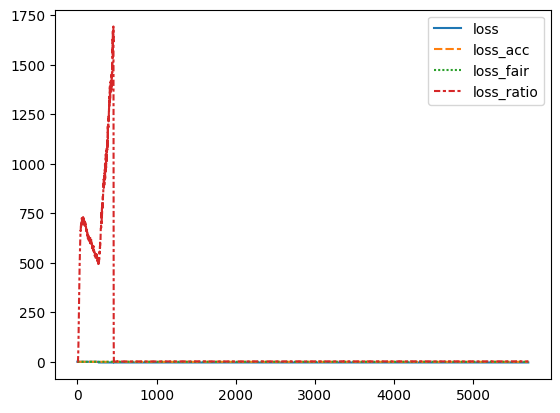

    -- lambda_fair=5, lambda_ratio=0.005
epoch 0 loss_acc 0.6965 loss_fair 0.6901 loss_ratio 393.8134 DP_gap_test 0.0103 EO_gap_test 0.0296 ACC_test 0.8213 proportion_changed 0.5364
epoch 30 loss_acc 0.7017 loss_fair 0.6899 loss_ratio 1.6765 DP_gap_test 0.0313 EO_gap_test 0.0492 ACC_test 0.8102 proportion_changed 0.4285
epoch 60 loss_acc 0.6996 loss_fair 0.6883 loss_ratio 1.7859 DP_gap_test 0.0354 EO_gap_test 0.0529 ACC_test 0.8102 proportion_changed 0.4248
epoch 90 loss_acc 0.7 loss_fair 0.6908 loss_ratio 1.7888 DP_gap_test 0.0322 EO_gap_test 0.0512 ACC_test 0.8098 proportion_changed 0.4241
epoch 120 loss_acc 0.6972 loss_fair 0.6899 loss_ratio 1.928 DP_gap_test 0.0359 EO_gap_test 0.0606 ACC_test 0.8108 proportion_changed 0.4266

Final DP gap: 0.038874438352443974
Final EO gap: 0.06712745122572583
Final Accuracy: 80.52100062607181
Final proportion changed: 0.4209244086343468


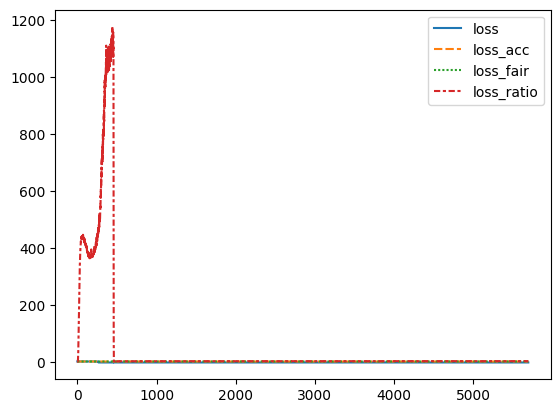

    -- lambda_fair=5, lambda_ratio=0.008
epoch 0 loss_acc 0.6941 loss_fair 0.6916 loss_ratio 412.9066 DP_gap_test 0.0101 EO_gap_test 0.0288 ACC_test 0.821 proportion_changed 0.5368
epoch 30 loss_acc 0.7064 loss_fair 0.6884 loss_ratio 1.1075 DP_gap_test 0.0425 EO_gap_test 0.0684 ACC_test 0.7966 proportion_changed 0.3972
epoch 60 loss_acc 0.7028 loss_fair 0.6859 loss_ratio 1.2342 DP_gap_test 0.0402 EO_gap_test 0.0671 ACC_test 0.8019 proportion_changed 0.4046
epoch 90 loss_acc 0.7059 loss_fair 0.6871 loss_ratio 1.0764 DP_gap_test 0.0414 EO_gap_test 0.0708 ACC_test 0.7968 proportion_changed 0.3931
epoch 120 loss_acc 0.7038 loss_fair 0.6858 loss_ratio 1.184 DP_gap_test 0.0391 EO_gap_test 0.0608 ACC_test 0.8002 proportion_changed 0.4005

Final DP gap: 0.0418412574790297
Final EO gap: 0.068572773748536
Final Accuracy: 80.11133189971963
Final proportion changed: 0.4023464082532597


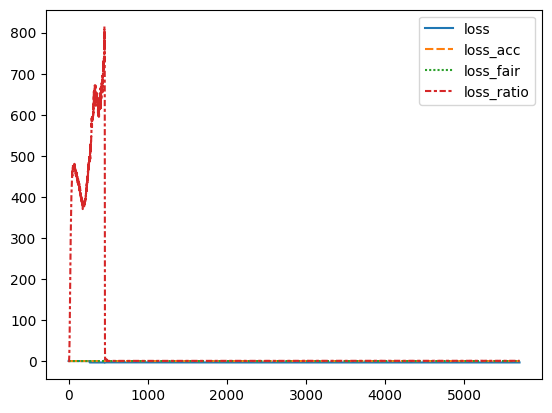

    -- lambda_fair=5, lambda_ratio=0.01
epoch 0 loss_acc 0.6967 loss_fair 0.6875 loss_ratio 486.5962 DP_gap_test 0.0102 EO_gap_test 0.0301 ACC_test 0.8207 proportion_changed 0.5375
epoch 30 loss_acc 0.7057 loss_fair 0.691 loss_ratio 0.9511 DP_gap_test 0.046 EO_gap_test 0.0745 ACC_test 0.7898 proportion_changed 0.3804
epoch 60 loss_acc 0.7042 loss_fair 0.6894 loss_ratio 0.9571 DP_gap_test 0.0439 EO_gap_test 0.0713 ACC_test 0.7952 proportion_changed 0.3909
epoch 90 loss_acc 0.7093 loss_fair 0.6912 loss_ratio 0.9905 DP_gap_test 0.0453 EO_gap_test 0.0731 ACC_test 0.7955 proportion_changed 0.3874
epoch 120 loss_acc 0.7048 loss_fair 0.6919 loss_ratio 1.0279 DP_gap_test 0.048 EO_gap_test 0.0813 ACC_test 0.7953 proportion_changed 0.3869

Final DP gap: 0.04548953762914715
Final EO gap: 0.07351815592821495
Final Accuracy: 79.30696572937366
Final proportion changed: 0.38684432588398615


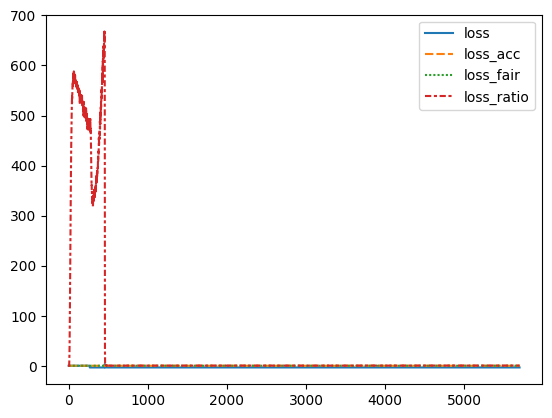


=== Baseline (원본 GLM, f) ===
F1: 0.4137619812631997
Precision: 0.27678894872847587
Recall: 0.8191109205260149
PR-AUC: 0.45895828856980675
ROC-AUC: 0.749096551524137
DP_gap: 0.08037013650330216
EO_gap: 0.12044654048981457

  [gender] Grid search 결과 (val, accuracy 높은 순 상위 5개):
   lambda_fair  lambda_ratio  n_classes  DP_gap_val  EO_gap_val  accuracy_val  \
1            5         0.003          2    0.034515    0.062149      0.814492   
0            5         0.001          2    0.024655    0.037708      0.808245   
2            5         0.005          2    0.038874    0.067127      0.805210   
3            5         0.008          2    0.041841    0.068573      0.801113   
4            5         0.010          2    0.045490    0.073518      0.793070   

     f1_val  precision_val  recall_val  pr_auc_val  roc_auc_val  \
1  0.417870       0.519210    0.349628    0.428282     0.749327   
0  0.343874       0.493517    0.263865    0.373346     0.719889   
2  0.422903       0.485196    0.374

In [ ]:
lamb_fair_grid = [5]
lamb_ratio_grid = [0.001, 0.003, 0.005, 0.008, 0.01]

attr = 'gender'
print(f"\n{'='*60}\nAttribute: {attr}\n{'='*60}")

S_train_cat, S_val_cat, n_classes = get_sensitive_attribute(
    data, attr, sens_config, idx_train, idx_val
)

all_cats = pd.concat([S_train_cat, S_val_cat]).astype('category')
S_train_codes = all_cats.cat.codes[:len(S_train_cat)].values
S_val_codes = all_cats.cat.codes[len(S_train_cat):].values

print(f"  -> {n_classes} categories: {list(all_cats.cat.categories)}")

input_dim = X_train.shape[1]
attr_grid_results = []

for lamb_fair, lamb_ratio in itertools.product(lamb_fair_grid, lamb_ratio_grid):
    print(f"    -- lambda_fair={lamb_fair}, lambda_ratio={lamb_ratio}")

    NN_r = make_NN_r(input_dim, hidden=(64, 32))

    rbmd_model = rbmd_debiasing(
        learning_rate=0.01,
        batch_size=2048,
        lamb_fair=lamb_fair,
        lamb_ratio=lamb_ratio,
        num_epochs=150,
        NN_r=NN_r,
        n_classes=n_classes,
        GPU='cuda:0',
        threshold=THRESHOLD
    )

    rbmd_model.train(
        X_train, y_train, S_train_codes,
        y_hat=proba_train,
        X_test=X_val, y_test=y_val, S_test=S_val_codes,
        y_hat_test=proba_val,
        plot_losses=True
    )

    val_probs = rbmd_model.predict_proba(X_val, proba_val)
    val_preds = rbmd_model.predict(X_val, proba_val)

    attr_grid_results.append({
        'lambda_fair': lamb_fair,
        'lambda_ratio': lamb_ratio,
        'n_classes': n_classes,
        'DP_gap_val': group_fairness_gap(val_preds, S_val_codes),
        'EO_gap_val': disparate_mistreatment_general(val_preds, y_val, S_val_codes),
        'accuracy_val': float(np.mean(val_preds == y_val)),
        'f1_val': f1_score(y_val, val_preds),
        'precision_val': precision_score(y_val, val_preds, zero_division=0),
        'recall_val': recall_score(y_val, val_preds, zero_division=0),
        'pr_auc_val': average_precision_score(y_val, val_probs),
        'roc_auc_val': roc_auc_score(y_val, val_probs),
        'proportion_changed_val': float(np.mean(val_preds != (proba_val > THRESHOLD))),
    })

grid_results = {}
grid_results[attr] = pd.DataFrame(attr_grid_results)

# baseline
baseline_preds = (proba_val > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) ===")
print("F1:", f1_score(y_val, baseline_preds))
print("Precision:", precision_score(y_val, baseline_preds, zero_division=0))
print("Recall:", recall_score(y_val, baseline_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_val, proba_val))
print("ROC-AUC:", roc_auc_score(y_val, proba_val))
print("DP_gap:", group_fairness_gap(baseline_preds, S_val_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds, y_val, S_val_codes))

# 튜닝 후 -- grid_results 직접 사용 (조합당 1행이므로 groupby 불필요)
print(f"\n  [{attr}] Grid search 결과 (val, accuracy 높은 순 상위 5개):")
print(grid_results[attr].sort_values('accuracy_val', ascending=False).head())

print(f"\n  [{attr}] Grid search 결과 (val, 변화 최소화 우선 상위 5개):")
print(grid_results[attr].sort_values('proportion_changed_val').head())

print(f"\n  [{attr}] Grid search 결과 (val, DP gap 낮은 순 상위 5개):")
print(grid_results[attr].sort_values('DP_gap_val').head())

epoch 0 loss_acc 0.6924 loss_fair 0.6924 loss_ratio 632.7889 DP_gap_test 0.0027 EO_gap_test 0.0047 ACC_test 0.8418 proportion_changed 0.5325
epoch 30 loss_acc 0.6953 loss_fair 0.6901 loss_ratio 4.761 DP_gap_test 0.0046 EO_gap_test 0.03 ACC_test 0.8386 proportion_changed 0.4933
epoch 60 loss_acc 0.6927 loss_fair 0.689 loss_ratio 5.2454 DP_gap_test 0.0047 EO_gap_test 0.0302 ACC_test 0.8397 proportion_changed 0.4921
epoch 90 loss_acc 0.6916 loss_fair 0.6891 loss_ratio 5.2249 DP_gap_test 0.0062 EO_gap_test 0.0196 ACC_test 0.8386 proportion_changed 0.4871
epoch 120 loss_acc 0.6898 loss_fair 0.6911 loss_ratio 5.6166 DP_gap_test 0.0054 EO_gap_test 0.0198 ACC_test 0.84 proportion_changed 0.4879

Final DP gap: 0.0078768559009098
Final EO gap: 0.020091423355488358
Final Accuracy: 83.99830837749613
Final proportion changed: 0.49002867828776087


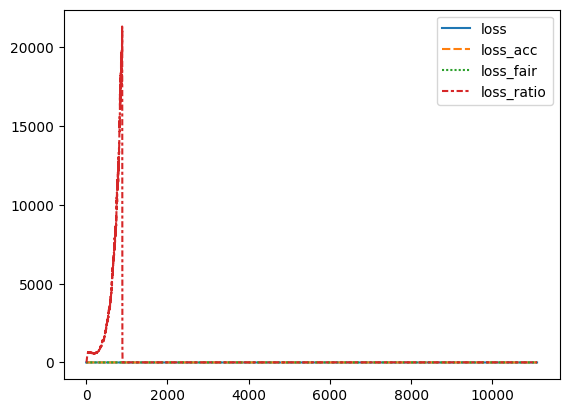


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.08176219273006324
EO_gap: 0.1314281157642212

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8399830837749613
F1: 0.27130476649013
Precision: 0.5098394028500339
Recall: 0.18482984829848298
PR-AUC: 0.35462226105155736
ROC-AUC: 0.7154218024408627
DP_gap: 0.0078768559009098
EO_gap: 0.020091423355488358
Proportion changed: 0.49002867828776087


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'gender', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.001,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

epoch 0 loss_acc 0.6906 loss_fair 0.6932 loss_ratio 499.1407 DP_gap_test 0.0027 EO_gap_test 0.005 ACC_test 0.8417 proportion_changed 0.5321
epoch 30 loss_acc 0.7025 loss_fair 0.6879 loss_ratio 1.6176 DP_gap_test 0.0221 EO_gap_test 0.0296 ACC_test 0.8259 proportion_changed 0.4492
epoch 60 loss_acc 0.7 loss_fair 0.6912 loss_ratio 1.7269 DP_gap_test 0.0171 EO_gap_test 0.0227 ACC_test 0.8297 proportion_changed 0.4589
epoch 90 loss_acc 0.7003 loss_fair 0.6908 loss_ratio 1.7494 DP_gap_test 0.0175 EO_gap_test 0.0212 ACC_test 0.8299 proportion_changed 0.453
epoch 120 loss_acc 0.6954 loss_fair 0.6915 loss_ratio 1.7953 DP_gap_test 0.0211 EO_gap_test 0.0289 ACC_test 0.8268 proportion_changed 0.4434

Final DP gap: 0.023842347882268466
Final EO gap: 0.034992759355785434
Final Accuracy: 82.58421769067097
Final proportion changed: 0.4404694252448227


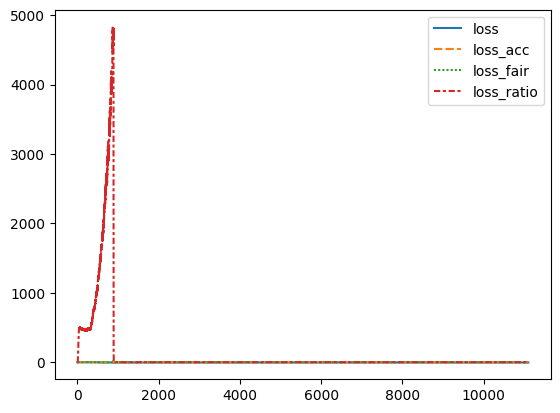


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.08176219273006324
EO_gap: 0.1314281157642212

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8258421769067097
F1: 0.35198662470495673
Precision: 0.4396265815010441
Recall: 0.2934809348093481
PR-AUC: 0.36183400576092334
ROC-AUC: 0.7233619363386727
DP_gap: 0.023842347882268466
EO_gap: 0.034992759355785434
Proportion changed: 0.4404694252448227


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'gender', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.005,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

- C_H

epoch 0 loss_acc 0.693 loss_fair 1.3348 loss_ratio 510.8225 DP_gap_test 0.0357 EO_gap_test 0.1297 ACC_test 0.8417 proportion_changed 0.5323
epoch 30 loss_acc 0.6942 loss_fair 1.3919 loss_ratio 31.599 DP_gap_test 0.0275 EO_gap_test 0.0779 ACC_test 0.8416 proportion_changed 0.5143
epoch 60 loss_acc 0.6917 loss_fair 1.3474 loss_ratio 45.0828 DP_gap_test 0.0269 EO_gap_test 0.0835 ACC_test 0.8418 proportion_changed 0.5183
epoch 90 loss_acc 0.696 loss_fair 1.3396 loss_ratio 10.9851 DP_gap_test 0.0393 EO_gap_test 0.1159 ACC_test 0.8389 proportion_changed 0.5006
epoch 120 loss_acc 0.6931 loss_fair 1.3749 loss_ratio 11.0292 DP_gap_test 0.0394 EO_gap_test 0.116 ACC_test 0.8389 proportion_changed 0.5007

Final DP gap: 0.0396906097670971
Final EO gap: 0.12017965684933246
Final Accuracy: 83.8886172307611
Final proportion changed: 0.5003502187215034


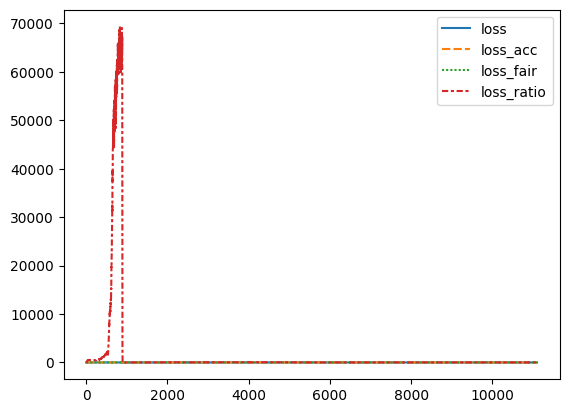


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.21390218655611343
EO_gap: 0.3608401601338104

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.838886172307611
F1: 0.22758664385731484
Precision: 0.5005574136008919
Recall: 0.14727347273472735
PR-AUC: 0.3431801569021159
ROC-AUC: 0.7142595417162894
DP_gap: 0.0396906097670971
EO_gap: 0.12017965684933246
Proportion changed: 0.5003502187215034


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'C_H', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.001,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

epoch 0 loss_acc 0.6942 loss_fair 1.3231 loss_ratio 573.7405 DP_gap_test 0.0391 EO_gap_test 0.1422 ACC_test 0.8417 proportion_changed 0.5324
epoch 30 loss_acc 0.7041 loss_fair 1.4188 loss_ratio 1.5661 DP_gap_test 0.1121 EO_gap_test 0.3531 ACC_test 0.8184 proportion_changed 0.4327
epoch 60 loss_acc 0.7016 loss_fair 1.3462 loss_ratio 1.4432 DP_gap_test 0.0897 EO_gap_test 0.2723 ACC_test 0.8189 proportion_changed 0.4324
epoch 90 loss_acc 0.7007 loss_fair 1.3982 loss_ratio 1.5335 DP_gap_test 0.0771 EO_gap_test 0.2336 ACC_test 0.8234 proportion_changed 0.4426
epoch 120 loss_acc 0.6958 loss_fair 1.3704 loss_ratio 1.7478 DP_gap_test 0.0811 EO_gap_test 0.2336 ACC_test 0.8247 proportion_changed 0.4465

Final DP gap: 0.07511966071522531
Final EO gap: 0.17842919045731098
Final Accuracy: 82.48774234474739
Final proportion changed: 0.4434165488257761


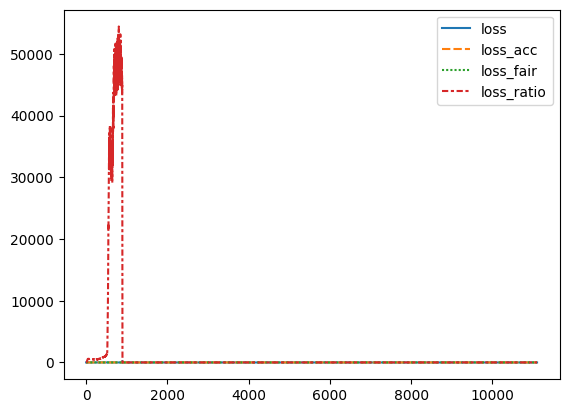


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.21390218655611343
EO_gap: 0.3608401601338104

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8248774234474738
F1: 0.3414343223497838
Precision: 0.43338380015140043
Recall: 0.2816728167281673
PR-AUC: 0.35501613585504566
ROC-AUC: 0.7275844540491032
DP_gap: 0.07511966071522531
EO_gap: 0.17842919045731098
Proportion changed: 0.4434165488257761


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'C_H', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.005,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

- C_IE_T

epoch 0 loss_acc 0.6925 loss_fair 1.4834 loss_ratio 547.421 DP_gap_test 0.0341 EO_gap_test 0.1363 ACC_test 0.8417 proportion_changed 0.532
epoch 30 loss_acc 0.6927 loss_fair 1.5434 loss_ratio 5.0163 DP_gap_test 0.0588 EO_gap_test 0.1763 ACC_test 0.8373 proportion_changed 0.4911
epoch 60 loss_acc 0.6903 loss_fair 1.5394 loss_ratio 5.2012 DP_gap_test 0.0653 EO_gap_test 0.1718 ACC_test 0.8381 proportion_changed 0.492
epoch 90 loss_acc 0.6869 loss_fair 1.5451 loss_ratio 5.2351 DP_gap_test 0.0812 EO_gap_test 0.2856 ACC_test 0.837 proportion_changed 0.4864
epoch 120 loss_acc 0.6902 loss_fair 1.5291 loss_ratio 5.3241 DP_gap_test 0.0692 EO_gap_test 0.2224 ACC_test 0.8389 proportion_changed 0.4856

Final DP gap: 0.06836632471624224
Final EO gap: 0.20884368997892255
Final Accuracy: 83.89654671124796
Final proportion changed: 0.48758375513764257


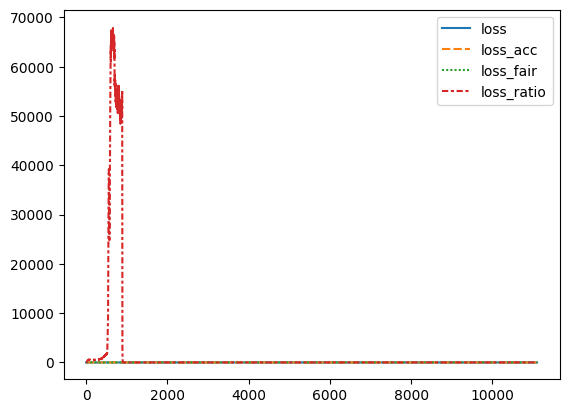


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.33892566292022575
EO_gap: 0.5954657963191664

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8389654671124797
F1: 0.2750907252067345
Precision: 0.5010836584308626
Recall: 0.1895858958589586
PR-AUC: 0.3490073423554809
ROC-AUC: 0.7183122686879755
DP_gap: 0.06836632471624224
EO_gap: 0.20884368997892255
Proportion changed: 0.48758375513764257


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'C_IE_T', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.001,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

epoch 0 loss_acc 0.6923 loss_fair 1.4646 loss_ratio 562.8688 DP_gap_test 0.0362 EO_gap_test 0.1464 ACC_test 0.8417 proportion_changed 0.5321
epoch 30 loss_acc 0.7025 loss_fair 1.5409 loss_ratio 1.5578 DP_gap_test 0.123 EO_gap_test 0.3021 ACC_test 0.8218 proportion_changed 0.4405
epoch 60 loss_acc 0.7012 loss_fair 1.5231 loss_ratio 1.6426 DP_gap_test 0.1228 EO_gap_test 0.3001 ACC_test 0.8219 proportion_changed 0.4408
epoch 90 loss_acc 0.7028 loss_fair 1.5384 loss_ratio 1.4929 DP_gap_test 0.1404 EO_gap_test 0.4131 ACC_test 0.8188 proportion_changed 0.4342
epoch 120 loss_acc 0.6964 loss_fair 1.5259 loss_ratio 1.6666 DP_gap_test 0.1122 EO_gap_test 0.2964 ACC_test 0.8251 proportion_changed 0.451

Final DP gap: 0.11309000273046543
Final EO gap: 0.2742549673598538
Final Accuracy: 82.63708089391677
Final proportion changed: 0.45106849749560574


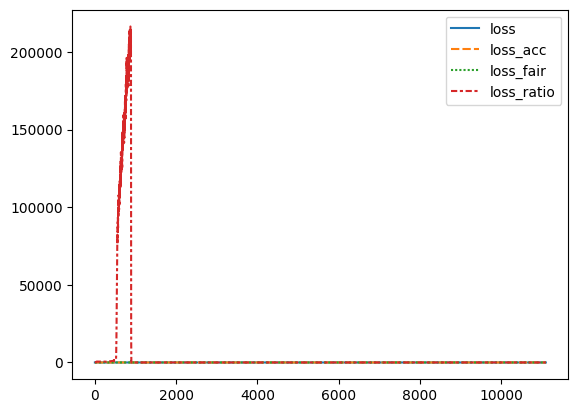


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.33892566292022575
EO_gap: 0.5954657963191664

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8263708089391677
F1: 0.3274979524979525
Precision: 0.4357716932298052
Recall: 0.26232062320623206
PR-AUC: 0.34817332650502575
ROC-AUC: 0.7225399411638432
DP_gap: 0.11309000273046543
EO_gap: 0.2742549673598538
Proportion changed: 0.45106849749560574


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'C_IE_T', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.005,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

- C_GI

epoch 0 loss_acc 0.692 loss_fair 0.9056 loss_ratio 559.4877 DP_gap_test 0.0327 EO_gap_test 0.111 ACC_test 0.8418 proportion_changed 0.5326
epoch 30 loss_acc 0.6955 loss_fair 0.9653 loss_ratio 4.9164 DP_gap_test 0.0398 EO_gap_test 0.126 ACC_test 0.8377 proportion_changed 0.4942
epoch 60 loss_acc 0.696 loss_fair 0.9301 loss_ratio 4.8086 DP_gap_test 0.0397 EO_gap_test 0.1146 ACC_test 0.8386 proportion_changed 0.4983
epoch 90 loss_acc 0.6925 loss_fair 1.0082 loss_ratio 4.4528 DP_gap_test 0.0531 EO_gap_test 0.1478 ACC_test 0.8379 proportion_changed 0.4931
epoch 120 loss_acc 0.6916 loss_fair 0.9554 loss_ratio 4.8695 DP_gap_test 0.0542 EO_gap_test 0.1526 ACC_test 0.8388 proportion_changed 0.4909

Final DP gap: 0.051149631346808035
Final EO gap: 0.14162022164143107
Final Accuracy: 84.00755943806415
Final proportion changed: 0.4927379174541081


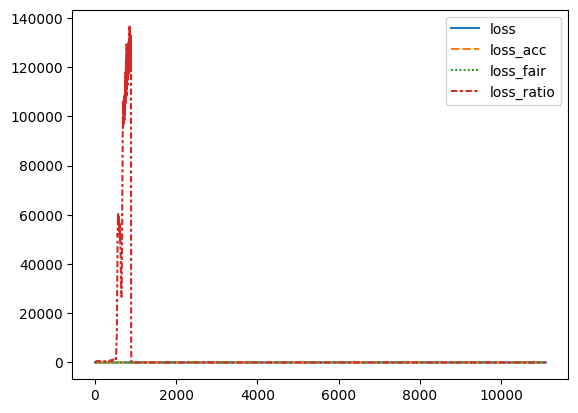


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.24829352122215453
EO_gap: 0.42462903822552334

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8400755943806415
F1: 0.2617289976206455
Precision: 0.5112011439466159
Recall: 0.17589175891758918
PR-AUC: 0.35118687676866894
ROC-AUC: 0.7158549448489191
DP_gap: 0.051149631346808035
EO_gap: 0.14162022164143107
Proportion changed: 0.4927379174541081


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'C_GI', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.001,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))

epoch 0 loss_acc 0.6918 loss_fair 0.9419 loss_ratio 441.6225 DP_gap_test 0.033 EO_gap_test 0.1333 ACC_test 0.8417 proportion_changed 0.5318
epoch 30 loss_acc 0.703 loss_fair 0.9633 loss_ratio 1.6944 DP_gap_test 0.0864 EO_gap_test 0.2358 ACC_test 0.8205 proportion_changed 0.4454
epoch 60 loss_acc 0.7011 loss_fair 1.0001 loss_ratio 1.5891 DP_gap_test 0.091 EO_gap_test 0.2734 ACC_test 0.8242 proportion_changed 0.447
epoch 90 loss_acc 0.7015 loss_fair 0.9903 loss_ratio 1.581 DP_gap_test 0.0834 EO_gap_test 0.2338 ACC_test 0.8268 proportion_changed 0.4541
epoch 120 loss_acc 0.7 loss_fair 0.9906 loss_ratio 1.6282 DP_gap_test 0.0783 EO_gap_test 0.2101 ACC_test 0.8267 proportion_changed 0.4487

Final DP gap: 0.11952841047754578
Final EO gap: 0.3386971870641461
Final Accuracy: 82.66615565570196
Final proportion changed: 0.4502755494469187


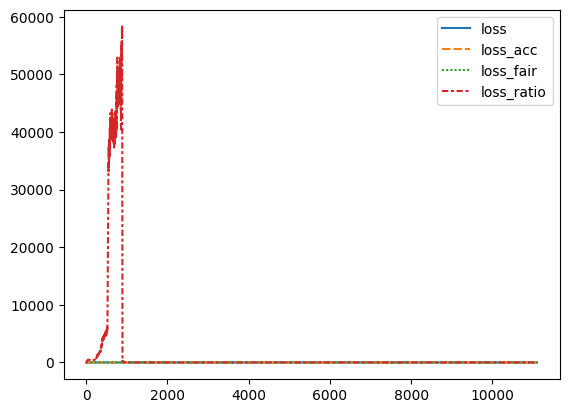


=== Baseline (원본 GLM, f) -- TEST ===
Accuracy: 0.5445174250333699
F1: 0.3575116977051992
Precision: 0.23135012545840572
Recall: 0.7863058630586306
PR-AUC: 0.34318018070804024
ROC-AUC: 0.7142595417162894
DP_gap: 0.24829352122215453
EO_gap: 0.42462903822552334

=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===
Accuracy: 0.8266615565570196
F1: 0.3304747320061256
Precision: 0.4377281947261663
Recall: 0.2654366543665437
PR-AUC: 0.3527508858711371
ROC-AUC: 0.7218194535266502
DP_gap: 0.11952841047754578
EO_gap: 0.3386971870641461
Proportion changed: 0.4502755494469187


In [ ]:
# test set으로 평가
# val 결과 보시고 최종 기준(예: DP_gap_val 최소이면서 accuracy_val 크게 안 떨어지는 것)으로 직접 선택

# 최종 모델은 train+val을 합쳐서 학습 (2017+2018)
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
proba_trainval = np.concatenate([proba_train, proba_val], axis=0)

# 피처 수
input_dim=X_trainval.shape[1]

# sensitive attribute도 train+val 합친 index 기준으로 다시 추출
idx_trainval = idx_train.append(idx_val)
S_trainval_cat, S_test_cat, n_classes = get_sensitive_attribute(
    data, 'C_GI', sens_config, idx_trainval, idx_test
)
all_cats2 = pd.concat([S_trainval_cat, S_test_cat]).astype('category')
S_trainval_codes = all_cats2.cat.codes[:len(S_trainval_cat)].values
S_test_codes = all_cats2.cat.codes[len(S_trainval_cat):].values

NN_r_final = make_NN_r(input_dim, hidden=(64, 32))
final_model = rbmd_debiasing(
    learning_rate=0.01, batch_size=2048,
    lamb_fair=5, lamb_ratio=0.005,
    num_epochs=150, NN_r=NN_r_final, n_classes=n_classes,
    GPU='cuda:0', threshold=THRESHOLD
)
final_model.train(
    X_trainval, y_trainval, S_trainval_codes, y_hat=proba_trainval,   # 2017+2018 합쳐서 학습
    X_test=X_test, y_test=y_test, S_test=S_test_codes, y_hat_test=proba_test,
    plot_losses=True
)

test_probs = final_model.predict_proba(X_test, proba_test)   # PR-AUC, ROC-AUC용
test_preds = final_model.predict(X_test, proba_test)          # F1, Precision, Recall, Accuracy용

# Baseline, test set 기준
baseline_preds_test = (proba_test > THRESHOLD).astype(int)
print("\n=== Baseline (원본 GLM, f) -- TEST ===")
print("Accuracy:", np.mean(baseline_preds_test == y_test))
print("F1:", f1_score(y_test, baseline_preds_test))
print("Precision:", precision_score(y_test, baseline_preds_test, zero_division=0))
print("Recall:", recall_score(y_test, baseline_preds_test, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, proba_test))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("DP_gap:", group_fairness_gap(baseline_preds_test, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(baseline_preds_test, y_test, S_test_codes))

# RBMD 최종 모델, test set 기준
print("\n=== 최종 RBMD 모델 TEST 성능 (단 한 번 평가) ===")
print("Accuracy:", np.mean(test_preds == y_test))
print("F1:", f1_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("DP_gap:", group_fairness_gap(test_preds, S_test_codes))
print("EO_gap:", disparate_mistreatment_general(test_preds, y_test, S_test_codes))
print("Proportion changed:", np.mean(test_preds != (proba_test > THRESHOLD)))